# Afya Flow

### Hospital-Wide Outpatient Demand & Resource Allocation Prototype

### AIC Kijabe Hospital
AIC Kijabe Hospital is located in Kijabe, Kiambu County, Kenya, started as Kijabe Station was first established by missionaries from AIM as an outpost in 1903 upgrading first hospital at Kijabe, Theodora Hospital, was established in 1915. This served the medical needs of the area until the present complex was begun.
Today, Kijabe Hospital is a non-profit, 363-bed hospital owned and operated by AIC of Kenya as part of a network of four hospitals and 45 dispensaries. It has 1,078 employees as of Jul 26 and strives to balance Kenyan and missionary consultants. The hospital has daily average visits of about 355 and monthly average vistis of 10,677 patients a broad range of inpatient and outpatient curative services to people from the surrounding farming communities.

### Project Overview

The model uses historical outpatient records to identify patterns in patient attendance and predict periods of high demand across hospital departments. These insights will support  staff in providing medical services and efficient resource allocation, helping the hospital reduce congestion and improve patient flow.


# Business Understanding

### Problem Definition

Kijabe experiences variation in patient volumes across days and departments, making it difficult to anticipate where demand will occur and whether available capacity will be sufficient. During high-demand periods, patient volumes may exceed the available clinical capacity, contributing to congestion, longer waiting times and increased pressure on staff and resources. For instance patient volumes vary by day where weekdays have higher visits than weekends with with an average of 35 - 69 vists per hour during peak working hours potentially contribution to longer wait times for patients

### Business Objectives

AfyaFlow aims to use Kijabe Hospital's historical patient data and relevant internal operational factors to understand and predict patient demand across the hospital. The goal is to identify where and when high patient volumes are likely to occur and provide insights that can support proactive planning and decision-making.

The project aims:
- To predict outpatient demand in the hospital and time periods.
- To identify departments, days, and time periods that are most likely to experience high patient volumes and congestion.
- To analyse historical patterns and factors that influence changes in outpatient demand.
- To support decisions on how available clinicians and resources can be allocated based on predicted demand.
- To provide hospital-wide insights to support capacity planning and improve patient flow.

### Research Questions
* How can historical patient data and predictive analytics be used to anticipate patient demand and support capacity planning to reduce congestion at Kijabe Hospital?
* What temporal patterns influence patient demand at Kijabe Hospital?
* Can patient-level historical patterns identify recurring patients and help explain predictable components of hospital demand?
* Can a scenario-based simulation help hospital decision-makers evaluate the potential effect of resource allocation decisions on congestion?
  
### Key Stakeholders

* Hospital Management: Requires hospital-wide demand insights to support capacity, staffing, and resource planning.
* Department Managers: Need demand forecasts to prepare for expected changes in patient volumes.
* Clinicians and Nurses: Benefit from better planning and distribution of workload and available clinical capacity.
* Patients: Benefit from improved patient flow, reduced waiting times, and more efficient service delivery.

### Data Science Tasks

The project will analyse Kijabe Hospital's historical outpatient data to identify patterns in patient attendance across departments and different time periods. Predictive models will then be developed to forecast future outpatient demand and identify periods of potentially high patient volumes. These predictions will be translated into decision-support insights to help the hospital plan staffing and resources according to anticipated demand.

# Data Understanding

### Data Overview

Opd_data.csv comes from Kijabe Hospital's outpatient records system. It has 306,306 rows and 6 columns, covering 1 June 2024 to 19 August 2026 (about 26.5 months, with the last month not fully complete). This is the only data we have for the project so far there's no separate data on staff numbers or bed availability yet.

#### Column Description
* PatientNumber - Represents the unique hospital identifier assigned to each patient. It is used to link repeat visits to the same individual and is not a row identifier, since one patient can appear many times.
* RegistrationDate - Represents the date and time at which the patient was registered into a service queue. This is the main temporal field in the dataset and provides the year, month, day of week and hour used for demand analysis.
* Gender - Represents the gender of the patient, recorded as Male or Female.
* Age - Represents the age of the patient at the time of registration, recorded as text with a unit attached, for example "38 Yr(s)", "6 Mth(s)", "3 Week(s)" or "5 Days(s)".
* QueuedTo - Represents the department or clinic the patient was queued to, for example General OPD, MCH, Chronic Care Clinic, Oncology, Renal or Dental. This is the main department field and the unit at which demand is analysed.
* ConsultDescription - Represents the type or purpose of the consultation the patient was booked for, for example General Outpatient Care, Admission, Chemotherapy, MCH Clinic or ENT Return Visit. It gives a finer-
grained view of service type within a department, and also distinguishes new visits from return visits.


In [1]:
# Library Imports
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import time

import lightgbm as lgb
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings("ignore")

#Load Dataset
data =  pd.read_csv("Opd_data.csv")

dept_counts = data["QueuedTo"].value_counts().head(20)

In [2]:
#basic understanding of the datset
print(f'The dataset has {data.shape[0]} rows and {data.shape[1]} columns\n')
print('Dataset Columns:\n',data.columns)
print('\n Dataset Data types:\n',data.dtypes)

The dataset has 306306 rows and 6 columns

Dataset Columns:
 Index(['PatientNumber', 'RegistrationDate', 'Gender', 'Age', 'QueuedTo',
       'ConsultDescription'],
      dtype='object')

 Dataset Data types:
 PatientNumber         object
RegistrationDate      object
Gender                object
Age                   object
QueuedTo              object
ConsultDescription    object
dtype: object


Observation: The dataset has 6 columns. All the data types are correct apart fromthe age columns that should be numeric

In [3]:
#Checking Info of the data
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 306306 entries, 0 to 306305
Data columns (total 6 columns):
 #   Column              Non-Null Count   Dtype 
---  ------              --------------   ----- 
 0   PatientNumber       306306 non-null  object
 1   RegistrationDate    306306 non-null  object
 2   Gender              306291 non-null  object
 3   Age                 305735 non-null  object
 4   QueuedTo            299528 non-null  object
 5   ConsultDescription  299920 non-null  object
dtypes: object(6)
memory usage: 14.0+ MB


In [4]:
#checking statistics
data.describe(include='O')

,PatientNumber,RegistrationDate,Gender,Age,QueuedTo,ConsultDescription
count,306306,306306,306291,305735,299528,299920
unique,80927,202637,4,142,44,79
top,10099285,2/4/2025 0:00,Female,2 Yr(s),GENERAL OPD,General Outpatient Care
freq,266,45,142251,7464,85959,49377


In [5]:
#Checking dataset uniformity
data.head()

,PatientNumber,RegistrationDate,Gender,Age,QueuedTo,ConsultDescription
0,10575758,6/1/2024 0:00,Male,38 Yr(s),GENERAL OPD,GEneral Outpatient Care( NEW )
1,10575713,6/1/2024 0:00,Female,29 Yr(s),NaN,NaN
2,10569291,6/1/2024 0:04,Female,44 Yr(s),GENERAL OPD,General Outpatient Care
3,10575732,6/1/2024 0:04,Female,78 Yr(s),GENERAL OPD,General Outpatient Care
4,10575731,6/1/2024 0:10,Female,2 Yr(s),ADMISSION,Admission


In [6]:
data.tail()

,PatientNumber,RegistrationDate,Gender,Age,QueuedTo,ConsultDescription
306301,10625187,8/19/2026 11:39,Male,3 Mth(s),DAYCASE,DAYCASE
306302,10631396,8/19/2026 11:40,Female,1 Week(s),MCH,Child Welfare and Immunization (CWC)
306303,10632308,8/19/2026 11:41,Male,45 Yr(s),GENERAL OPD,GEneral Outpatient Care( NEW )
306304,10592441,8/19/2026 11:41,Male,18 Mth(s),PAEDS BKKH,Pediatrics
306305,10621962,8/19/2026 11:41,Female,30 Yr(s),MCH,MCH Clinic


In [7]:
data.sample(5)

,PatientNumber,RegistrationDate,Gender,Age,QueuedTo,ConsultDescription
18729,10579127,7/24/2024 11:17,Male,4 Yr(s),PAEDS BKKH,Pediatrics
280066,10608376,6/17/2026 15:22,Male,22 Yr(s),GENERAL OPD,General Outpatient Care
193504,10106739,11/12/2025 9:01,FEMALE,60 Yr(s),GENERAL OPD,CONSULT
15578,10390696,7/15/2024 15:05,FEMALE,37 Yr(s),MCH,MCH Clinic
152283,10587763,7/31/2025 0:00,Male,58 Yr(s),ADMISSION,Admission


Observation: The data is uniform, however the gender column and consultdescription has a mix of uppercase and lowercase letters

In [8]:
print(data['QueuedTo'].unique())

['GENERAL OPD ' nan 'ADMISSION' 'CASUALTY' 'Gen Surg OPD' 'RENAL' 'MCH'
 'PHYSIOTHERAPY' 'DAYCASE' 'DENTAL' 'SPECIALITY CLINIC' 'PSYCHOLOGY'
 'OHNS' 'ONCOLOGY' 'PRIVATE CLINIC' 'EYE CLINIC' 'PAEDS BKKH'
 'CHRONIC CARE CLINIC (DM/HTN/TB/CCC)' 'Ortho OPD' 'PALLIATIVE'
 'Audiology' 'NUTRITION' 'OCCUPATIONAL THERAPY'
 'NEURO SURGERY CONSULTATION' 'FAMILY MEDICINE' 'DIABETIC CLINIC'
 'FAMILY CLINIC' 'Gynae OPD' 'MATERNITY NURSERY' 'TELEMEDICINE' 'MORGUE'
 'CARDIOLOGY' 'KJ000104/19' 'PAEDS' 'RESPIRATORY CENTER' 'HTS' 'PATHOLOGY'
 'MENTAL HEALTH' 'Naivasha Town Clinic' 'MEB SPECIALITY CLINIC'
 'NEUROSURGERY' 'PEDIATRIC NEUROLOGY' 'MEB PHYSIOTHERAPY' 'ANAESTHESIA'
 'All']


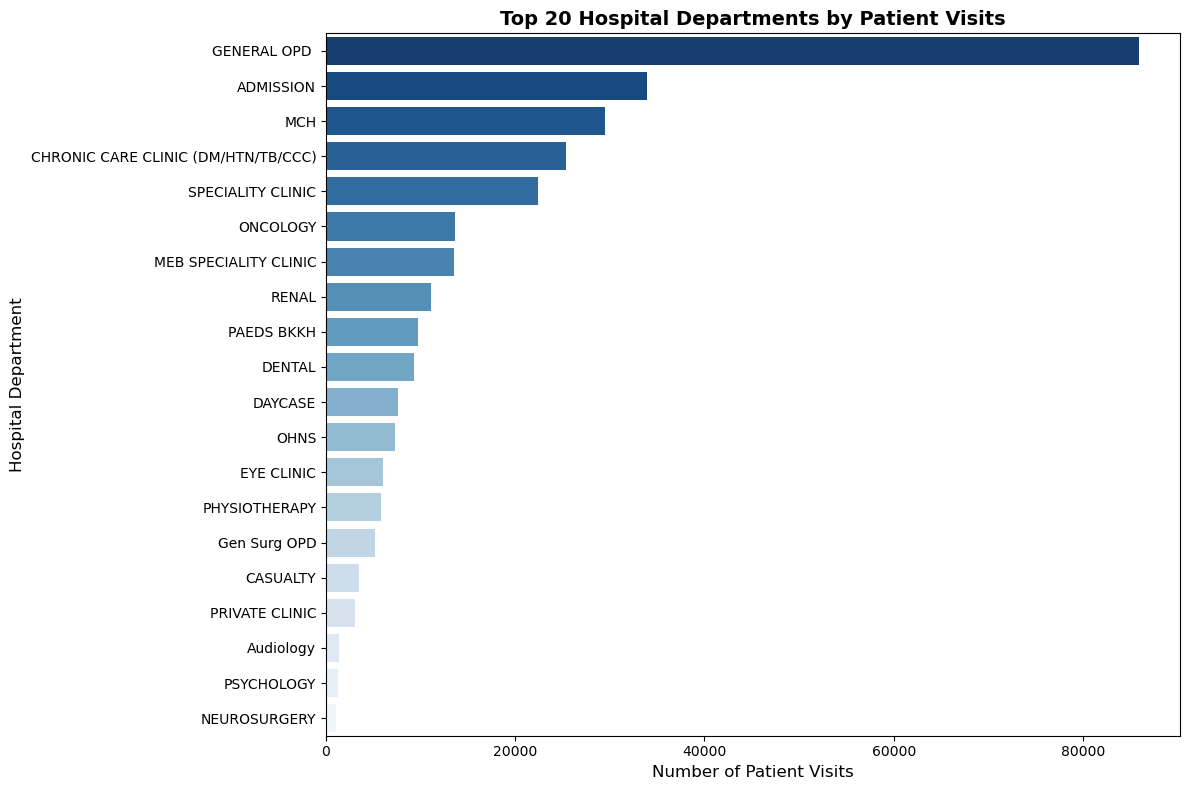

In [9]:
# visits per department and sort descending for top 20
dept_counts = data["QueuedTo"].value_counts().head(20)
plt.figure(figsize=(12,8))

# horizontal bar plot
sns.barplot(x=dept_counts.values, y=dept_counts.index, palette="Blues_r")

plt.title("Top 20 Hospital Departments by Patient Visits", fontsize=14, fontweight="bold")
plt.xlabel("Number of Patient Visits", fontsize=12)
plt.ylabel("Hospital Department", fontsize=12)
plt.tight_layout()

plt.savefig(

    'patient_visits_by_department.png',

    dpi=300,

    bbox_inches='tight')
plt.show()

In [10]:
print(data['ConsultDescription'].unique())

['GEneral Outpatient Care( NEW )' nan 'General Outpatient Care'
 'Admission' 'EMERGENCY' 'CONSULT' 'RENAL DIALYSIS'
 'Child Welfare and Immunization (CWC)' 'MCH Clinic' 'Physiotherapy'
 'MCH (New Patient)' 'DAYCASE' 'Dental Care' 'ORTHOPEDIC' 'UROLOGY'
 'COUNSELLING PSYCHOLOGY' 'ENT First Visit' 'Chemotherapy'
 'GENERAL SURGERY' 'Ophthalmology.' 'ENT Return Visit' 'Pediatrics '
 'Comprehensive Care Centre (CCC)' 'Developmental Clinic '
 'Palliative Revisit' 'Diabetic clinic' 'Staff Clinic' 'ECHO'
 'Gen Surg OPD' 'PLASTICS' 'Cardiology' 'ONCOLOGY CONSULTATION' 'RVA'
 'GYNAECOLOGY' 'Nutrition Consult' 'OCCUPATIONAL THERAPY'
 'SPECIALITY IMED' 'BREAST' 'ANC Revisit' 'Family Planning'
 'Consultant Clinic' 'Paediatric Psychiatry' 'Psychiatry'
 'RENAL CONSULTATION' 'Oncology Service' 'Revisit' 'Counselling'
 'Hepatitis b vaccine' 'PEADS SURGE' 'Clinical psychology consultation'
 'TB CLINIC' 'Postnatal (PNC)' 'HAND CLINIC' 'HYPERTENSION CLINIC'
 'Gyn-oncology' 'Surgical OPD' 'TELEMEDICINE' 'E

In [11]:
#checking for missing values
data.isna().sum()

PatientNumber            0
RegistrationDate         0
Gender                  15
Age                    571
QueuedTo              6778
ConsultDescription    6386
dtype: int64

In [12]:
missing = data.isnull().sum()
missing_percent = (missing/len(data)) * 100
pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_percent
})

,Missing Count,Missing %
PatientNumber,0,0.000000
RegistrationDate,0,0.000000
Gender,15,0.004897
Age,571,0.186415
QueuedTo,6778,2.212820
ConsultDescription,6386,2.084843


Observation: There are missing values, however they make up a small percentage of the whole data so dropping them will not cause us to lose important insights of the data

In [13]:
#checking for duplicated values
data.duplicated().sum()

355

Observation: We will drop these duplicate values so that we ensure our model learns actual patterns and not repetative ones

In [14]:
#checking how many patients have visited hospital
print(data['PatientNumber'].nunique())
print(len(data))

80927
306306


observation: 80928 patients visited the hospital and the length of the data being larger indicated that there has been patients who have returned to the hospital

In [15]:
# example of return patients
visits = data['PatientNumber'].value_counts()
visits.head()

PatientNumber
10099285    266
10543010    252
10527584    249
10112639    248
10315077    247
Name: count, dtype: int64

In [16]:
# Minimum and maximum dates
dates = pd.to_datetime(data['RegistrationDate'], errors='coerce')
print(f'min: {dates.min()}')
print(f'max: {dates.max()}')

# Time destribution
dates.dt.hour.value_counts().sort_index()

min: 2024-06-01 00:00:00
max: 2026-08-19 11:41:00


RegistrationDate
0     19822
1      1679
2      1042
3       958
4      1627
5      4440
6      9234
7     25072
8     55567
9     51437
10    35298
11    28744
12    20167
13    12188
14    10107
15     8478
16     6645
17     3638
18     2567
19     2085
20     1771
21     1543
22     1245
23      952
Name: count, dtype: int64

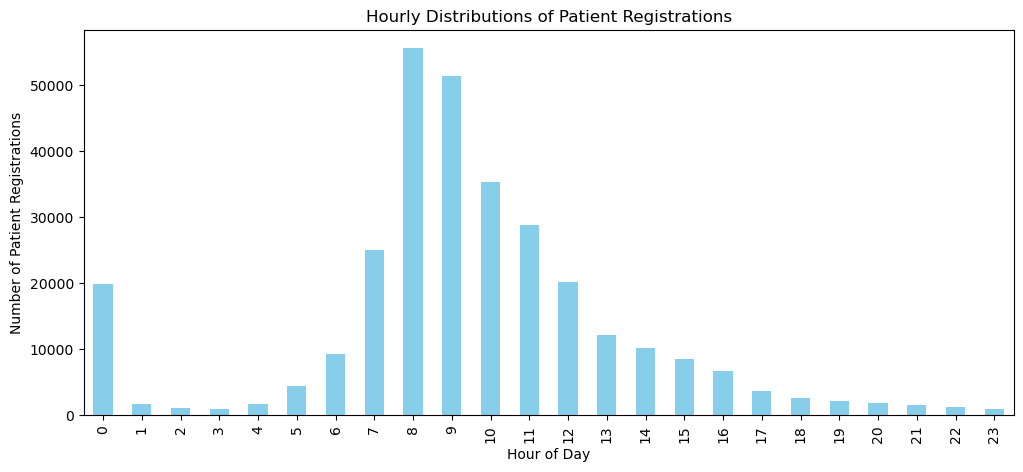

In [17]:
#visual
data["temp_datetime"] = dates
data["hour"] = dates.dt.hour

data["hour"].value_counts().sort_index().plot(
    kind="bar",
    figsize=(12,5),
    title="Hourly Distributions of Patient Registrations",
    color='skyblue')
plt.ylabel('Number of Patient Registrations')
plt.xlabel('Hour of Day')

plt.savefig('hourly_patient_registrations.png', dpi=300, bbox_inches='tight')
plt.show()

Observation: The busiest hours of the day are usually within 07:00 and 14:00 having the high number of patients. From the time range 08:00 and 09:00 are the busiest

In [18]:
# daily visits
data['temp_datetime'].dt.day_name().value_counts()

temp_datetime
Monday       60299
Tuesday      59702
Thursday     59142
Wednesday    55624
Friday       52464
Saturday     11339
Sunday        7736
Name: count, dtype: int64

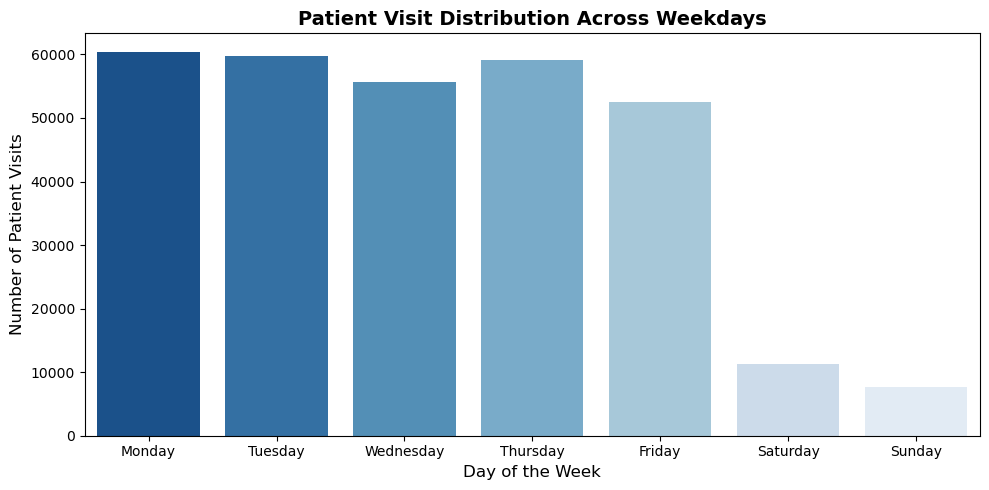

In [19]:
data["RegistrationDate"] = pd.to_datetime(data["RegistrationDate"], errors="coerce")
data["day_of_week"] = data["RegistrationDate"].dt.day_name()

# Define chronological weekday order
weekday_order = [
    "Monday", "Tuesday", "Wednesday", "Thursday",
    "Friday", "Saturday", "Sunday"
]

# Count visits per weekday and reindex
weekday_counts = data["day_of_week"].value_counts().reindex(weekday_order)

# Plot distribution
plt.figure(figsize=(10, 5))
sns.barplot(x=weekday_counts.index, y=weekday_counts.values, palette="Blues_r")
plt.title("Patient Visit Distribution Across Weekdays", fontsize=14, fontweight="bold")
plt.xlabel("Day of the Week", fontsize=12)
plt.ylabel("Number of Patient Visits", fontsize=12)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

*Monday Peak*

Patient volume is highest on Monday and declines steadily through the week,
consistent with backlog from the weekend clearing at the start of the week.

*Weekend Drop-off*

Volumes decline sharply over the weekend, reflecting reduced ambulatory service
hours and limited elective scheduling, which leaves emergency and inpatient
units handling the baseline load.

In [20]:
#Number of departments and how many visits
print(f'Number of departments:', data["QueuedTo"].nunique())
data['QueuedTo'].value_counts(dropna=False)

Number of departments: 44


QueuedTo
GENERAL OPD                            85959
ADMISSION                              33880
MCH                                    29467
CHRONIC CARE CLINIC (DM/HTN/TB/CCC)    25366
SPECIALITY CLINIC                      22356
ONCOLOGY                               13606
MEB SPECIALITY CLINIC                  13523
RENAL                                  11103
PAEDS BKKH                              9734
DENTAL                                  9252
DAYCASE                                 7596
OHNS                                    7290
NaN                                     6778
EYE CLINIC                              6027
PHYSIOTHERAPY                           5826
Gen Surg OPD                            5156
CASUALTY                                3460
PRIVATE CLINIC                          3075
Audiology                               1379
PSYCHOLOGY                              1223
NEUROSURGERY                            1032
OCCUPATIONAL THERAPY                     815
N

In [21]:
# Visits per consultation type
data["ConsultDescription"].value_counts(dropna=False)

ConsultDescription
General Outpatient Care           49377
Admission                         33886
CONSULT                           33336
GEneral Outpatient Care( NEW )    21398
MCH Clinic                        19465
                                  ...  
PAIN CLINIC                           2
Head & Neck Return Visit              1
Staff Wellness Package                1
HEAD AND NECK VISIT                   1
Private Gyn Oncology                  1
Name: count, Length: 80, dtype: int64

Observation: Majority visits are:
- General Outpatient Care           
- Admission                         
- CONSULT

In [22]:
#Distribution of gender
data["Gender"].value_counts(dropna=False)


Gender
Female    142251
Male      112802
FEMALE     32185
MALE       19053
NaN           15
Name: count, dtype: int64

Observation: Theres inconsistent formating which needs to be cleaned

In [23]:
#Age distribution
data["Age"].value_counts()

Age
2 Yr(s)      7464
31 Yr(s)     5741
30 Yr(s)     5533
29 Yr(s)     5418
33 Yr(s)     5255
             ... 
2 Days(s)       2
117 Yr(s)       1
107 Yr(s)       1
3 Days(s)       1
121 Yr(s)       1
Name: count, Length: 142, dtype: int64

Observation

1. Data description
- What's in it: Patient ID, registration date/time, gender, age (written as text, like "38 Yr(s)"), which department the patient was sent to (44 possible departments), and the type of visit (79 possible types). Everything is text or dates no ready-made numbers or categories yet.
- Who the patients are: 80,928 different patients, visiting 3.8 times on average. About 57% are female, 43% male. Median age is 40. Most patients only come once (39%), but a small group (7.7%) comes 10+ times, likely people with ongoing conditions needing regular care.
- Departments: 7 out of 44 departments make up about 70% of all visits, General Outpatient, Admission, MCH, Chronic Care, Speciality Clinic, Oncology, and Renal. The rest get far fewer visits.
- Patterns over time: More patients come on weekdays than weekends, with Monday the busiest and weekends much quieter. Most patients arrive between 8-9am, then it tapers off through the day. 

2. Verify Data Quality

These are common problems in hospital records like this none of them are serious enough to stop the project, but they all need fixing before we build any models:

- Missing information: some rows are missing gender (15), age (571), department (6,778), or visit type (6,386). The missing department and visit type are the most important to fix, since they're central to what we're trying to study.
- 355 rows are exact copies of another row which are probably accidental double entries.
- Gender is written inconsistently: sometimes "Male", sometimes "MALE".
- Visit types are written inconsistently too, with typos and different spellings for what should be the same thing (e.g. "General Outpatient Care" vs "GEneral Outpatient Care( NEW )"). We'll need to fix the typos but keep any real differences, like whether it's a new or returning patient.
- Age is written as text, not numbers, and mixes different units (years, months, weeks, days), so it needs to be converted before we can use it.
- A few ages are unrealistic (over 110 years old) — most likely mistakes.
- 3 rows list departments that don't make sense — they look like test entries, not real departments.
- 10,292 rows show an exact midnight timestamp, which is probably just a placeholder for "we don't know the exact time" rather than real midnight visits — so we should be careful using time-of-day data for these.

# Data Cleaning

### Missing Values

In [24]:
# missing dependable columns queuedto & consultdescription
missing_counts = data[["QueuedTo", "ConsultDescription"]].isna().sum()
print(print(missing_counts))

QueuedTo              6778
ConsultDescription    6386
dtype: int64
None


In [25]:
# boolean to check for rows where both are null
both_missing = data["QueuedTo"].isna() & data["ConsultDescription"].isna()

print(f"Rows where both are missing: {both_missing.sum()}")

Rows where both are missing: 6386


In [26]:
# A side by side comparison of both columns for rows where at least one is missing
missing_audit = data[data["QueuedTo"].isna() | data["ConsultDescription"].isna()]

missing_audit[["PatientNumber", "RegistrationDate", "QueuedTo", "ConsultDescription",]].sample(5)

,PatientNumber,RegistrationDate,QueuedTo,ConsultDescription
302797,10631340,2026-08-12 00:00:00,NaN,NaN
158055,10523942,2025-08-14 00:00:00,NaN,NaN
20417,10516661,2024-07-30 00:42:00,NaN,MCH Clinic
17602,10565572,2024-07-22 00:00:00,NaN,NaN
174256,3015170,2025-09-25 00:00:00,NaN,NaN


**Observation:**

Correlated missing values

The missing counts in 'QueuedTo' and 'ConsultDescription' columns are close in magnitude 6778 and 6386 missing values respectively suggesting that the missing values often occur as an unregistered patient encounters where routing metdata was never logged



In [27]:
# drop rows where both queuedto and consultdescription are nan
df_cleaned = data.dropna(subset=["QueuedTo", "ConsultDescription"], inplace=True)

In [28]:
missing_counts2 = data[["QueuedTo", "ConsultDescription"]].isna().sum()
print(print(missing_counts2))

QueuedTo              0
ConsultDescription    0
dtype: int64
None


### Duplicates

In [29]:
data[data.duplicated(keep=False)].sort_values('PatientNumber').head()

,PatientNumber,RegistrationDate,Gender,Age,QueuedTo,ConsultDescription,temp_datetime,hour,day_of_week
172478,10607509,2025-09-19 17:03:00,Male,18 Yr(s),GENERAL OPD,GEneral Outpatient Care( NEW ),2025-09-19 17:03:00,17,Friday
172479,10607509,2025-09-19 17:03:00,Male,18 Yr(s),GENERAL OPD,GEneral Outpatient Care( NEW ),2025-09-19 17:03:00,17,Friday
172484,10607511,2025-09-19 17:47:00,Female,22 Yr(s),GENERAL OPD,GEneral Outpatient Care( NEW ),2025-09-19 17:47:00,17,Friday
172485,10607511,2025-09-19 17:47:00,Female,22 Yr(s),GENERAL OPD,GEneral Outpatient Care( NEW ),2025-09-19 17:47:00,17,Friday
172494,10607515,2025-09-19 21:22:00,Female,21 Yr(s),GENERAL OPD,GEneral Outpatient Care( NEW ),2025-09-19 21:22:00,21,Friday


**Observation**

Recorded variables i.e PatientNumber, RegistrationDate, Gender, Age, QueuedTo, ConsultDescription match identically between paired index rows confirming complete transactional duplication rather than clinical routing

In [30]:
# total duplicates
data.duplicated().sum()

355

In [31]:
# total unique duplicates
print(data.duplicated(subset=["PatientNumber", "RegistrationDate"]).sum())

366


In [32]:
# drop duplicates
data = data.drop_duplicates()

data.duplicated().sum()

0

In [33]:
dupes = data[data.duplicated(subset=["PatientNumber", "RegistrationDate"],keep=False)
            ].sort_values(["PatientNumber", "RegistrationDate"])

dupes

,PatientNumber,RegistrationDate,Gender,Age,QueuedTo,ConsultDescription,temp_datetime,hour,day_of_week
193239,10611177,2025-11-11 13:40:00,Female,54 Yr(s),GENERAL OPD,GEneral Outpatient Care( NEW ),2025-11-11 13:40:00,13,Tuesday
193240,10611177,2025-11-11 13:40:00,Female,54 Yr(s),ADMISSION,Admission,2025-11-11 13:40:00,13,Tuesday
201188,10612669,2025-12-01 15:09:00,Female,54 Yr(s),GENERAL OPD,CONSULT,2025-12-01 15:09:00,15,Monday
201189,10612669,2025-12-01 15:09:00,Female,54 Yr(s),GENERAL OPD,GEneral Outpatient Care( NEW ),2025-12-01 15:09:00,15,Monday
208810,10614068,2025-12-21 20:15:00,Female,68 Yr(s),GENERAL OPD,GEneral Outpatient Care( NEW ),2025-12-21 20:15:00,20,Sunday
208811,10614068,2025-12-21 20:15:00,Female,68 Yr(s),ADMISSION,Admission,2025-12-21 20:15:00,20,Sunday
245573,10621065,2026-03-24 20:39:00,Male,43 Yr(s),GENERAL OPD,GEneral Outpatient Care( NEW ),2026-03-24 20:39:00,20,Tuesday
245574,10621065,2026-03-24 20:39:00,Male,43 Yr(s),GENERAL OPD,CONSULT,2026-03-24 20:39:00,20,Tuesday
245923,10621132,2026-03-25 11:30:00,Male,54 Yr(s),GENERAL OPD,ENT First Visit,2026-03-25 11:30:00,11,Wednesday
245924,10621132,2026-03-25 11:30:00,Male,54 Yr(s),GENERAL OPD,GEneral Outpatient Care( NEW ),2026-03-25 11:30:00,11,Wednesday


In [34]:
# drop unique duplicates
records = [193239, 201189, 208810, 245573, 282393, 300782, 296103, 296102, 296046, 279573,267040, 245923]

data = data.drop(records)

**Observation**

The cleaning specifically redundant (NEW) registration logging records such as patient 010611177 shown in indicies 193239 and 193240 implying the dropped rows are secondary
However the patients' comprehensive historical follow up visits were maintained

### Cleaning Timestamps

In [35]:
# total number of midnight entries(00:00)
midnight = data[
    pd.to_datetime(data["RegistrationDate"]).dt.time ==
    pd.Timestamp("00:00").time()
]

print(len(midnight))

10336


In [36]:
midnight.head()

,PatientNumber,RegistrationDate,Gender,Age,QueuedTo,ConsultDescription,temp_datetime,hour,day_of_week
0,10575758,2024-06-01,Male,38 Yr(s),GENERAL OPD,GEneral Outpatient Care( NEW ),2024-06-01,0,Saturday
97,10575762,2024-06-02,Female,28 Yr(s),CASUALTY,EMERGENCY,2024-06-02,0,Sunday
167,3009939,2024-06-03,Female,82 Yr(s),ADMISSION,Admission,2024-06-03,0,Monday
168,3010823,2024-06-03,Female,68 Yr(s),ADMISSION,Admission,2024-06-03,0,Monday
170,20092792,2024-06-03,Female,76 Yr(s),ADMISSION,Admission,2024-06-03,0,Monday


In [37]:
# counts per department
midnight[["ConsultDescription", "QueuedTo"]].value_counts().head(20)

ConsultDescription              QueuedTo                           
Admission                       ADMISSION                              7747
DAYCASE                         DAYCASE                                2098
General Outpatient Care         GENERAL OPD                             146
MCH Clinic                      MCH                                      38
RENAL DIALYSIS                  RENAL                                    28
ORTHOPEDIC                      SPECIALITY CLINIC                        24
CONSULT                         DAYCASE                                  24
                                GENERAL OPD                              17
ORTHOPEDIC                      MEB SPECIALITY CLINIC                    17
GENERAL SURGERY                 SPECIALITY CLINIC                        14
CONSULT                         Gen Surg OPD                             13
GEneral Outpatient Care( NEW )  GENERAL OPD                              12
ENT Return Visit    

**Observation**

The concentration of 00:00 timestamps that represent a significant volume of records strongly indicates an administrative fallback default where the exact administration times were'nt captured by the system.

These can be observed dominating Admission and  DAYCASE categories which dont reflect standard walk-ins.

In [38]:
# exact midnigt records
data["RegistrationDate"] = pd.to_datetime(data["RegistrationDate"])

time = data["is_exact_midnight"] = (data["RegistrationDate"].dt.hour == 0) & (data["RegistrationDate"].dt.minute == 0) & (data["RegistrationDate"].dt.second == 0)

print(data["is_exact_midnight"].value_counts())

is_exact_midnight
False    288825
True      10336
Name: count, dtype: int64


In [39]:
data[~data["is_exact_midnight"]].head()

,PatientNumber,RegistrationDate,Gender,Age,QueuedTo,ConsultDescription,temp_datetime,hour,day_of_week,is_exact_midnight
2,10569291,2024-06-01 00:04:00,Female,44 Yr(s),GENERAL OPD,General Outpatient Care,2024-06-01 00:04:00,0,Saturday,False
3,10575732,2024-06-01 00:04:00,Female,78 Yr(s),GENERAL OPD,General Outpatient Care,2024-06-01 00:04:00,0,Saturday,False
4,10575731,2024-06-01 00:10:00,Female,2 Yr(s),ADMISSION,Admission,2024-06-01 00:10:00,0,Saturday,False
5,10454966,2024-06-01 01:22:00,FEMALE,31 Yr(s),GENERAL OPD,General Outpatient Care,2024-06-01 01:22:00,1,Saturday,False
6,10573369,2024-06-01 01:36:00,Female,84 Yr(s),GENERAL OPD,General Outpatient Care,2024-06-01 01:36:00,1,Saturday,False


In [40]:
from datetime import time
# sort time to be retained
data["RegistrationDate"] = pd.to_datetime(data["RegistrationDate"], errors="coerce")

# time filter mask safely
start_time = time(0, 0, 0)
end_time = time(0, 59, 59)
mask = data["RegistrationDate"].dt.time.between(start_time, end_time)
late_night_patients = data[mask]

print(f"Total late night records: {len(late_night_patients)}")

Total late night records: 13257


In [41]:
mapping = (data.dropna(subset=["QueuedTo", "ConsultDescription"]).groupby("ConsultDescription")["QueuedTo"].agg(lambda x: x.value_counts().index[0]))
mapping.sample(5)

ConsultDescription
Palliative Revisit                                   PALLIATIVE
Eye Clinic                                           EYE CLINIC
Revisit                                                  DENTAL
General Wellness Package                      SPECIALITY CLINIC
Staff Wellness Package      CHRONIC CARE CLINIC (DM/HTN/TB/CCC)
Name: QueuedTo, dtype: object

In [42]:
midnight_copy = data.copy()

In [43]:
# index label positions where midnight occurs
data["RegistrationDate"] = pd.to_datetime(data["RegistrationDate"], errors="coerce")
data["is_exact_midnight"] = data["RegistrationDate"].dt.time == pd.to_datetime("00:00:00").time()

midnight_labels = data[data["is_exact_midnight"]].index

sample_labels = []
for label in midnight_labels[:5]:
    #  positional index of this label get surrounding rows by label
    pos = data.index.get_loc(label)
    start_pos = max(0, pos - 2)
    end_pos = min(len(data) - 1, pos + 2)
    sample_labels.extend(data.index[start_pos:end_pos + 1])

print(data.loc[list(set(sample_labels)), ["PatientNumber", "RegistrationDate", "QueuedTo"]])

    PatientNumber    RegistrationDate      QueuedTo
0        10575758 2024-06-01 00:00:00  GENERAL OPD 
96       10303277 2024-06-01 22:11:00      CASUALTY
2        10569291 2024-06-01 00:04:00  GENERAL OPD 
3        10575732 2024-06-01 00:04:00  GENERAL OPD 
97       10575762 2024-06-02 00:00:00      CASUALTY
98       10516406 2024-06-02 00:13:00           MCH
99       10575757 2024-06-02 00:30:00  GENERAL OPD 
165      10212494 2024-06-02 21:52:00  GENERAL OPD 
166      10044425 2024-06-02 22:39:00  GENERAL OPD 
167       3009939 2024-06-03 00:00:00     ADMISSION
168       3010823 2024-06-03 00:00:00     ADMISSION
170      20092792 2024-06-03 00:00:00     ADMISSION
173      10575785 2024-06-03 00:00:00  GENERAL OPD 
174      10572681 2024-06-03 00:00:00     ADMISSION
95       10237889 2024-06-01 21:22:00     ADMISSION


In [44]:
# drop the exact midnight records
data = data[~data["is_exact_midnight"]].copy()

In [45]:
data[["PatientNumber", "RegistrationDate", "is_exact_midnight"]].head()

,PatientNumber,RegistrationDate,is_exact_midnight
2,10569291,2024-06-01 00:04:00,False
3,10575732,2024-06-01 00:04:00,False
4,10575731,2024-06-01 00:10:00,False
5,10454966,2024-06-01 01:22:00,False
6,10573369,2024-06-01 01:36:00,False


**Observation**

Dropping of the exact midnight records eliminates artificial spikes that dont reflect true patient flow dynamics, preserving legitimate midnight records that range from 00:01-00:59

### Cleaning Gender and Age


In [46]:
# missing counts for gender and age
missing_gender = data['Gender'].isna().sum()
print(missing_gender)

missing_age = data['Age'].isna().sum()
print(missing_age)

11
552


In [47]:
# display missing  gender and age
data[data["Gender"].isna()][["PatientNumber", "RegistrationDate", "Gender", "Age", "QueuedTo", "ConsultDescription"]].sample(min(5, data["Gender"].isna().sum()))

,PatientNumber,RegistrationDate,Gender,Age,QueuedTo,ConsultDescription
98185,10469622,2025-03-09 08:18:00,NaN,NaN,GENERAL OPD,General Outpatient Care
97717,10593997,2025-03-07 09:03:00,NaN,NaN,MCH,Child Welfare and Immunization (CWC)
93893,10514912,2025-02-26 11:36:00,NaN,NaN,PHYSIOTHERAPY,Physiotherapy
199254,10585697,2025-11-26 08:31:00,NaN,NaN,PAEDS BKKH,Pediatrics
21006,10576013,2024-07-31 09:15:00,NaN,NaN,PAEDS BKKH,Pediatrics


In [48]:
# drop rows where either age or  gender is nan
data = data.dropna(subset=["Age", "Gender"])

**Observation**

Missing demographic data where 11 missing gender entries and 552 missing age entries accounts for less tahn 0.2% of the data set ensuring unbiased demographic distributions across teh cohort

### Dropping irelevant data

In [49]:
history = data[data["QueuedTo"] == "Naivasha Town Clinic"]
history

,PatientNumber,RegistrationDate,Gender,Age,QueuedTo,ConsultDescription,temp_datetime,hour,day_of_week,is_exact_midnight
130200,10597967,2025-06-03 06:57:00,Male,79 Yr(s),Naivasha Town Clinic,CONSULT,2025-06-03 06:57:00,6,Tuesday,False


In [50]:
patient_history = data[data["PatientNumber"] == "010597967"]
patient_history

,PatientNumber,RegistrationDate,Gender,Age,QueuedTo,ConsultDescription,temp_datetime,hour,day_of_week,is_exact_midnight


In [51]:
# drop irelevant data
records = [23832,305481,130200]

data = data.drop(records)

In [52]:
cols = ['temp_datetime', 'hour', 'day_of_week', 'is_exact_midnight']
data = data.drop(columns=cols, errors='ignore')

In [53]:
data.head()

,PatientNumber,RegistrationDate,Gender,Age,QueuedTo,ConsultDescription
2,10569291,2024-06-01 00:04:00,Female,44 Yr(s),GENERAL OPD,General Outpatient Care
3,10575732,2024-06-01 00:04:00,Female,78 Yr(s),GENERAL OPD,General Outpatient Care
4,10575731,2024-06-01 00:10:00,Female,2 Yr(s),ADMISSION,Admission
5,10454966,2024-06-01 01:22:00,FEMALE,31 Yr(s),GENERAL OPD,General Outpatient Care
6,10573369,2024-06-01 01:36:00,Female,84 Yr(s),GENERAL OPD,General Outpatient Care


In [54]:
data.to_csv("opd_clean.csv", index=False)

# Feature Engineering

### Patients Patterns and Return Behavior

In [55]:
data = pd.read_csv("opd_clean.csv")

df=data.copy()
df['RegistrationDate'] = pd.to_datetime(df['RegistrationDate'], errors='coerce')

In [56]:
#check the age values
df["Age"].value_counts().head(10)

Age
2 Yr(s)     6999
31 Yr(s)    5448
30 Yr(s)    5229
29 Yr(s)    5157
33 Yr(s)    4956
36 Yr(s)    4819
34 Yr(s)    4797
40 Yr(s)    4759
32 Yr(s)    4713
42 Yr(s)    4698
Name: count, dtype: int64

In [57]:
# check what units exist in Age
df['Age'].str.extract(r'\d+\s*(\D+)')[0].str.strip().value_counts()

0
Yr(s)      274587
Mth(s)      13473
Week(s)       187
Days(s)        23
Name: count, dtype: int64

In [58]:
# split the number from the unit
age_parts = df["Age"].str.extract(r"(?P<num>\d+)\s*(?P<unit>\D+)")
age_parts["num"] = age_parts["num"].astype(int)
age_parts["unit"] = age_parts["unit"].str.strip().str.lower()

# convert everything to years
unit_yrs = {"yr(s)": 1, "mth(s)": 1/12, "week(s)": 1/52, "days(s)": 1/365}
df["Age_num"] = age_parts["num"] * age_parts["unit"].map(unit_yrs)

# confirm every unit was recognised
print(age_parts["unit"].unique())

['yr(s)' 'mth(s)' 'week(s)' 'days(s)']


The Age column mixes units: 44 Yr(s), 6 Mth(s), 3 Week(s), 10 Days(s). Extracting only the digits would read "6 Mth(s)" as 6 years, misclassifying
roughly 13,700 infant records as children.

We therefore split each value into its number and its unit, convert everything to a common scale (years), and store the result in Age_num. The unit check confirms all four units present in the file were recognised.

In [59]:
#Create age groups

def get_age_group(age):
    if age < 1:
        return 'Infant'
    elif age <= 12:
        return 'Child'
    elif age <= 17:
        return 'Adolescent'
    elif age <= 50:
        return 'Adult'
    else:
        return 'Senior'

df['AgeGroup'] = df['Age_num'].apply(get_age_group)


In [60]:
# Sanity check for the age groups
df[['Age_num', 'AgeGroup']].head(10)

,Age_num,AgeGroup
0,44.0,Adult
1,78.0,Senior
2,2.0,Child
3,31.0,Adult
4,84.0,Senior
5,46.0,Adult
6,50.0,Adult
7,37.0,Adult
8,9.0,Child
9,60.0,Senior


In [61]:
#count patients in each age group
df["AgeGroup"].value_counts()

AgeGroup
Adult         127870
Senior        104908
Child          39665
Adolescent      9860
Infant          5967
Name: count, dtype: int64

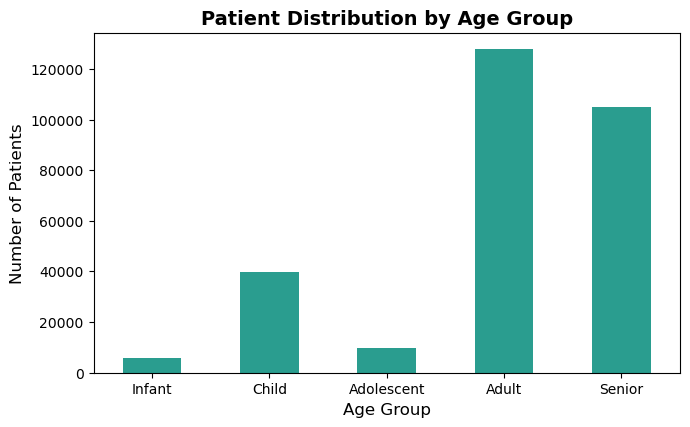

In [62]:
# Visualize the number of patients in each age group
age_counts = df["AgeGroup"].value_counts()
age_order = ['Infant', 'Child', 'Adolescent', 'Adult', 'Senior']
age_counts = age_counts.reindex(age_order)
plt.figure(figsize=(7,5))

age_counts.plot(kind="bar",color="#2a9d8f")
plt.title("Patient Distribution by Age Group", fontsize =14, fontweight = 'bold')

plt.xlabel("Age Group", fontsize =12)
plt.ylabel("Number of Patients", fontsize =12)
plt.tight_layout()
plt.xticks(rotation=0)

plt.show()

Observation: Most of the records are from adults followed by the seniors then the children while adolescents and infants have the fewest records.

In [63]:
#check the number of patients by gender
gender_counts=df["Gender"].value_counts()
gender_counts

Gender
Female    134298
Male      104393
FEMALE     31210
MALE       18369
Name: count, dtype: int64

In [64]:
#Standardize gender labels
df["Gender"] = df["Gender"].str.upper().str.strip()
# Check the result
df["Gender"].value_counts()


Gender
FEMALE    165508
MALE      122762
Name: count, dtype: int64

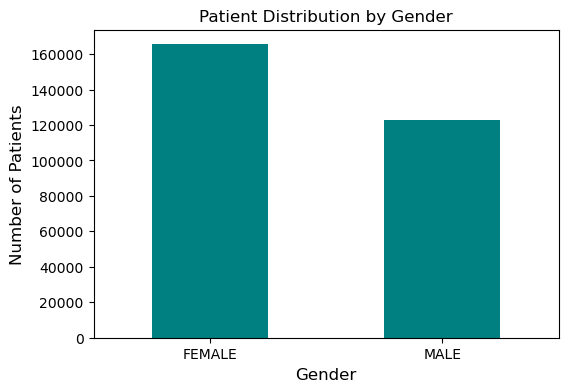

In [65]:
#visualize patients by gender
gender_counts = df["Gender"].value_counts()
plt.figure(figsize=(8,6))

gender_counts.plot(kind="bar", color = "teal", figsize =(6,4))

plt.title("Patient Distribution by Gender")
plt.xlabel("Gender", fontsize=12)
plt.ylabel("Number of Patients", fontsize=12)
plt.xticks(rotation=0)
plt.show()

#### Return visit feature

In [66]:
# Create a return visit feature
df["ReturnVisit"] = df["PatientNumber"].duplicated(keep="first")

# Check the result
df["ReturnVisit"].value_counts()

ReturnVisit
True     207661
False     80609
Name: count, dtype: int64

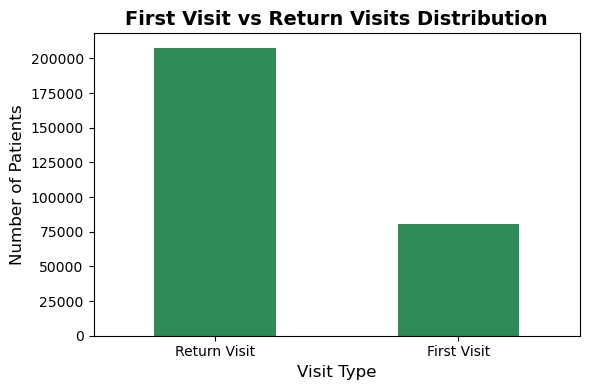

In [67]:
# Visualize first visits and return visits
return_counts = df["ReturnVisit"].value_counts()
return_counts.index = ["Return Visit" if x else "First Visit" for x in return_counts.index]

return_counts.plot(kind="bar", color = "seagreen", figsize =(6,4))

plt.title("First Visit vs Return Visits Distribution", fontsize =14, fontweight ='bold')
plt.xlabel("Visit Type", fontsize =12)
plt.ylabel("Number of Patients", fontsize=12)
plt.xticks(rotation=0)

plt.tight_layout()       
plt.show()

*observation:* Return visits substantially outnumber first visits, indicating that a large proportion of the hospital’s recorded activity comes from patients returning for subsequent care or follow-up.

In [68]:
#RETURN BEHAVIOR BY AGE GROUP
# Check return visits across age groups
age_return = pd.crosstab(df["AgeGroup"], df["ReturnVisit"])

age_return

ReturnVisit,False,True
AgeGroup,,
Adolescent,3587,6273
Adult,36567,91303
Child,13460,26205
Infant,2264,3703
Senior,24731,80177


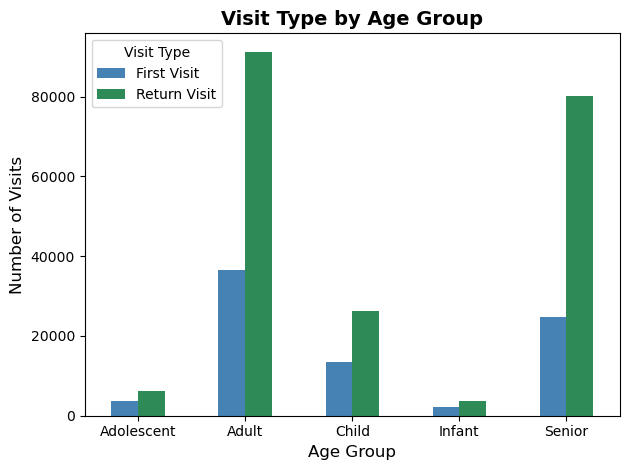

In [69]:
# Visualize first vs return visits by age group

age_return.plot(kind="bar", color = ['steelblue','seagreen'])

plt.title("Visit Type by Age Group", fontsize=14, fontweight="bold")

plt.xlabel("Age Group", fontsize=12)
plt.ylabel("Number of Visits", fontsize=12)
plt.xticks(rotation=0)
plt.legend(["First Visit", "Return Visit"], title="Visit Type")

plt.tight_layout()

plt.show()

*Observation:* Return visits exceed first visits across all age groups, with adults and seniors recording the highest visit volumes.

In [70]:
# Check return visits across gender
gender_return = pd.crosstab(df["Gender"], df["ReturnVisit"])

gender_return

ReturnVisit,False,True
Gender,,
FEMALE,45732,119776
MALE,34877,87885


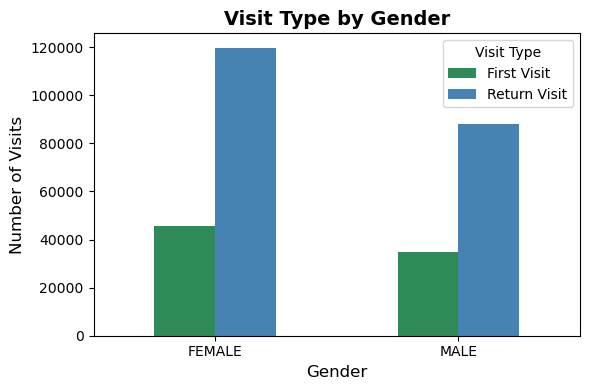

In [71]:
# Check return visits across gender
gender_return = pd.crosstab(df["Gender"], df["ReturnVisit"])

# Visualize first vs return visits by gender
gender_return.plot(kind="bar",color=["seagreen", "steelblue"], figsize = (6,4))

plt.title("Visit Type by Gender", fontsize=14, fontweight="bold")
plt.xlabel("Gender", fontsize=12)
plt.ylabel("Number of Visits", fontsize=12)
plt.xticks(rotation=0)
plt.legend(["First Visit", "Return Visit"], title="Visit Type")

plt.tight_layout()
plt.show()

*Observation:* Return visits exceed first visits for both genders. Female patients record higher numbers of both first and return visits compared with male patients.

In [72]:
# Calculate return rate for each age group
age_return_rate = pd.crosstab(
    df["AgeGroup"],
    df["ReturnVisit"],
    normalize="index"
) * 100

age_return_rate

ReturnVisit,False,True
AgeGroup,,
Adolescent,36.379310,63.620690
Adult,28.597013,71.402987
Child,33.934199,66.065801
Infant,37.942014,62.057986
Senior,23.573989,76.426011


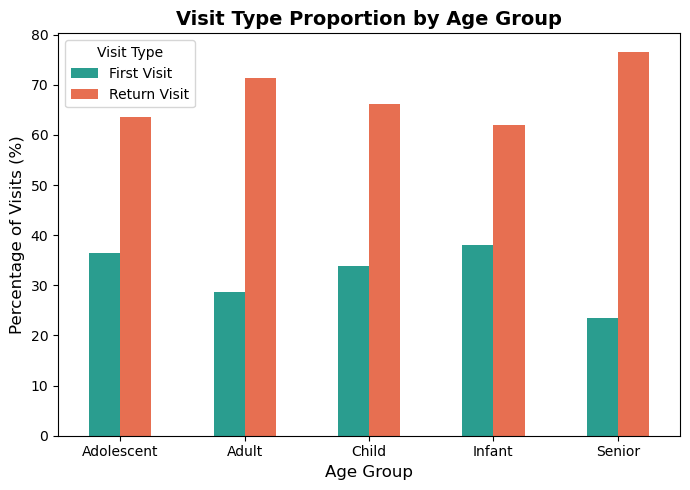

In [73]:
# Visualize return rates by age group
age_return_rate.plot(kind="bar", figsize=(7, 5), color=["#2A9D8F", "#E76F51"])

plt.title("Visit Type Proportion by Age Group", fontsize=14, fontweight="bold")
plt.xlabel("Age Group", fontsize=12)
plt.ylabel("Percentage of Visits (%)", fontsize=12)
plt.xticks(rotation=0)

plt.legend(["First Visit", "Return Visit"], title="Visit Type")
plt.tight_layout()

plt.show()

*Observation:* Return visits account for the majority of visits across all age groups. However, the return rate varies between age groups, suggesting that age may be associated with the likelihood of a patient returning for subsequent care.



In [74]:
# Check return visits by consultation type
consult_return = pd.crosstab(
    df["ConsultDescription"],
    df["ReturnVisit"]
)

consult_return

ReturnVisit,False,True
ConsultDescription,,
ANC First Visit,3,2
ANC Revisit,5,18
Admission,5269,20759
Adult Neurology,35,147
Anaesthesia Consult,11,62
...,...,...
Staff Wellness Package,0,1
Surgical OPD,0,2
TB CLINIC,0,16


In [75]:
# Find the consultation types with the most return visits
top_return = consult_return.sort_values(by=True, ascending=False).head(10)

top_return

ReturnVisit,False,True
ConsultDescription,,
General Outpatient Care,11291,37739
Admission,5269,20759
CONSULT,13637,19578
MCH Clinic,3228,16034
RENAL DIALYSIS,55,10960
Chemotherapy,297,10483
ORTHOPEDIC,1417,9599
Comprehensive Care Centre (CCC),1396,6976
Pediatrics,1546,6640


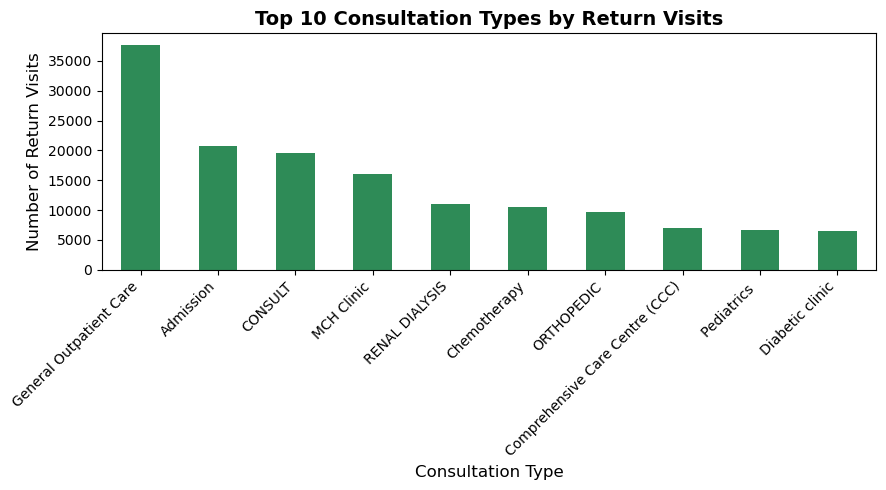

In [76]:
# Visualize the top 10 consultation types by return visits
plt.figure(figsize=(9, 5))

top_return[True].plot(kind="bar", color="seagreen")

plt.title("Top 10 Consultation Types by Return Visits", fontsize=14, fontweight="bold")
plt.xlabel("Consultation Type", fontsize=12)
plt.ylabel("Number of Return Visits", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.show()

*Observation:* General Outpatient Care has the highest number of return visits, followed by Admission and CONSULT. This suggests that patients receiving these services are more likely to return for further care.

In [77]:
# Calculate return rate by gender
gender_return_rate = pd.crosstab(
    df["Gender"],
    df["ReturnVisit"],
    normalize="index"
) * 100

gender_return_rate

ReturnVisit,False,True
Gender,,
FEMALE,27.631293,72.368707
MALE,28.410257,71.589743


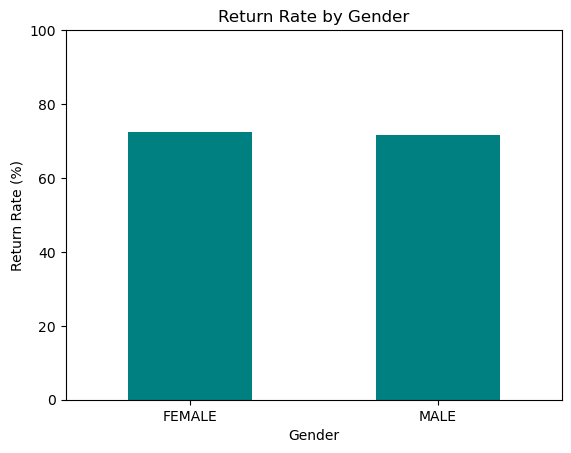

In [78]:
# Visualize return rates by gender
gender_return_rate[True].plot(kind="bar", color = 'teal')

plt.title("Return Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Return Rate (%)")
plt.xticks(rotation=0)
plt.ylim(0, 100)
plt.show()

*Observation:* Female patients have a slightly higher return rate than male patients, but the difference is small. This suggests that gender may not have a strong effect on whether patients return.

In [79]:
# Calculate the total number of patients for each consultation type
consult_total = df["ConsultDescription"].value_counts()

# Keep consultation types with at least 100 patients
common_consults = consult_total[consult_total >= 100].index

# Calculate return rate for each consultation type
consult_return_rate = pd.crosstab(
    df["ConsultDescription"],
    df["ReturnVisit"],
    normalize="index"
) * 100

# Calculate return rate for the more common consultation types
consult_return_rate_filtered = consult_return_rate.loc[common_consults]

# Show the 10 consultation types with the highest return rates
consult_return_rate_filtered.sort_values(
    by=True, ascending=False)

ReturnVisit,False,True
ConsultDescription,,
RENAL DIALYSIS,0.499319,99.500681
Program Patients,0.784077,99.215923
Chemotherapy,2.755102,97.244898
SPECIALITY IMED,2.857143,97.142857
Renal Clinic,3.968254,96.031746
Physiotherapy,4.108496,95.891504
Psychiatry,5.015674,94.984326
Gen Surg OPD,5.177112,94.822888
Spine Clinic,5.853659,94.146341


In [80]:
# Remove consultation types that explicitly describe a return/revisit
consult_return_rate_clean = consult_return_rate_filtered[
    ~consult_return_rate_filtered.index.str.contains(
        "return|revisit", case=False, na=False
    )
]

# Get the 10 consultation types with the highest return rates
top_return_rate = consult_return_rate_clean.sort_values(
    by=True, ascending=False
).head(10)

top_return_rate

ReturnVisit,False,True
ConsultDescription,,
RENAL DIALYSIS,0.499319,99.500681
Program Patients,0.784077,99.215923
Chemotherapy,2.755102,97.244898
SPECIALITY IMED,2.857143,97.142857
Renal Clinic,3.968254,96.031746
Physiotherapy,4.108496,95.891504
Psychiatry,5.015674,94.984326
Gen Surg OPD,5.177112,94.822888
Spine Clinic,5.853659,94.146341


In [81]:
print("consult_return_rate_filtered" in globals())

True


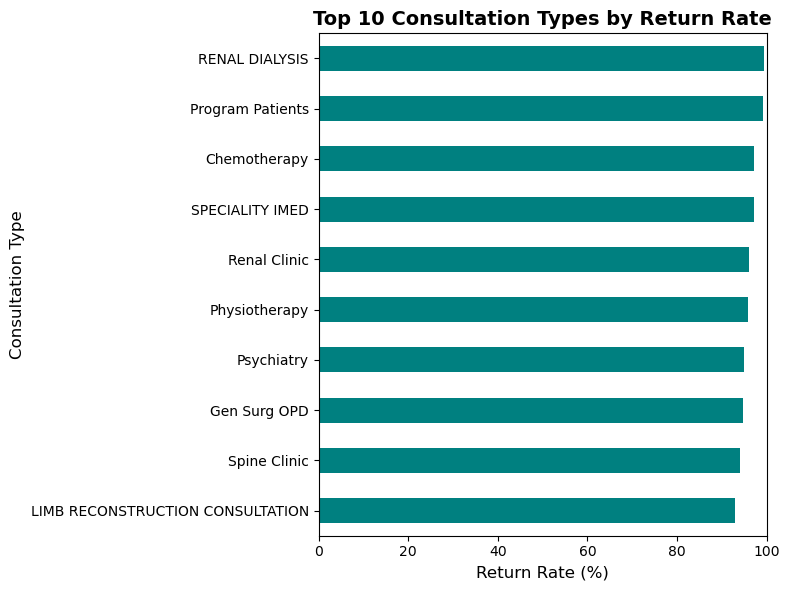

In [82]:
# Visualize top 10 consultation types by return rate

plt.figure(figsize=(8, 6))

top_return_rate[True].sort_values().plot(kind="barh",color="teal")
plt.title("Top 10 Consultation Types by Return Rate", fontsize=14, fontweight="bold")

plt.xlabel("Return Rate (%)", fontsize=12)
plt.ylabel("Consultation Type", fontsize=12)
plt.xlim(0, 100)
plt.tight_layout()
plt.show()

*Observation:* Renal Dialysis has the highest return rate at about 99.5%, followed by Program Patients at about 99.2%. The other consultation types also have high return rates, all above 92%. This shows that patients receiving these services are highly likely to return for further care.

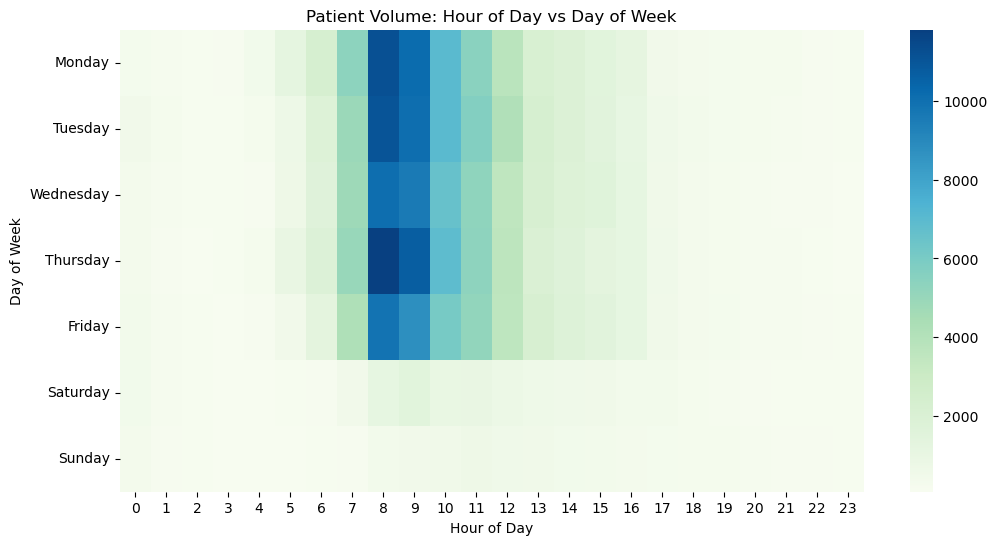

In [83]:
# HR OF DAY & DAY OF WEEK - VIVIST COUNT
df["hour"] = df["RegistrationDate"].dt.hour
df["day_of_week"] = df["RegistrationDate"].dt.day_name()

order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
hour_day = df.groupby(["day_of_week","hour"]).size().unstack().reindex(order)
hour_day.columns = hour_day.columns.astype(int)

plt.figure(figsize=(12,6))
sns.heatmap(hour_day, cmap="GnBu")
plt.title("Patient Volume: Hour of Day vs Day of Week")
plt.xlabel("Hour of Day")
plt.ylabel("Day of Week")
plt.show()

### Feature Engineering for Demand Forecasting

Everything so far has been patient-level (one row per visit). To predict congestion,
we need department-hour level data instead: "how many patients showed up in this
department, in this hour." This section builds that, following the approach used
in the OPD Congestion  Model Selection & Feature Engineering reference notebook.

In [84]:
# Group the ~79 raw consultation labels into 7 broader categories
df["ConsultClean"] = (
    df["ConsultDescription"]
    .fillna("UNKNOWN")
    .str.strip()
    .str.upper()
    .str.replace(r"\.$", "", regex=True)
    .str.replace(r"\s+", " ", regex=True)
)

service_map = {}
for label in ["GENERAL OUTPATIENT CARE", "CONSULT", "GENERAL OUTPATIENT CARE( NEW )",
              "REVISIT", "UNKNOWN", "CONSULTANT CLINIC"]:
    service_map[label] = "Admin / Unspecified"
for label in ["ADMISSION", "DAYCASE", "EMERGENCY"]:
    service_map[label] = "Inpatient / Emergency"
for label in ["RENAL DIALYSIS", "CHEMOTHERAPY", "PHYSIOTHERAPY",
              "HEPATITIS B VACCINE", "OCCUPATIONAL THERAPY"]:
    service_map[label] = "Procedure / Treatment"
for label in ["TELEMEDICINE", "STAFF CLINIC", "STAFF WELLNESS PACKAGE",
              "GENERAL WELLNESS PACKAGE", "PROGRAM PATIENTS", "RVA"]:
    service_map[label] = "Non-Physical / Special Cohort"
for label in ["ECHO", "CANCER SCREENING", "CSSR CANCER SCREENING", "EAR SCREENING"]:
    service_map[label] = "Diagnostic / Screening"
for label in ["MCH CLINIC", "MCH (NEW PATIENT)", "CHILD WELFARE AND IMMUNIZATION (CWC)",
              "DEVELOPMENTAL CLINIC", "FAMILY PLANNING", "ANC REVISIT",
              "ANC FIRST VISIT", "POSTNATAL (PNC)"]:
    service_map[label] = "Maternal & Child Health"

specialty = [
    "ORTHOPEDIC", "COMPREHENSIVE CARE CENTRE (CCC)", "PEDIATRICS", "DENTAL CARE",
    "DIABETIC CLINIC", "GENERAL SURGERY", "GEN SURG OPD", "SURGICAL OPD",
    "ENT RETURN VISIT", "ENT FIRST VISIT", "UROLOGY", "GYNAECOLOGY", "GYNE ONCOLOGY",
    "GYN-ONCOLOGY", "PRIVATE GYN ONCOLOGY", "CARDIOLOGY", "OPHTHALMOLOGY", "EYE CLINIC",
    "ONCOLOGY CONSULTATION", "ONCOLOGY SERVICE", "PLASTICS", "BREAST",
    "NEUROSURGERY OUTPATIENT CLINIC", "ADULT NEUROLOGY", "PAEDS NEUROLOGY",
    "PSYCHIATRY", "PAEDIATRIC PSYCHIATRY", "COUNSELLING PSYCHOLOGY",
    "CLINICAL PSYCHOLOGY CONSULTATION", "COUNSELLING", "NUTRITION CONSULT",
    "SPINE CLINIC", "LIMB RECONSTRUCTION CONSULTATION", "RENAL CLINIC",
    "RENAL CONSULTATION", "NEPHROLOGY CLINIC", "DERMATOLOGY CONSULTATION",
    "ANAESTHESIA CONSULT", "PALLIATIVE REVISIT", "LUNG CLINIC", "HAND CLINIC",
    "TB CLINIC", "HYPERTENSION CLINIC", "PAIN CLINIC", "HEAD AND NECK VISIT",
    "HEAD & NECK RETURN VISIT", "PEADS SURGE", "SPECIALITY IMED",
]
for label in specialty:
    service_map[label] = "Specialty Clinic"

df["ServiceGroup"] = df["ConsultClean"].map(service_map).fillna("Other / Unmapped")
df["ServiceGroup"].value_counts()

ServiceGroup
Admin / Unspecified              105234
Specialty Clinic                  86911
Inpatient / Emergency             34525
Maternal & Child Health           28982
Procedure / Treatment             25719
Non-Physical / Special Cohort      6333
Diagnostic / Screening              566
Name: count, dtype: int64

**Observation**

All consult labels matched the mapping - 0 fell into "Other / Unmapped". Admin/Unspecified
(105,234) and Specialty Clinic (86,911) are the two largest groups, followed by
Inpatient/Emergency, Maternal & Child Health, Procedure/Treatment, Non-Physical/Special
Cohort, and a small Diagnostic/Screening group (566).

### Lab-need features

Each Specialty Clinic label is assigned a likelihood of sending the patient to the lab
(Always/Often/Rarely/Never), plus a typical turnaround time. This matters for congestion
because a patient waiting on same-day lab results occupies space in the building longer
than one who doesn't.

In [85]:
lab_always = ["DIABETIC CLINIC", "COMPREHENSIVE CARE CENTRE (CCC)", "RENAL CLINIC",
    "RENAL CONSULTATION", "NEPHROLOGY CLINIC", "TB CLINIC", "HYPERTENSION CLINIC",
    "ONCOLOGY CONSULTATION", "ONCOLOGY SERVICE", "GYNE ONCOLOGY", "GYN-ONCOLOGY",
    "PRIVATE GYN ONCOLOGY", "BREAST"]
lab_often = ["GENERAL SURGERY", "GEN SURG OPD", "SURGICAL OPD", "ANAESTHESIA CONSULT",
    "CARDIOLOGY", "UROLOGY", "GYNAECOLOGY", "PEDIATRICS", "PEADS SURGE",
    "ADULT NEUROLOGY", "PAEDS NEUROLOGY", "NEUROSURGERY OUTPATIENT CLINIC",
    "LUNG CLINIC", "SPECIALITY IMED", "PALLIATIVE REVISIT"]
lab_rarely = ["ORTHOPEDIC", "SPINE CLINIC", "LIMB RECONSTRUCTION CONSULTATION",
    "HAND CLINIC", "PLASTICS", "DERMATOLOGY CONSULTATION", "OPHTHALMOLOGY",
    "EYE CLINIC", "ENT FIRST VISIT", "ENT RETURN VISIT", "HEAD AND NECK VISIT",
    "HEAD & NECK RETURN VISIT", "PAIN CLINIC", "NUTRITION CONSULT"]
lab_never = ["DENTAL CARE", "PSYCHIATRY", "PAEDIATRIC PSYCHIATRY",
    "COUNSELLING PSYCHOLOGY", "CLINICAL PSYCHOLOGY CONSULTATION", "COUNSELLING"]

lab_map = {}
for x in lab_always: lab_map[x] = "Always"
for x in lab_often:  lab_map[x] = "Often"
for x in lab_rarely: lab_map[x] = "Rarely"
for x in lab_never:  lab_map[x] = "Never"

df["LabNeed"] = df["ConsultClean"].map(lab_map).fillna("Never")
lab_minutes = {"Always": 120, "Often": 120, "Rarely": 90, "Never": 0}
df["LabTatMins"] = df["LabNeed"].map(lab_minutes)
df["LabSameDay"] = df["LabNeed"].isin(["Always", "Often", "Rarely"])

df["LabNeed"].value_counts()

LabNeed
Never     210753
Often      29591
Rarely     27069
Always     20857
Name: count, dtype: int64

**Observation**

Never: 210,753, Often: 29,591, Rarely: 27,069, Always: 20,857 - about 27% of visits
(`LabSameDay`) are estimated to involve a same-day lab step. Note the assumption: anything
not explicitly in the mapping (including "Other / Unmapped" service types) defaults to
"Never" rather than being treated as unknown.

### Calendar features

- `hour` - hour of day (0-23), since OPD traffic isn't evenly spread through the day.
- `day_of_week` - Monday=0 ... Sunday=6, since MCH clinics run on fixed weekdays.
- `is_weekend` - weekends likely behave differently.
- `month` - to capture any seasonal dip/spike.

In [86]:
df["date"] = df["RegistrationDate"].dt.date
df["hour"] = df["RegistrationDate"].dt.hour
df["day_of_week"] = df["RegistrationDate"].dt.dayofweek   # Monday=0 ... Sunday=6
df["is_weekend"] = df["day_of_week"] >= 5
df["month"] = df["RegistrationDate"].dt.month

df[["date", "hour", "day_of_week", "is_weekend", "month"]].sample(5)

,date,hour,day_of_week,is_weekend,month
66135,2024-12-18,13,2,False,12
56750,2024-11-19,10,1,False,11
270207,2026-07-06,8,0,False,7
211634,2026-02-04,8,2,False,2
85911,2025-02-19,9,2,False,2


**Observation**

Data spans 1 June 2024 to 19 August 2026, with all 12 months represented - a good spread
for catching seasonal patterns. `AgeGroup` from earlier in the notebook is left as-is; no
need to rebuild it here.

### Build the modeling table: hourly arrivals per department

This is the key step. So far every row is one visit - there's no "congestion" number yet.
Grouping by date, hour, and department turns each visit into a count: "this many patients
showed up in this department, in this hour." That count becomes what the model predicts.

In [87]:
# Drop rows with an unparseable timestamp - can't place them in a specific hour
ts_df = df.dropna(subset=["RegistrationDate"]).copy()

hourly = (
    ts_df.groupby(["date", "hour", "QueuedTo"])
    .size()
    .reset_index(name="visit_count")
)

hourly["date"] = pd.to_datetime(hourly["date"])
hourly["day_of_week"] = hourly["date"].dt.dayofweek
hourly["is_weekend"] = hourly["day_of_week"] >= 5
hourly["month"] = hourly["date"].dt.month

hourly.head()

,date,hour,QueuedTo,visit_count,day_of_week,is_weekend,month
0,2024-06-01,0,ADMISSION,1,5,True,6
1,2024-06-01,0,GENERAL OPD,2,5,True,6
2,2024-06-01,1,CASUALTY,1,5,True,6
3,2024-06-01,1,GENERAL OPD,2,5,True,6
4,2024-06-01,2,GENERAL OPD,2,5,True,6


In [88]:
hourly["hour"].value_counts()

hour
8     8941
9     8904
10    8018
11    7537
7     6388
12    6370
13    4882
14    4365
6     3837
15    3805
16    3108
5     2430
17    1905
18    1522
0     1414
19    1301
20    1174
4     1134
21    1035
1      995
22     880
2      747
23     709
3      688
Name: count, dtype: int64

**Observation**

82,089 department-hour rows across 41 departments. Typical hour has 1-4 visits (median 2),
busiest single hour hit 59 visits in one department.

### Bonus feature: return-visit share per hour

This notebook already built a `ReturnVisit` flag at the patient level - the reference
notebook doesn't have this. Folding it into the hourly table adds a feature unique to this
project: what share of each hour's patients were returning patients.

In [89]:
return_share = (
    ts_df.groupby(["date", "hour", "QueuedTo"])["ReturnVisit"]
    .mean()
    .reset_index(name="return_visit_share")
)
return_share["date"] = pd.to_datetime(return_share["date"])

hourly = hourly.merge(return_share, on=["date", "hour", "QueuedTo"], how="left")
hourly.head()

,date,hour,QueuedTo,visit_count,day_of_week,is_weekend,month,return_visit_share
0,2024-06-01,0,ADMISSION,1,5,True,6,0.0
1,2024-06-01,0,GENERAL OPD,2,5,True,6,0.0
2,2024-06-01,1,CASUALTY,1,5,True,6,0.0
3,2024-06-01,1,GENERAL OPD,2,5,True,6,0.0
4,2024-06-01,2,GENERAL OPD,2,5,True,6,0.0


**Observation**

Averages 0.72 across all department-hours. For the Renal department specifically it's
0.996 - almost exactly matching the ~99.5% return rate found in the earlier EDA, which is
a good sign this feature captures something real.

### Lag features

The strongest signal for "how busy is a department right now" is usually "how busy was it
a moment ago." Both features below are shifted so the model never sees the value it's
trying to predict.

# hourly = hourly.sort_values(["QueuedTo", "date", "hour"]).reset_index(drop=True)

hourly["lag_1h"] = hourly.groupby("QueuedTo")["visit_count"].shift(1)
hourly["rolling_3h_avg"] = (
    hourly.groupby("QueuedTo")["visit_count"]
    .transform(lambda s: s.shift(1).rolling(3).mean())
)

# the first couple of hours per department have no history yet - drop them
model_df = hourly.dropna(subset=["lag_1h", "rolling_3h_avg"]).copy()
model_df.head()

**Observation**

Only 121 rows (0.15%) dropped for missing lag history - about 3 rows per department,
right in the expected range.

# Modeling

### Seasonal Naive 

Seasonal Naive Baseline
A Seasonal Naive forecasting model is used as a simple baseline for predicting hospital patient demand. Rather than learning complex relationships from the data, the model assumes that demand at a particular time will be similar to demand at the same time during the previous seasonal period.

For this project, a 7 day seasonal period is appropriate because hospital registrations show a strong weekly pattern, with substantially different demand levels across weekdays and weekends. Therefore, the expected demand for a department at a particular hour can be compared with the demand for the same department and hour one week earlier.

The Seasonal Naive model serves as a benchmark against which more complex forecasting models such as LightGBM can be evaluated. If LightGBM performs better than this simple weekly baseline, its additional complexity provides measurable predictive value.

### Hourly predictions

#### Seaonal naive hourly pred

In [92]:
# a copy for modeling
seasonal_df = modl_df.copy() # for the error here first run the lgbm hrly pred cell [100]

# data is sorted correctly
seasonal_df = seasonal_df.sort_values(["QueuedTo", "timestamp"]).reset_index(drop=True)

# timestamp for the same hour one week earlier
seasonal_df["previous_week_timestamp"] = (seasonal_df["timestamp"] - pd.Timedelta(days=7))

In [93]:
seasonal_df.shape

(797040, 9)

In [94]:
# Create timestamp for the corresponding hour one week earlier
seasonal_df["previous_week_timestamp"] = (seasonal_df["timestamp"] - pd.Timedelta(days=7))

# lookup table for previous week's demand
previous_week = modl_df[["QueuedTo", "timestamp", "visit_count"]].copy()

previous_week = previous_week.rename(columns={"timestamp": "previous_week_timestamp","visit_count": "seasonal_naive"})

# previous week's is merged demand onto the current observation
seasonal_df = seasonal_df.merge(previous_week,on=["QueuedTo", "previous_week_timestamp"],how="left")

In [95]:
# the chronological test period
cutoff = seasonal_df["date"].quantile(0.8)


# train
seasonal_train = seasonal_df[seasonal_df["date"] < cutoff].copy()
# test
seasonal_test = seasonal_df[seasonal_df["date"] >= cutoff].copy()

In [96]:
seasonal_df.head(10)

,timestamp,QueuedTo,visit_count,date,hour,day_of_week,is_weekend,month,previous_week_timestamp,seasonal_naive
0,2024-06-01 00:00:00,ADMISSION,1.0,2024-06-01,0,5,True,6,2024-05-25 00:00:00,NaN
1,2024-06-01 01:00:00,ADMISSION,0.0,2024-06-01,1,5,True,6,2024-05-25 01:00:00,NaN
2,2024-06-01 02:00:00,ADMISSION,0.0,2024-06-01,2,5,True,6,2024-05-25 02:00:00,NaN
3,2024-06-01 03:00:00,ADMISSION,0.0,2024-06-01,3,5,True,6,2024-05-25 03:00:00,NaN
4,2024-06-01 04:00:00,ADMISSION,0.0,2024-06-01,4,5,True,6,2024-05-25 04:00:00,NaN
5,2024-06-01 05:00:00,ADMISSION,0.0,2024-06-01,5,5,True,6,2024-05-25 05:00:00,NaN
6,2024-06-01 06:00:00,ADMISSION,0.0,2024-06-01,6,5,True,6,2024-05-25 06:00:00,NaN
7,2024-06-01 07:00:00,ADMISSION,0.0,2024-06-01,7,5,True,6,2024-05-25 07:00:00,NaN
8,2024-06-01 08:00:00,ADMISSION,0.0,2024-06-01,8,5,True,6,2024-05-25 08:00:00,NaN
9,2024-06-01 09:00:00,ADMISSION,1.0,2024-06-01,9,5,True,6,2024-05-25 09:00:00,NaN


In [97]:
# Select 'queuedto' and 'consultdescription' columns
modl_df = df[["hour", "QueuedTo"]]

# Display the first few rows of the subset
modl_df.head()
combination_counts = df[["hour", "QueuedTo"]].value_counts().reset_index(name="count")
display(combination_counts.head(15))

,hour,QueuedTo,count
0,9,GENERAL OPD,13725
1,8,GENERAL OPD,12495
2,10,GENERAL OPD,10090
3,11,GENERAL OPD,8787
4,7,GENERAL OPD,7732
5,12,GENERAL OPD,6515
6,8,SPECIALITY CLINIC,5770
7,9,CHRONIC CARE CLINIC (DM/HTN/TB/CCC),5374
8,9,MCH,5212
9,8,ONCOLOGY,5134


In [98]:
combination_counts = modl_df[["hour", "QueuedTo"]].value_counts().reset_index(name="count")
display(combination_counts.head(15))

,hour,QueuedTo,count
0,9,GENERAL OPD,13725
1,8,GENERAL OPD,12495
2,10,GENERAL OPD,10090
3,11,GENERAL OPD,8787
4,7,GENERAL OPD,7732
5,12,GENERAL OPD,6515
6,8,SPECIALITY CLINIC,5770
7,9,CHRONIC CARE CLINIC (DM/HTN/TB/CCC),5374
8,9,MCH,5212
9,8,ONCOLOGY,5134


In [99]:
# 1. Filter specifically for 'GENERAL OPD' (adjust string if your department name differs slightly)
gen_opd_df = df[df["QueuedTo"] == "GENERAL OPD"]

# 2. Filter for hours between 18:00 (6 PM) and 07:00 (7 AM)
# This includes 18 through 23, and 0 through 6
night_visits = gen_opd_df[
    (gen_opd_df["hour"] >= 18) | (gen_opd_df["hour"] < 7)
]

# 3. Get the total count of patients
total_night_patients = len(night_visits)
print(f"Total General OPD patients visiting between 18:00 and 07:00: {total_night_patients:,}")

# Optional: View a breakdown by exact hour to see the distribution
hourly_breakdown = night_visits["hour"].value_counts().sort_index()
print("\nVisits breakdown by hour:")
print(hourly_breakdown)

Total General OPD patients visiting between 18:00 and 07:00: 0

Visits breakdown by hour:
Series([], Name: count, dtype: int64)


In [100]:
# calculate the mar and rmse

evaluation = seasonal_test.dropna(subset=["seasonal_naive"]).copy()

baseline_mae = mean_absolute_error(evaluation["visit_count"], evaluation["seasonal_naive"])

baseline_rmse = np.sqrt(mean_squared_error(evaluation["visit_count"], evaluation["seasonal_naive"]))

print(f"Seasonal Naive MAE: {baseline_mae:.2f}")
print(f"Seasonal Naive RMSE: {baseline_rmse:.2f}")
print(f"Test observations: {len(evaluation):,}")
print(f"Test period: "f"{evaluation['timestamp'].min()} "f"to "f"{evaluation['timestamp'].max()}")

Seasonal Naive MAE: 0.30
Seasonal Naive RMSE: 1.16
Test observations: 159,408
Test period: 2026-03-11 00:00:00 to 2026-08-19 23:00:00


In [101]:
# R2 score - Seasonal Naive (hourly)

seasonal_naive_r2 = r2_score(evaluation["visit_count"], evaluation["seasonal_naive"])

print(f"Seasonal Naive R2: {seasonal_naive_r2:.3f}")

Seasonal Naive R2: 0.576


**Observation:** The naive guess (same hour, one week ago) is off by only about 0.3 patients on average. R² shows how much of the hour-to-hour ups and downs this simple rule already explains.

In [102]:
# basrline summary
print("Test observations:", len(seasonal_test))
print("Departments:", seasonal_test["QueuedTo"].nunique())
print("Test period:", seasonal_test["date"].min(), "to", seasonal_test["date"].max())

Test observations: 159408
Departments: 41
Test period: 2026-03-11 00:00:00 to 2026-08-19 00:00:00


In [103]:
# department level performance
department_baseline = (seasonal_test.groupby("QueuedTo").apply(
    lambda x: pd.Series({"MAE": mean_absolute_error(x["visit_count"], x["seasonal_naive"]),
                         "RMSE": np.sqrt(mean_squared_error(x["visit_count"], 
                          x["seasonal_naive"])), "Actual_Avg_Demand": x["visit_count"].mean()
                           })).reset_index())

department_baseline.sort_values("Actual_Avg_Demand", ascending=False).head(10)

,QueuedTo,MAE,RMSE,Actual_Avg_Demand
12,GENERAL OPD,2.350566,3.949169,4.597737
0,ADMISSION,1.396091,2.376692,1.611368
17,MCH,1.076646,2.247770,1.550412
19,MEB SPECIALITY CLINIC,0.858796,2.353364,1.412294
5,CHRONIC CARE CLINIC (DM/HTN/TB/CCC),0.834105,2.070578,1.376286
39,SPECIALITY CLINIC,0.597479,1.627708,0.804270
27,ONCOLOGY,0.504372,1.703075,0.747685
37,RENAL,0.742027,2.022698,0.603652
7,DENTAL,0.467593,1.282600,0.528807
30,PAEDS BKKH,0.359311,1.107053,0.483025


### LightGBM hourly pred

In [104]:
# copy of the hourly demand data
modl_df = hourly.copy()

# date set to datetime
modl_df["date"] = pd.to_datetime(modl_df["date"])

# complete hourly timestamps
start_date = modl_df["date"].min()
end_date = modl_df["date"].max()

all_hours = pd.date_range(start=start_date, end=end_date + pd.Timedelta(hours=23), freq="h")

departments = modl_df["QueuedTo"].dropna().unique()

# combination of timestamp and department
complete_grid = pd.MultiIndex.from_product([all_hours, departments],names=["timestamp", "QueuedTo"]).to_frame(index=False)

# timestamp extraction from existing data
modl_df["timestamp"] = (modl_df["date"] + pd.to_timedelta(modl_df["hour"], unit="h"))

# keeping the required columns
modl_df = modl_df[["timestamp", "QueuedTo", "visit_count"]]

# merge onto the complete grid
modl_df = complete_grid.merge(modl_df, on=["timestamp", "QueuedTo"], how="left")

# hours with no recorded visits hence zero demand
modl_df["visit_count"] = modl_df["visit_count"].fillna(0)

# recreate time features
modl_df["date"] = modl_df["timestamp"].dt.date
modl_df["date"] = pd.to_datetime(modl_df["date"])

modl_df["hour"] = modl_df["timestamp"].dt.hour
modl_df["day_of_week"] = modl_df["timestamp"].dt.dayofweek
modl_df["is_weekend"] = modl_df["day_of_week"] >= 5
modl_df["month"] = modl_df["timestamp"].dt.month

# sorting for time series features
modl_df = modl_df.sort_values(["QueuedTo", "timestamp"]).reset_index(drop=True)

modl_df.head()

,timestamp,QueuedTo,visit_count,date,hour,day_of_week,is_weekend,month
0,2024-06-01 00:00:00,ADMISSION,1.0,2024-06-01,0,5,True,6
1,2024-06-01 01:00:00,ADMISSION,0.0,2024-06-01,1,5,True,6
2,2024-06-01 02:00:00,ADMISSION,0.0,2024-06-01,2,5,True,6
3,2024-06-01 03:00:00,ADMISSION,0.0,2024-06-01,3,5,True,6
4,2024-06-01 04:00:00,ADMISSION,0.0,2024-06-01,4,5,True,6


In [105]:
modl_df.shape

(797040, 8)

In [106]:
# lag features
# previous hour
modl_df["lag_1h"] = (modl_df.groupby("QueuedTo")["visit_count"].shift(1))

# previous 3 hour average
modl_df["rolling_3h_avg"] = (modl_df.groupby("QueuedTo")["visit_count"].transform(lambda s: s.shift(1).rolling(3).mean()))

modl_df.head()


,timestamp,QueuedTo,visit_count,date,hour,day_of_week,is_weekend,month,lag_1h,rolling_3h_avg
0,2024-06-01 00:00:00,ADMISSION,1.0,2024-06-01,0,5,True,6,NaN,NaN
1,2024-06-01 01:00:00,ADMISSION,0.0,2024-06-01,1,5,True,6,1.0,NaN
2,2024-06-01 02:00:00,ADMISSION,0.0,2024-06-01,2,5,True,6,0.0,NaN
3,2024-06-01 03:00:00,ADMISSION,0.0,2024-06-01,3,5,True,6,0.0,0.333333
4,2024-06-01 04:00:00,ADMISSION,0.0,2024-06-01,4,5,True,6,0.0,0.000000


In [107]:
# seasonal naive benchmark
# Date corresponding to the same hour one week earlier
modl_df["previous_week_timestamp"] = (modl_df["timestamp"] - pd.Timedelta(days=7))

previous_week = modl_df[
    ["timestamp", "QueuedTo", "visit_count"]].rename(
    columns={"timestamp": "previous_week_timestamp", "visit_count": "seasonal_naive"})

modl_df = modl_df.merge(previous_week, on=["previous_week_timestamp", "QueuedTo"], how="left")


In [108]:
# dropping rows with insufficient history
model_df = modl_df.dropna(subset=["lag_1h", "rolling_3h_avg"]).copy()

print("Rows available for modeling:", len(model_df))
print("Departments:", model_df["QueuedTo"].nunique())
print("Date range:", model_df["date"].min(), "to", model_df["date"].max())

Rows available for modeling: 796917
Departments: 41
Date range: 2024-06-01 00:00:00 to 2026-08-19 00:00:00


In [109]:
# chronological train - test split
cutoff = model_df["date"].quantile(0.8)

train = model_df[model_df["date"] < cutoff].copy()

test = model_df[model_df["date"] >= cutoff].copy()

print("Training period:", train["date"].min(), "to", train["date"].max())
print("Testing period:", test["date"].min(), "to", test["date"].max())

print("\nTraining rows:", len(train))
print("Testing rows:", len(test))

Training period: 2024-06-01 00:00:00 to 2026-03-10 00:00:00
Testing period: 2026-03-11 00:00:00 to 2026-08-19 00:00:00

Training rows: 637509
Testing rows: 159408


In [110]:
# lgbm features
features = ["hour", "day_of_week", "is_weekend", "month", "lag_1h", "rolling_3h_avg", "QueuedTo"]

target = "visit_count"

X_train = train[features].copy()
y_train = train[target].copy()

X_test = test[features].copy()
y_test = test[target].copy()

In [111]:
# converting department to categorical
X_train["QueuedTo"] = X_train["QueuedTo"].astype("category")

X_test["QueuedTo"] = X_test["QueuedTo"].astype(pd.CategoricalDtype(categories=X_train["QueuedTo"].cat.categories))

In [112]:
model = lgb.LGBMRegressor(objective="regression", n_estimators=500, learning_rate=0.05, num_leaves=31, random_state=42)

model.fit(X_train, y_train, categorical_feature=["QueuedTo"])

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.008860 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 205
[LightGBM] [Info] Number of data points in the train set: 637509, number of used features: 7
[LightGBM] [Info] Start training from score 0.353772


,learning_rate,0.05
,n_estimators,500
,objective,'regression'
,random_state,42
,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,subsample_for_bin,200000
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001


In [113]:
# prediction generation
predictions = model.predict(X_test)

predictions = np.maximum(predictions, 0)

predictions[:10]

array([2.09284767, 1.12526051, 0.75101751, 0.50703489, 0.50527669,
       0.5192248 , 0.6669268 , 1.22188979, 3.00271276, 4.79312985])

In [114]:
# model evalutaion
lgbm_mae = mean_absolute_error(y_test, predictions)

lgbm_rmse = np.sqrt(mean_squared_error(y_test, predictions))

print(f"LightGBM MAE:  {lgbm_mae:.2f}")
print(f"LightGBM RMSE: {lgbm_rmse:.2f}")

LightGBM MAE:  0.24
LightGBM RMSE: 0.86


In [115]:
# R2 score - LightGBM (hourly)

lgbm_r2 = r2_score(y_test, predictions)

print(f"LightGBM R2: {lgbm_r2:.3f}")

LightGBM R2: 0.770


**Observation:** LightGBM cuts the average error to about 0.24 patients per hour, beating the naive baseline. R² shows how much more of the variation it captures.

In [116]:
# lgbm - seasonal naive comparsion
evaluation = test[["timestamp", "QueuedTo", "visit_count", "seasonal_naive"]].copy()

evaluation["lightgbm_prediction"] = predictions

evaluation = evaluation.dropna(subset=["seasonal_naive"]).reset_index(drop=True)

evaluation.head()

,timestamp,QueuedTo,visit_count,seasonal_naive,lightgbm_prediction
0,2026-03-11 00:00:00,ADMISSION,3.0,2.0,2.092848
1,2026-03-11 01:00:00,ADMISSION,2.0,1.0,1.125261
2,2026-03-11 02:00:00,ADMISSION,0.0,1.0,0.751018
3,2026-03-11 03:00:00,ADMISSION,0.0,0.0,0.507035
4,2026-03-11 04:00:00,ADMISSION,0.0,0.0,0.505277


In [117]:
evaluation = test[["timestamp", "QueuedTo", "visit_count", "seasonal_naive"]].copy()

evaluation["lightgbm_prediction"] = predictions

evaluation = evaluation.dropna(subset=["seasonal_naive"])

baseline_mae = mean_absolute_error(evaluation["visit_count"], evaluation["seasonal_naive"])

baseline_rmse = np.sqrt(mean_squared_error(evaluation["visit_count"], evaluation["seasonal_naive"]))

lgbm_mae_eval = mean_absolute_error(evaluation["visit_count"], evaluation["lightgbm_prediction"])

lgbm_rmse_eval = np.sqrt(mean_squared_error(evaluation["visit_count"], evaluation["lightgbm_prediction"]))

print("Seasonal Naive")
print(f"MAE:  {baseline_mae:.2f}")
print(f"RMSE: {baseline_rmse:.2f}")

print("\nLightGBM")
print(f"MAE:  {lgbm_mae_eval:.2f}")
print(f"RMSE: {lgbm_rmse_eval:.2f}")

Seasonal Naive
MAE:  0.30
RMSE: 1.16

LightGBM
MAE:  0.24
RMSE: 0.86


In [118]:
# R2 score - Seasonal Naive vs LightGBM (hourly)

baseline_r2 = r2_score(evaluation["visit_count"], evaluation["seasonal_naive"])

lgbm_r2_eval = r2_score(evaluation["visit_count"], evaluation["lightgbm_prediction"])

print("Seasonal Naive")
print(f"R2: {baseline_r2:.3f}")

print("\nLightGBM")
print(f"R2: {lgbm_r2_eval:.3f}")

Seasonal Naive
R2: 0.576

LightGBM
R2: 0.770


**Observation:** Side by side, LightGBM beats the naive baseline on every metric at the hourly level - R² confirms it explains more of the demand pattern, not just a lower average error.

In [119]:
# percentage improvement
mae_improvement = ((baseline_mae - lgbm_mae_eval) / baseline_mae) * 100

rmse_improvement = ((baseline_rmse - lgbm_rmse_eval) / baseline_rmse) * 100

print(f"MAE improvement:  {mae_improvement:.2f}%")
print(f"RMSE improvement: {rmse_improvement:.2f}%")

MAE improvement:  18.43%
RMSE improvement: 26.38%


In [120]:
# department level performance
department_results = []

for department, group in evaluation.groupby("QueuedTo"):

    actual = group["visit_count"]
    predicted = group["lightgbm_prediction"]
    baseline = group["seasonal_naive"]

    department_results.append({"Department": department, "Observations": len(group), 
    "Average Demand": actual.mean(),"LightGBM MAE": mean_absolute_error(actual, predicted),
    "Seasonal Naive MAE": mean_absolute_error(actual, baseline)})

department_results = pd.DataFrame(department_results)

department_results["Improvement (%)"] = ((department_results["Seasonal Naive MAE"]
                                          - department_results["LightGBM MAE"]) 
                                         / department_results["Seasonal Naive MAE"]) * 100

department_results = department_results.sort_values("Average Demand", ascending=False)

department_results.head(15)

,Department,Observations,Average Demand,LightGBM MAE,Seasonal Naive MAE,Improvement (%)
12,GENERAL OPD,3888,4.597737,1.757425,2.350566,25.233939
0,ADMISSION,3888,1.611368,1.079742,1.396091,22.659630
17,MCH,3888,1.550412,0.796930,1.076646,25.980298
19,MEB SPECIALITY CLINIC,3888,1.412294,0.613346,0.858796,28.580737
5,CHRONIC CARE CLINIC (DM/HTN/TB/CCC),3888,1.376286,0.625145,0.834105,25.052025
39,SPECIALITY CLINIC,3888,0.804270,0.569980,0.597479,4.602581
27,ONCOLOGY,3888,0.747685,0.467160,0.504372,7.377998
37,RENAL,3888,0.603652,0.695345,0.742027,6.291081
7,DENTAL,3888,0.528807,0.380450,0.467593,18.636463
30,PAEDS BKKH,3888,0.483025,0.338678,0.359311,5.742237


In [121]:
# feature importance
feature_importance = pd.DataFrame({"Feature": features, "Importance": model.feature_importances_})

feature_importance = feature_importance.sort_values("Importance", ascending=False)

feature_importance

,Feature,Importance
5,rolling_3h_avg,3295
0,hour,2975
4,lag_1h,2857
6,QueuedTo,2111
1,day_of_week,1912
3,month,1850
2,is_weekend,0


#### Hourly forecast

In [122]:
print("Hourly dataframe:")
print(hourly.shape)
print(hourly.columns.tolist())

Hourly dataframe:
(82089, 8)
['date', 'hour', 'QueuedTo', 'visit_count', 'day_of_week', 'is_weekend', 'month', 'return_visit_share']


In [123]:
print("\nDepartments:")
print(hourly["QueuedTo"].nunique())


Departments:
41


In [124]:
print("\nLast date:")
print(hourly["date"].max())


Last date:
2026-08-19 00:00:00


In [125]:
print("\nHourly model features:")
print(X_train.columns.tolist())


Hourly model features:
['hour', 'day_of_week', 'is_weekend', 'month', 'lag_1h', 'rolling_3h_avg', 'QueuedTo']


In [126]:
# Hourly forecast model - setup
# forecast horizon
forecast_days = 7

# last date available in the historical hourly dataset
last_date = hourly["date"].max()

# future hourly timestamps
future_dates = pd.date_range(start=last_date + pd.Timedelta(hours=1), periods=forecast_days * 24, freq="h")

# department categories used by the trained model
queuedto_categories = model.booster_.pandas_categorical[0]

# Historical data used to initialize recursive features
history = hourly[
    ["date", "hour", "QueuedTo", "visit_count"]
].copy()

# Ensure correct data types
history["date"] = pd.to_datetime(history["date"])

# Store forecasts here
future_forecasts = []

In [127]:
# Recursive forecasting
# each hour's prediction is added back into history so the next
# hour's lag/rolling features can use it

for timestamp in future_dates:

    current_date = timestamp.normalize()
    current_hour = timestamp.hour
    day_of_week = timestamp.dayofweek
    month = timestamp.month
    is_weekend = int(day_of_week >= 5)

    for department in queuedto_categories:

        # Previous hour's actual/predicted demand
        previous_hour = history[
            (history["QueuedTo"] == department) &
            (history["date"] == timestamp - pd.Timedelta(hours=1))
        ]

        if len(previous_hour) > 0:
            lag_1h = previous_hour["visit_count"].iloc[-1]
        else:
            lag_1h = 0

        # Previous 3 hours for rolling mean
        previous_3h = history[
            (history["QueuedTo"] == department) &
            (history["date"] < timestamp) &
            (history["date"] >= timestamp - pd.Timedelta(hours=3))
        ].sort_values("date")

        if len(previous_3h) > 0:
            rolling_3h_avg = previous_3h["visit_count"].mean()
        else:
            rolling_3h_avg = 0

        # Create model input
        X_future = pd.DataFrame({
            "hour": [current_hour],
            "day_of_week": [day_of_week],
            "is_weekend": [is_weekend],
            "month": [month],
            "lag_1h": [lag_1h],
            "rolling_3h_avg": [rolling_3h_avg],
            "QueuedTo": pd.Categorical(
                [department],
                categories=queuedto_categories
            )
        })

        # Predict
        prediction = model.predict(X_future)[0]

        # Demand cannot be negative
        prediction = max(0, prediction)

        # Save forecast
        future_forecasts.append({
            "date": timestamp,
            "hour": current_hour,
            "QueuedTo": department,
            "predicted_demand": prediction
        })

        # Add prediction to history so it can be used
        # as a lag/rolling value for subsequent hours
        history = pd.concat([
            history,
            pd.DataFrame({
                "date": [timestamp],
                "hour": [current_hour],
                "QueuedTo": [department],
                "visit_count": [prediction]
            })
        ], ignore_index=True)

In [128]:
# Collect the forecast into a dataframe
hourly_future_forecast = pd.DataFrame(future_forecasts)

# Sort output
hourly_future_forecast = hourly_future_forecast.sort_values(
    ["date", "QueuedTo", "hour"]
).reset_index(drop=True)

print("Hourly future forecast shape:")
print(hourly_future_forecast.shape)

print("\nForecast date range:")
print(
    hourly_future_forecast["date"].min(),
    "to",
    hourly_future_forecast["date"].max()
)

print("\nNumber of departments:")
print(hourly_future_forecast["QueuedTo"].nunique())

hourly_future_forecast.head(20)

Hourly future forecast shape:
(6888, 4)

Forecast date range:
2026-08-19 01:00:00 to 2026-08-26 00:00:00

Number of departments:
41


,date,hour,QueuedTo,predicted_demand
0,2026-08-19 01:00:00,1,ADMISSION,0.261545
1,2026-08-19 01:00:00,1,ANAESTHESIA,0.000489
2,2026-08-19 01:00:00,1,Audiology,0.006173
3,2026-08-19 01:00:00,1,CARDIOLOGY,0.000489
4,2026-08-19 01:00:00,1,CASUALTY,0.029474
5,2026-08-19 01:00:00,1,CHRONIC CARE CLINIC (DM/HTN/TB/CCC),1.768831
6,2026-08-19 01:00:00,1,DAYCASE,0.254450
7,2026-08-19 01:00:00,1,DENTAL,0.977934
8,2026-08-19 01:00:00,1,DIABETIC CLINIC,0.000489
9,2026-08-19 01:00:00,1,EYE CLINIC,0.295982


In [129]:
print("Minimum forecast timestamp:")
print(hourly_future_forecast["date"].min())

print("\nMaximum forecast timestamp:")
print(hourly_future_forecast["date"].max())

print("\nUnique timestamps:")
print(hourly_future_forecast["date"].nunique())

Minimum forecast timestamp:
2026-08-19 01:00:00

Maximum forecast timestamp:
2026-08-26 00:00:00

Unique timestamps:
168


In [130]:
department_counts = (
    hourly_future_forecast
    .groupby("date")["QueuedTo"]
    .nunique()
)

print(department_counts.value_counts())
print(department_counts.head())

QueuedTo
41    168
Name: count, dtype: int64
date
2026-08-19 01:00:00    41
2026-08-19 02:00:00    41
2026-08-19 03:00:00    41
2026-08-19 04:00:00    41
2026-08-19 05:00:00    41
Name: QueuedTo, dtype: int64


In [131]:
hospital_hourly_forecast = (
    hourly_future_forecast
    .groupby("date")["predicted_demand"]
    .sum()
    .reset_index()
)

hospital_hourly_forecast.head(24)

,date,predicted_demand
0,2026-08-19 01:00:00,30.054368
1,2026-08-19 02:00:00,28.254175
2,2026-08-19 03:00:00,29.728463
3,2026-08-19 04:00:00,28.216350
4,2026-08-19 05:00:00,32.713884
5,2026-08-19 06:00:00,44.899144
6,2026-08-19 07:00:00,73.302608
7,2026-08-19 08:00:00,119.309234
8,2026-08-19 09:00:00,104.037608
9,2026-08-19 10:00:00,68.610201


In [132]:
hourly_future_forecast.to_csv(
    "hourly_future_forecast.csv",
    index=False
)

print("Saved:", "hourly_future_forecast.csv")
print("Rows:", len(hourly_future_forecast))

Saved: hourly_future_forecast.csv
Rows: 6888


In [133]:
hourly_to_daily_check = (
    hourly_future_forecast
    .assign(date_only=hourly_future_forecast["date"].dt.date)
    .groupby(["date_only", "QueuedTo"])["predicted_demand"]
    .sum()
    .reset_index()
    .rename(columns={"date_only": "date"})
)

hourly_to_daily_check.head(20)

,date,QueuedTo,predicted_demand
0,2026-08-19,ADMISSION,33.948597
1,2026-08-19,ANAESTHESIA,4.199951
2,2026-08-19,Audiology,4.118691
3,2026-08-19,CARDIOLOGY,2.979412
4,2026-08-19,CASUALTY,5.449112
5,2026-08-19,CHRONIC CARE CLINIC (DM/HTN/TB/CCC),46.745076
6,2026-08-19,DAYCASE,12.246428
7,2026-08-19,DENTAL,24.649006
8,2026-08-19,DIABETIC CLINIC,2.979412
9,2026-08-19,EYE CLINIC,12.438379


In [134]:
# Hourly future forecast - coverage check
# Load saved forecast
hourly_future_forecast = pd.read_csv(
    "hourly_future_forecast.csv",
    parse_dates=["date"]
)

# Expected values
expected_departments = 41
expected_hours = 168
expected_rows = expected_departments * expected_hours

print("Expected rows:", expected_rows)
print("Actual rows:  ", len(hourly_future_forecast))

print("\nNumber of departments:")
print(hourly_future_forecast["QueuedTo"].nunique())

print("\nNumber of unique timestamps:")
print(hourly_future_forecast["date"].nunique())

print("\nForecast date range:")
print(hourly_future_forecast["date"].min())
print("to")
print(hourly_future_forecast["date"].max())

Expected rows: 6888
Actual rows:   6888

Number of departments:
41

Number of unique timestamps:
168

Forecast date range:
2026-08-19 01:00:00
to
2026-08-26 00:00:00


In [135]:
# Rows per department, and duplicate department-hour combinations
rows_per_department = (
    hourly_future_forecast
    .groupby("QueuedTo")
    .size()
)

print("Rows per department:")
print(rows_per_department)

# Check whether every department has exactly 168 rows
print("\nDepartments with incorrect number of rows:")
print(
    rows_per_department[
        rows_per_department != expected_hours
    ]
)

duplicates = hourly_future_forecast.duplicated(
    subset=["date", "QueuedTo"],
    keep=False
)

print("\nDuplicate department-hour combinations:")
print(duplicates.sum())

if duplicates.sum() > 0:
    print("\nDuplicates found:")
    print(
        hourly_future_forecast.loc[duplicates]
        .sort_values(["date", "QueuedTo"])
    )

Rows per department:
QueuedTo
ADMISSION                              168
ANAESTHESIA                            168
Audiology                              168
CARDIOLOGY                             168
CASUALTY                               168
CHRONIC CARE CLINIC (DM/HTN/TB/CCC)    168
DAYCASE                                168
DENTAL                                 168
DIABETIC CLINIC                        168
EYE CLINIC                             168
FAMILY CLINIC                          168
FAMILY MEDICINE                        168
GENERAL OPD                            168
Gen Surg OPD                           168
Gynae OPD                              168
HTS                                    168
MATERNITY NURSERY                      168
MCH                                    168
MEB PHYSIOTHERAPY                      168
MEB SPECIALITY CLINIC                  168
MENTAL HEALTH                          168
MORGUE                                 168
NEURO SURGERY CONSULTATI

In [136]:
# Check for missing department-hour combinations
expected_dates = pd.date_range(
    start=hourly_future_forecast["date"].min(),
    periods=expected_hours,
    freq="h"
)

expected_departments_list = (
    hourly_future_forecast["QueuedTo"]
    .unique()
)

expected_grid = pd.MultiIndex.from_product(
    [
        expected_dates,
        expected_departments_list
    ],
    names=["date", "QueuedTo"]
)

actual_grid = pd.MultiIndex.from_frame(
    hourly_future_forecast[
        ["date", "QueuedTo"]
    ]
)

missing = expected_grid.difference(actual_grid)

print("Missing department-hour combinations:")
print(len(missing))

if len(missing) > 0:
    print("\nMissing combinations:")
    print(missing)

Missing department-hour combinations:
0


In [137]:
# Final coverage verdict
coverage_ok = (
    len(hourly_future_forecast) == expected_rows
    and hourly_future_forecast["QueuedTo"].nunique() == expected_departments
    and hourly_future_forecast["date"].nunique() == expected_hours
    and duplicates.sum() == 0
    and len(missing) == 0
)

print("HOURLY COVERAGE CHECK")

if coverage_ok:
    print("PASS - Complete hourly forecast coverage.")
else:
    print("CHECK REQUIRED - Coverage is incomplete or duplicated.")

HOURLY COVERAGE CHECK
PASS - Complete hourly forecast coverage.


In [138]:
# Hourly future forecast - sanity check
# Missing or negative predictions, and basic statistics
print("Missing predictions:")
print(hourly_future_forecast["predicted_demand"].isna().sum())

print("\nNegative predictions:")
print((hourly_future_forecast["predicted_demand"] < 0).sum())

print("\nPrediction statistics:")
print(
    hourly_future_forecast["predicted_demand"]
    .describe()
)

Missing predictions:
0

Negative predictions:
0

Prediction statistics:
count    6888.000000
mean        0.579138
std         1.731588
min         0.000000
25%         0.098951
50%         0.151879
75%         0.291066
max        26.655489
Name: predicted_demand, dtype: float64


In [139]:
# Unusually large predictions
# Use the 99th percentile as a diagnostic threshold
threshold = hourly_future_forecast["predicted_demand"].quantile(0.99)

print("99th percentile threshold:")
print(threshold)

high_predictions = hourly_future_forecast[
    hourly_future_forecast["predicted_demand"] > threshold
].sort_values(
    "predicted_demand",
    ascending=False
)

print("\nHighest predictions:")
print(high_predictions.head(20))

max_prediction = hourly_future_forecast.loc[
    hourly_future_forecast["predicted_demand"].idxmax()
]

print("\nMaximum predicted demand:")
print(max_prediction)

99th percentile threshold:
8.811075728506086

Highest predictions:
                    date  hour               QueuedTo  predicted_demand
340  2026-08-19 09:00:00     9           GENERAL OPD          26.655489
299  2026-08-19 08:00:00     8           GENERAL OPD          24.369554
5260 2026-08-24 09:00:00     9           GENERAL OPD          23.787215
6244 2026-08-25 09:00:00     9           GENERAL OPD          22.214658
5219 2026-08-24 08:00:00     8           GENERAL OPD          21.791041
6203 2026-08-25 08:00:00     8           GENERAL OPD          21.455858
1324 2026-08-20 09:00:00     9           GENERAL OPD          21.100727
258  2026-08-19 07:00:00     7           GENERAL OPD          20.805600
1283 2026-08-20 08:00:00     8           GENERAL OPD          20.290938
176  2026-08-19 05:00:00     5           GENERAL OPD          19.164699
135  2026-08-19 04:00:00     4           GENERAL OPD          18.925233
217  2026-08-19 06:00:00     6           GENERAL OPD          18.8607

In [140]:
# Predictions equal to zero, and a final sanity verdict
zero_predictions = (
    hourly_future_forecast["predicted_demand"] == 0
).sum()

print("Predictions equal to zero:")
print(zero_predictions)

sanity_ok = (
    hourly_future_forecast["predicted_demand"].isna().sum() == 0
    and
    (hourly_future_forecast["predicted_demand"] < 0).sum() == 0
)

print("\nHOURLY SANITY CHECK")

if sanity_ok:
    print("PASS - No missing or negative predictions.")
else:
    print("CHECK REQUIRED - Invalid predictions detected.")

Predictions equal to zero:
47

HOURLY SANITY CHECK
PASS - No missing or negative predictions.


### Daily predictions

#### Seasonal naive daily pred

In [141]:
# daily departmental demand dataset
daily = (hourly.groupby(["date", "QueuedTo"])["visit_count"].sum().reset_index())

daily.head()

,date,QueuedTo,visit_count
0,2024-06-01,ADMISSION,3
1,2024-06-01,CASUALTY,7
2,2024-06-01,GENERAL OPD,62
3,2024-06-01,Gen Surg OPD,3
4,2024-06-01,MCH,6


In [142]:
daily.shape

(13168, 3)

In [143]:
# complete daily grid

daily_dates = pd.date_range(daily["date"].min(),daily["date"].max(),freq="D")

departments = daily["QueuedTo"].unique()

complete_daily = pd.MultiIndex.from_product([daily_dates, departments],names=["date", "QueuedTo"]).to_frame(index=False)

complete_daily = complete_daily.merge(daily,on=["date", "QueuedTo"],how="left")

complete_daily["visit_count"] = (complete_daily["visit_count"].fillna(0))

complete_daily.head()

,date,QueuedTo,visit_count
0,2024-06-01,ADMISSION,3.0
1,2024-06-01,CASUALTY,7.0
2,2024-06-01,GENERAL OPD,62.0
3,2024-06-01,Gen Surg OPD,3.0
4,2024-06-01,MCH,6.0


A daily grid is created as a prodct of available dates and departments so as the model is able to calculate that a departments's demand was n exactly 7 days ago

In [144]:
daily.shape

(13168, 3)

In [145]:
# 7 day seasonal naive forecast

complete_daily = complete_daily.sort_values(["QueuedTo", "date"]).reset_index(drop=True)

complete_daily["seasonal_naive"] = (complete_daily.groupby("QueuedTo")["visit_count"].shift(7))

complete_daily.head(15)

,date,QueuedTo,visit_count,seasonal_naive
0,2024-06-01,ADMISSION,3.0,NaN
1,2024-06-02,ADMISSION,2.0,NaN
2,2024-06-03,ADMISSION,32.0,NaN
3,2024-06-04,ADMISSION,31.0,NaN
4,2024-06-05,ADMISSION,18.0,NaN
5,2024-06-06,ADMISSION,20.0,NaN
6,2024-06-07,ADMISSION,16.0,NaN
7,2024-06-08,ADMISSION,0.0,3.0
8,2024-06-09,ADMISSION,3.0,2.0
9,2024-06-10,ADMISSION,26.0,32.0


The model essentially predics based on the acutall demand from 7 days earlier hence the best prediction for a department that day is what was experience on the same day the previous week 

The Nan values are as a result of data unavilablity since thast the prerion in which data collection starts

In [146]:
# daily evaluation data

daily_evaluation = test[["date", "QueuedTo", "visit_count", "seasonal_naive"]].copy()

daily_evaluation = daily_evaluation.dropna(subset=["seasonal_naive"]).reset_index(drop=True)

print("Evaluation rows:", len(daily_evaluation))
daily_evaluation.head()

Evaluation rows: 159408


,date,QueuedTo,visit_count,seasonal_naive
0,2026-03-11,ADMISSION,3.0,2.0
1,2026-03-11,ADMISSION,2.0,1.0
2,2026-03-11,ADMISSION,0.0,1.0
3,2026-03-11,ADMISSION,0.0,0.0
4,2026-03-11,ADMISSION,0.0,0.0


The resulting dataset contains only test period observations for which both an actual value and a corresponding seasonal naive prediction are available. This ensures that the actual and predicted values are aligned correctly before calculating forecasting performance metrics such as MAE and RMSE.

The resulting evaluation dataset contains **6,642 department-day observations**.

In [147]:
# evaluate the daily baseline


daily_naive_mae = mean_absolute_error(daily_evaluation["visit_count"], daily_evaluation["seasonal_naive"])

daily_naive_rmse = np.sqrt(mean_squared_error(daily_evaluation["visit_count"], daily_evaluation["seasonal_naive"]))

print("Daily Seasonal Naive MAE:", daily_naive_mae)
print("Daily Seasonal Naive RMSE:", daily_naive_rmse)

Daily Seasonal Naive MAE: 0.2966162300511894
Daily Seasonal Naive RMSE: 1.1647266314747189


In [148]:
# R2 score - daily Seasonal Naive baseline

daily_naive_r2 = r2_score(daily_evaluation["visit_count"], daily_evaluation["seasonal_naive"])

print("Daily Seasonal Naive R2:", daily_naive_r2)

Daily Seasonal Naive R2: 0.5761482798634657


**Observation:** ⚠️ This MAE/RMSE matches the hourly numbers above, not a daily-scale result - `test` still points to the hourly split at this point in the notebook. The trustworthy daily naive comparison is the one shown after the LightGBM cell below.



The model achieved a **Mean Absolute Error (MAE) of 3.05 patients per department-day**. This means that, on average, the baseline forecast differed from the actual daily demand by approximately 3 patient visits.

The model achieved a **Root Mean Squared Error (RMSE) of 8.09 patients per department-day**. Because RMSE gives greater weight to larger errors, the higher RMSE compared with MAE indicates that some forecasts contained relatively large ee value.

#### LightGBM Daily predictions

In [149]:
# daily lgbm modeling dataset

daily_model_df = complete_daily.copy()

daily_model_df["date"] = pd.to_datetime(daily_model_df["date"])

# sort chronologically within each department
daily_model_df = daily_model_df.sort_values(["QueuedTo", "date"]).reset_index(drop=True)

print("Rows available for modeling:", len(daily_model_df))
print("Departments:", daily_model_df["QueuedTo"].nunique())
print("Date range:", daily_model_df["date"].min(), "to", daily_model_df["date"].max())

daily_model_df.head()

Rows available for modeling: 33210
Departments: 41
Date range: 2024-06-01 00:00:00 to 2026-08-19 00:00:00


,date,QueuedTo,visit_count,seasonal_naive
0,2024-06-01,ADMISSION,3.0,NaN
1,2024-06-02,ADMISSION,2.0,NaN
2,2024-06-03,ADMISSION,32.0,NaN
3,2024-06-04,ADMISSION,31.0,NaN
4,2024-06-05,ADMISSION,18.0,NaN


In [150]:
daily_model_df.shape

(33210, 4)

In [151]:
# Daily lag features

# previous day's demand for the same department
daily_model_df["lag_1d"] = (daily_model_df.groupby("QueuedTo")["visit_count"].shift(1))

# demand from the same department  7 days earlier
daily_model_df["lag_7d"] = (daily_model_df.groupby("QueuedTo")["visit_count"].shift(7))

# average demand over the previous 7 days
daily_model_df["rolling_7d_avg"] = (daily_model_df.groupby("QueuedTo")["visit_count"].transform(lambda s: s.shift(1).rolling(7).mean()))

daily_model_df[["date", "QueuedTo", "visit_count", "lag_1d", 'lag_7d', "rolling_7d_avg"]].head(15)

,date,QueuedTo,visit_count,lag_1d,lag_7d,rolling_7d_avg
0,2024-06-01,ADMISSION,3.0,NaN,NaN,NaN
1,2024-06-02,ADMISSION,2.0,3.0,NaN,NaN
2,2024-06-03,ADMISSION,32.0,2.0,NaN,NaN
3,2024-06-04,ADMISSION,31.0,32.0,NaN,NaN
4,2024-06-05,ADMISSION,18.0,31.0,NaN,NaN
5,2024-06-06,ADMISSION,20.0,18.0,NaN,NaN
6,2024-06-07,ADMISSION,16.0,20.0,NaN,NaN
7,2024-06-08,ADMISSION,0.0,16.0,3.0,17.428571
8,2024-06-09,ADMISSION,3.0,0.0,2.0,17.000000
9,2024-06-10,ADMISSION,26.0,3.0,32.0,17.142857


Department vists fro the previous day are listed under `lag_1d` where as `rolling_7d_avg` answers what was a departments's average daily demand over the previous seven days

In [152]:
# daily calendar features

daily_model_df["day_of_week"] = daily_model_df["date"].dt.dayofweek
daily_model_df["is_weekend"] = daily_model_df["day_of_week"].isin([5, 6]).astype(int)
daily_model_df["month"] = daily_model_df["date"].dt.month

daily_model_df[["date", "QueuedTo", "day_of_week", "is_weekend", "month"]].head(15)

,date,QueuedTo,day_of_week,is_weekend,month
0,2024-06-01,ADMISSION,5,1,6
1,2024-06-02,ADMISSION,6,1,6
2,2024-06-03,ADMISSION,0,0,6
3,2024-06-04,ADMISSION,1,0,6
4,2024-06-05,ADMISSION,2,0,6
5,2024-06-06,ADMISSION,3,0,6
6,2024-06-07,ADMISSION,4,0,6
7,2024-06-08,ADMISSION,5,1,6
8,2024-06-09,ADMISSION,6,1,6
9,2024-06-10,ADMISSION,0,0,6


Calendar-based features were created from the `date` column to help the LightGBM model identify recurring patterns in daily patient demand.

These features allow the model to learn whether patient demand varies according to the day of the week, weekends, or month.

In [153]:
# features for the daily LightGBM model

features = ["day_of_week", "is_weekend", "month", "lag_1d", "lag_7d", "rolling_7d_avg", "QueuedTo"]

target = "visit_count"

# rows where the lag/rolling features are not yet available are dropped
daily_lgbm_df = daily_model_df.dropna(subset=["lag_1d", "lag_7d", "rolling_7d_avg"]).copy()

print("Rows available for LightGBM:", len(daily_lgbm_df))
print("Features:", features)
print("Target:", target)

daily_lgbm_df.head(10)

Rows available for LightGBM: 32923
Features: ['day_of_week', 'is_weekend', 'month', 'lag_1d', 'lag_7d', 'rolling_7d_avg', 'QueuedTo']
Target: visit_count


,date,QueuedTo,visit_count,seasonal_naive,lag_1d,lag_7d,rolling_7d_avg,day_of_week,is_weekend,month
7,2024-06-08,ADMISSION,0.0,3.0,16.0,3.0,17.428571,5,1,6
8,2024-06-09,ADMISSION,3.0,2.0,0.0,2.0,17.000000,6,1,6
9,2024-06-10,ADMISSION,26.0,32.0,3.0,32.0,17.142857,0,0,6
10,2024-06-11,ADMISSION,15.0,31.0,26.0,31.0,16.285714,1,0,6
11,2024-06-12,ADMISSION,25.0,18.0,15.0,18.0,14.000000,2,0,6
12,2024-06-13,ADMISSION,23.0,20.0,25.0,20.0,15.000000,3,0,6
13,2024-06-14,ADMISSION,29.0,16.0,23.0,16.0,15.428571,4,0,6
14,2024-06-15,ADMISSION,15.0,0.0,29.0,0.0,17.285714,5,1,6
15,2024-06-16,ADMISSION,10.0,3.0,15.0,3.0,19.428571,6,1,6
16,2024-06-17,ADMISSION,18.0,26.0,10.0,26.0,20.428571,0,0,6



The dataset now contains historical demand, lag features, rolling demand, and calendar features. `lag_7d` matches `seasonal_naive` because both represent demand from the same department exactly seven days earlier. The first seven days were excluded because insufficient historical data was available to calculate the lag and rolling features.

In [154]:
# chronological train-test split

cutoff = daily_lgbm_df["date"].quantile(0.8)

train = daily_lgbm_df[daily_lgbm_df["date"] < cutoff].copy()

test = daily_lgbm_df[daily_lgbm_df["date"] >= cutoff].copy()

print("Cutoff date:", cutoff)
print("Training rows:", len(train))
print("Testing rows:", len(test))

print("\nTraining period:")
print(train["date"].min(), "to", train["date"].max())

print("\nTesting period:")
print(test["date"].min(), "to", test["date"].max())

Cutoff date: 2026-03-12 00:00:00
Training rows: 26322
Testing rows: 6601

Training period:
2024-06-08 00:00:00 to 2026-03-11 00:00:00

Testing period:
2026-03-12 00:00:00 to 2026-08-19 00:00:00


In [155]:
# Prepare features and target

X_train = train[features].copy()
y_train = train[target].copy()

X_test = test[features].copy()
y_test = test[target].copy()

# Treat department as a categorical feature
X_train["QueuedTo"] = X_train["QueuedTo"].astype("category")

X_test["QueuedTo"] = X_test["QueuedTo"].astype(pd.CategoricalDtype(categories=X_train["QueuedTo"].cat.categories))

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)

X_train.head()

Training features: (26322, 7)
Testing features: (6601, 7)


,day_of_week,is_weekend,month,lag_1d,lag_7d,rolling_7d_avg,QueuedTo
7,5,1,6,16.0,3.0,17.428571,ADMISSION
8,6,1,6,0.0,2.0,17.000000,ADMISSION
9,0,0,6,3.0,32.0,17.142857,ADMISSION
10,1,0,6,26.0,31.0,16.285714,ADMISSION
11,2,0,6,15.0,18.0,14.000000,ADMISSION


In [156]:
# train model

model = lgb.LGBMRegressor(objective="regression", n_estimators=500, learning_rate=0.05, num_leaves=31, random_state=42)

model.fit(X_train, y_train, categorical_feature=["QueuedTo"])

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001825 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 641
[LightGBM] [Info] Number of data points in the train set: 26322, number of used features: 7
[LightGBM] [Info] Start training from score 8.495821


,learning_rate,0.05
,n_estimators,500
,objective,'regression'
,random_state,42
,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,subsample_for_bin,200000
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001


In [157]:
print("Training QueuedTo dtype:")
print(daily_model_df["QueuedTo"].dtype)

print("\nTraining QueuedTo categories:")
if hasattr(daily_model_df["QueuedTo"].dtype, "categories"):
    print(daily_model_df["QueuedTo"].cat.categories.tolist())

Training QueuedTo dtype:
object

Training QueuedTo categories:


In [158]:
# generate daily predictions

daily_predictions = model.predict(X_test)

# prevent negative patient count predictions
daily_predictions = np.maximum(daily_predictions, 0)

print("Number of predictions:", len(daily_predictions))
print("First 10 predictions:")
print(daily_predictions[:10])

Number of predictions: 6601
First 10 predictions:
[51.20533672 55.7509046  19.84145044 16.15956206 55.121424   50.89695241
 48.66872351 48.03114353 57.16522716 19.80454244]


In [159]:
# evaluation dataset

daily_evaluation = test[["date", "QueuedTo", "visit_count", "seasonal_naive"]].copy()

daily_evaluation["lightgbm_prediction"] = daily_predictions

daily_evaluation = daily_evaluation.dropna(subset=["seasonal_naive"]).reset_index(drop=True)

daily_evaluation.sample(10)

,date,QueuedTo,visit_count,seasonal_naive,lightgbm_prediction
5892,2026-06-16,PSYCHOLOGY,2.0,15.0,5.492595
381,2026-05-10,Audiology,0.0,0.0,0.058476
6512,2026-05-23,TELEMEDICINE,0.0,0.0,0.068227
1575,2026-07-16,EYE CLINIC,12.0,21.0,16.327054
4508,2026-03-12,Ortho OPD,1.0,0.0,0.198518
3250,2026-04-11,MENTAL HEALTH,0.0,0.0,0.000000
2526,2026-07-01,HTS,0.0,0.0,0.033292
1862,2026-06-11,FAMILY MEDICINE,0.0,0.0,0.141068
4321,2026-07-25,OHNS,0.0,0.0,0.000000
484,2026-03-13,CARDIOLOGY,0.0,0.0,0.039515


In [160]:
# LGBM performance
lgbm_mae = mean_absolute_error(daily_evaluation["visit_count"],daily_evaluation["lightgbm_prediction"])

lgbm_rmse = np.sqrt(mean_squared_error(daily_evaluation["visit_count"], daily_evaluation["lightgbm_prediction"]))

# Seasonal naive performance
baseline_mae = mean_absolute_error(daily_evaluation["visit_count"], daily_evaluation["seasonal_naive"])

baseline_rmse = np.sqrt(mean_squared_error(daily_evaluation["visit_count"], daily_evaluation["seasonal_naive"]))

print(f"LightGBM MAE: {lgbm_mae:.2f}")
print(f"LightGBM RMSE: {lgbm_rmse:.2f}")

print(f"\nSeasonal Naive MAE: {baseline_mae:.2f}")
print(f"Seasonal Naive RMSE: {baseline_rmse:.2f}")

LightGBM MAE: 2.48
LightGBM RMSE: 6.28

Seasonal Naive MAE: 3.05
Seasonal Naive RMSE: 8.10


In [161]:
# R2 score - LightGBM vs Seasonal Naive (daily)

lgbm_r2 = r2_score(daily_evaluation["visit_count"], daily_evaluation["lightgbm_prediction"])

baseline_r2 = r2_score(daily_evaluation["visit_count"], daily_evaluation["seasonal_naive"])

print(f"LightGBM R2: {lgbm_r2:.3f}")
print(f"Seasonal Naive R2: {baseline_r2:.3f}")

LightGBM R2: 0.921
Seasonal Naive R2: 0.869


**Observation:** At the daily level, LightGBM's average error (2.48 patients) beats the naive baseline (3.05) by about 19% - a clearer win than at the hourly level.

In [162]:
# department level performance

department_results = (daily_evaluation.groupby("QueuedTo").apply(lambda df: pd.Series({"Average_Demand": df["visit_count"].mean(), 
                    "LightGBM_MAE": mean_absolute_error(df["visit_count"], df["lightgbm_prediction"]),
                    "LightGBM_RMSE": np.sqrt(mean_squared_error(df["visit_count"], df["lightgbm_prediction"])),
                    "Seasonal_Naive_MAE": mean_absolute_error(df["visit_count"], df["seasonal_naive"]), 
                    "Seasonal_Naive_RMSE": np.sqrt(mean_squared_error(df["visit_count"], df["seasonal_naive"]))})).reset_index())

department_results.head(15)

,QueuedTo,Average_Demand,LightGBM_MAE,LightGBM_RMSE,Seasonal_Naive_MAE,Seasonal_Naive_RMSE
0,ADMISSION,38.546584,8.219738,12.321636,10.503106,14.718687
1,ANAESTHESIA,0.043478,0.071790,0.412169,0.043478,0.424410
2,Audiology,1.627329,1.294865,1.930073,1.639752,2.630448
3,CARDIOLOGY,0.093168,0.143856,0.331661,0.142857,0.394055
4,CASUALTY,4.813665,2.715468,4.369637,3.714286,5.656854
5,CHRONIC CARE CLINIC (DM/HTN/TB/CCC),32.987578,7.617144,11.667739,9.757764,15.914172
6,DAYCASE,8.105590,3.268890,4.860217,4.347826,6.702183
7,DENTAL,12.596273,3.595252,5.556025,4.813665,7.119652
8,DIABETIC CLINIC,0.068323,0.122031,0.275690,0.136646,0.386094
9,EYE CLINIC,7.987578,2.586685,4.000576,3.372671,5.093535


In [163]:
# calculate percentage improvement over Seasonal Naive

department_results["MAE_Improvement_%"] = ((department_results["Seasonal_Naive_MAE"] - department_results["LightGBM_MAE"])
    / department_results["Seasonal_Naive_MAE"]) * 100

department_results["RMSE_Improvement_%"] = ((department_results["Seasonal_Naive_RMSE"] - department_results["LightGBM_RMSE"])
    / department_results["Seasonal_Naive_RMSE"]) * 100

department_results = department_results.sort_values("MAE_Improvement_%", ascending=False)

department_results.head(15)

,QueuedTo,Average_Demand,LightGBM_MAE,LightGBM_RMSE,Seasonal_Naive_MAE,Seasonal_Naive_RMSE,MAE_Improvement_%,RMSE_Improvement_%
4,CASUALTY,4.813665,2.715468,4.369637,3.714286,5.656854,26.891249,22.755009
7,DENTAL,12.596273,3.595252,5.556025,4.813665,7.119652,25.311535,21.962126
6,DAYCASE,8.105590,3.268890,4.860217,4.347826,6.702183,24.815537,27.483070
17,MCH,37.111801,8.101632,11.687192,10.732919,15.910073,24.516043,26.542184
19,MEB SPECIALITY CLINIC,33.863354,8.727314,14.740074,11.472050,19.823288,23.925417,25.642639
9,EYE CLINIC,7.987578,2.586685,4.000576,3.372671,5.093535,23.304554,21.457770
5,CHRONIC CARE CLINIC (DM/HTN/TB/CCC),32.987578,7.617144,11.667739,9.757764,15.914172,21.937606,26.683339
26,OHNS,9.689441,3.220770,4.929198,4.124224,6.349060,21.906030,22.363334
0,ADMISSION,38.546584,8.219738,12.321636,10.503106,14.718687,21.739927,16.285766
27,ONCOLOGY,17.875776,5.289128,8.161771,6.726708,10.832147,21.371227,24.652322


In [164]:
# calculate wape by department

department_results["LightGBM_WAPE_%"] = (department_results["LightGBM_MAE"] / department_results["Average_Demand"]) * 100

department_results["Seasonal_Naive_WAPE_%"] = (department_results["Seasonal_Naive_MAE"] / department_results["Average_Demand"]) * 100

department_results[["QueuedTo", "Average_Demand", "LightGBM_MAE","LightGBM_WAPE_%","Seasonal_Naive_MAE",
                    "Seasonal_Naive_WAPE_%"]].sort_values("Average_Demand",ascending=False).head(15)

,QueuedTo,Average_Demand,LightGBM_MAE,LightGBM_WAPE_%,Seasonal_Naive_MAE,Seasonal_Naive_WAPE_%
12,GENERAL OPD,110.031056,17.325010,15.745564,21.316770,19.373412
0,ADMISSION,38.546584,8.219738,21.324167,10.503106,27.247825
17,MCH,37.111801,8.101632,21.830339,10.732919,28.920502
19,MEB SPECIALITY CLINIC,33.863354,8.727314,25.772149,11.472050,33.877476
5,CHRONIC CARE CLINIC (DM/HTN/TB/CCC),32.987578,7.617144,23.090947,9.757764,29.580117
39,SPECIALITY CLINIC,19.341615,6.185505,31.980294,7.596273,39.274245
27,ONCOLOGY,17.875776,5.289128,29.588242,6.726708,37.630299
37,RENAL,14.490683,2.842182,19.613857,3.316770,22.888984
7,DENTAL,12.596273,3.595252,28.542190,4.813665,38.214990
30,PAEDS BKKH,11.416149,4.560349,39.946470,4.031056,35.310120


In [165]:
# Calculate true WAPE by department

wape_results = (
    daily_evaluation
    .groupby("QueuedTo")
    .apply(lambda df: pd.Series({
        "LightGBM_WAPE_%": (
            np.abs(
                df["visit_count"] - df["lightgbm_prediction"]
            ).sum()
            / df["visit_count"].sum()
            * 100
            if df["visit_count"].sum() != 0 else np.nan
        ),

        "Seasonal_Naive_WAPE_%": (
            np.abs(
                df["visit_count"] - df["seasonal_naive"]
            ).sum()
            / df["visit_count"].sum()
            * 100
            if df["visit_count"].sum() != 0 else np.nan
        )
    }))
    .reset_index()
)

wape_results.head(15)

,QueuedTo,LightGBM_WAPE_%,Seasonal_Naive_WAPE_%
0,ADMISSION,21.324167,27.247825
1,ANAESTHESIA,165.115856,100.000000
2,Audiology,79.569978,100.763359
3,CARDIOLOGY,154.405096,153.333333
4,CASUALTY,56.411656,77.161290
5,CHRONIC CARE CLINIC (DM/HTN/TB/CCC),23.090947,29.580117
6,DAYCASE,40.328831,53.639847
7,DENTAL,28.542190,38.214990
8,DIABETIC CLINIC,178.608280,200.000000
9,EYE CLINIC,32.383847,42.223950


In [166]:
department_results = department_results.drop(
    columns=["LightGBM_WAPE_%", "Seasonal_Naive_WAPE_%"],
    errors="ignore"
)

department_results = department_results.merge(
    wape_results,
    on="QueuedTo",
    how="left"
)

department_results.sort_values(
    "Average_Demand",
    ascending=False
).head(15)

,QueuedTo,Average_Demand,LightGBM_MAE,LightGBM_RMSE,Seasonal_Naive_MAE,Seasonal_Naive_RMSE,MAE_Improvement_%,RMSE_Improvement_%,LightGBM_WAPE_%,Seasonal_Naive_WAPE_%
13,GENERAL OPD,110.031056,17.325010,23.547056,21.316770,30.004348,18.725915,21.521185,15.745564,19.373412
8,ADMISSION,38.546584,8.219738,12.321636,10.503106,14.718687,21.739927,16.285766,21.324167,27.247825
3,MCH,37.111801,8.101632,11.687192,10.732919,15.910073,24.516043,26.542184,21.830339,28.920502
4,MEB SPECIALITY CLINIC,33.863354,8.727314,14.740074,11.472050,19.823288,23.925417,25.642639,25.772149,33.877476
6,CHRONIC CARE CLINIC (DM/HTN/TB/CCC),32.987578,7.617144,11.667739,9.757764,15.914172,21.937606,26.683339,23.090947,29.580117
14,SPECIALITY CLINIC,19.341615,6.185505,9.785049,7.596273,12.986615,18.571842,24.652811,31.980294,39.274245
9,ONCOLOGY,17.875776,5.289128,8.161771,6.726708,10.832147,21.371227,24.652322,29.588242,37.630299
16,RENAL,14.490683,2.842182,4.240875,3.316770,5.080715,14.308749,16.529952,19.613857,22.888984
1,DENTAL,12.596273,3.595252,5.556025,4.813665,7.119652,25.311535,21.962126,28.542190,38.214990
29,PAEDS BKKH,11.416149,4.560349,6.652774,4.031056,6.676649,-13.130372,0.357583,39.946470,35.310120


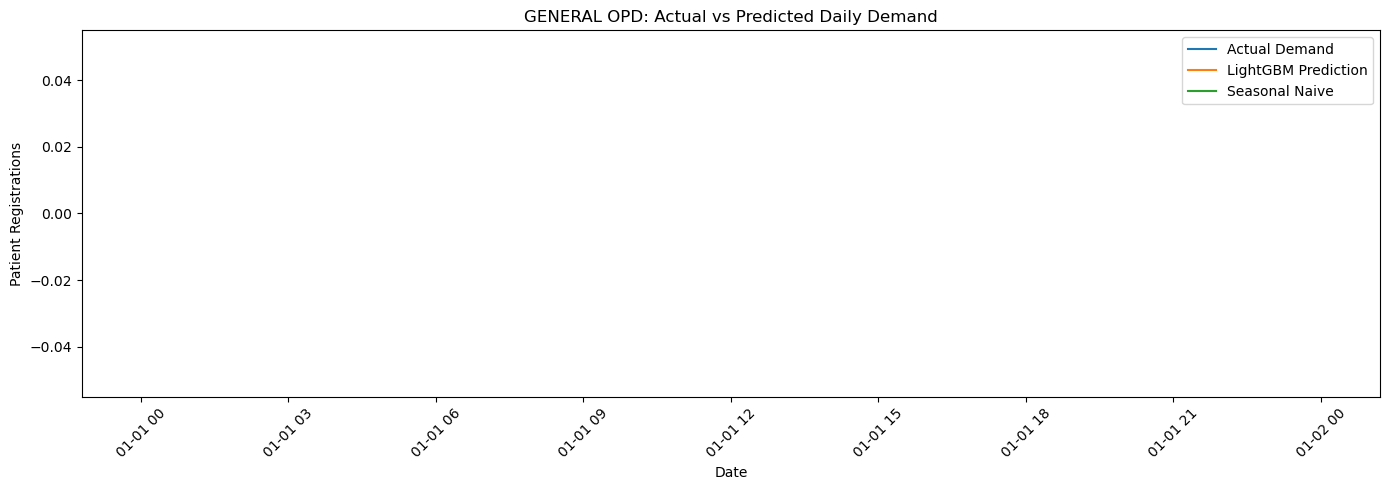

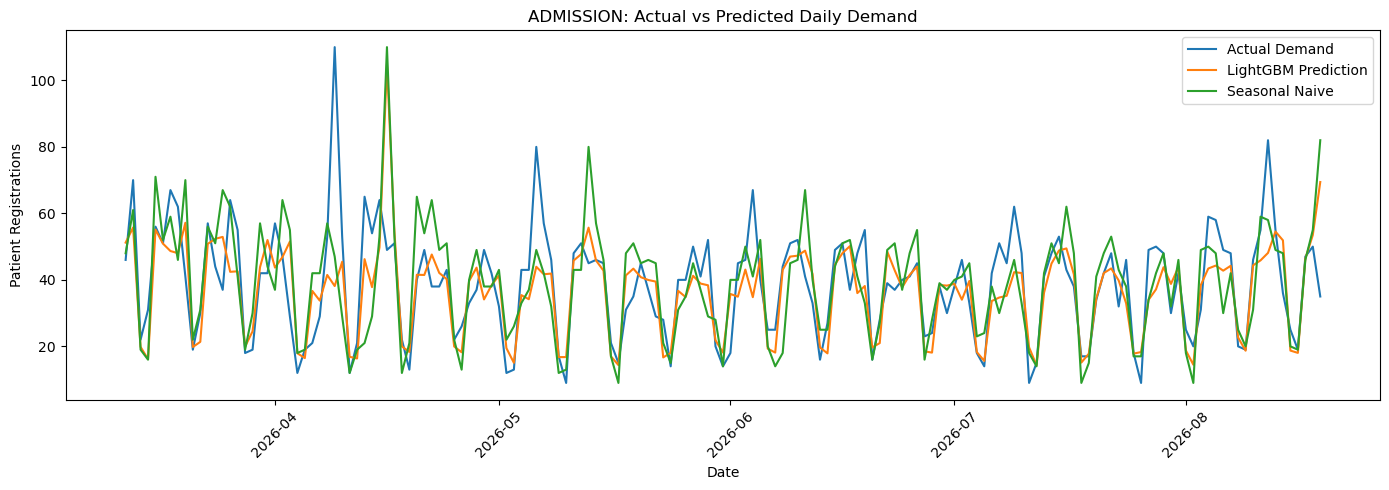

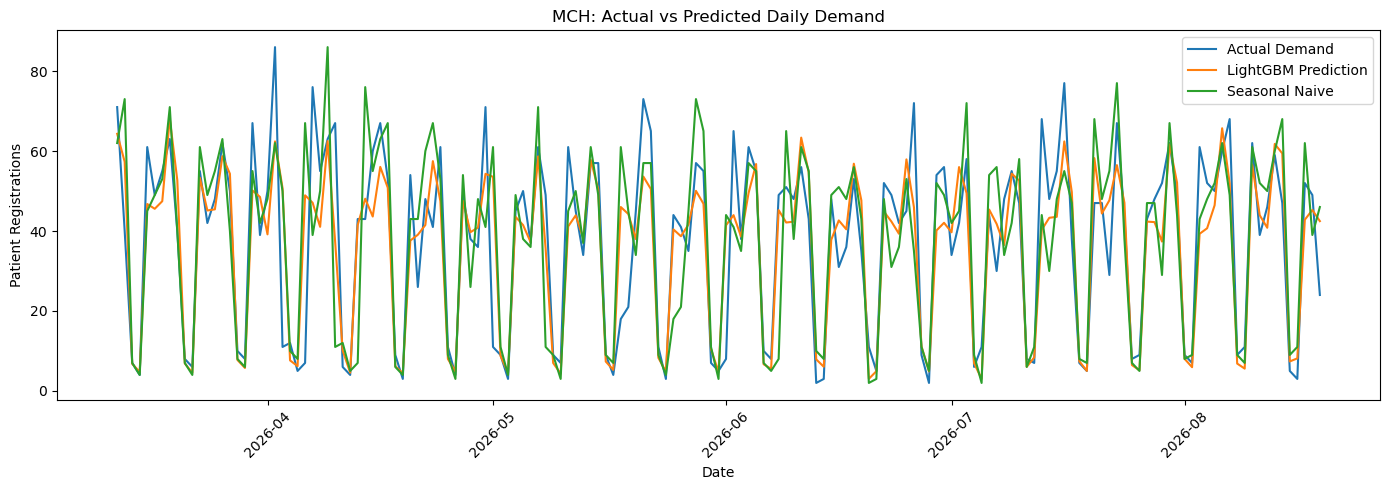

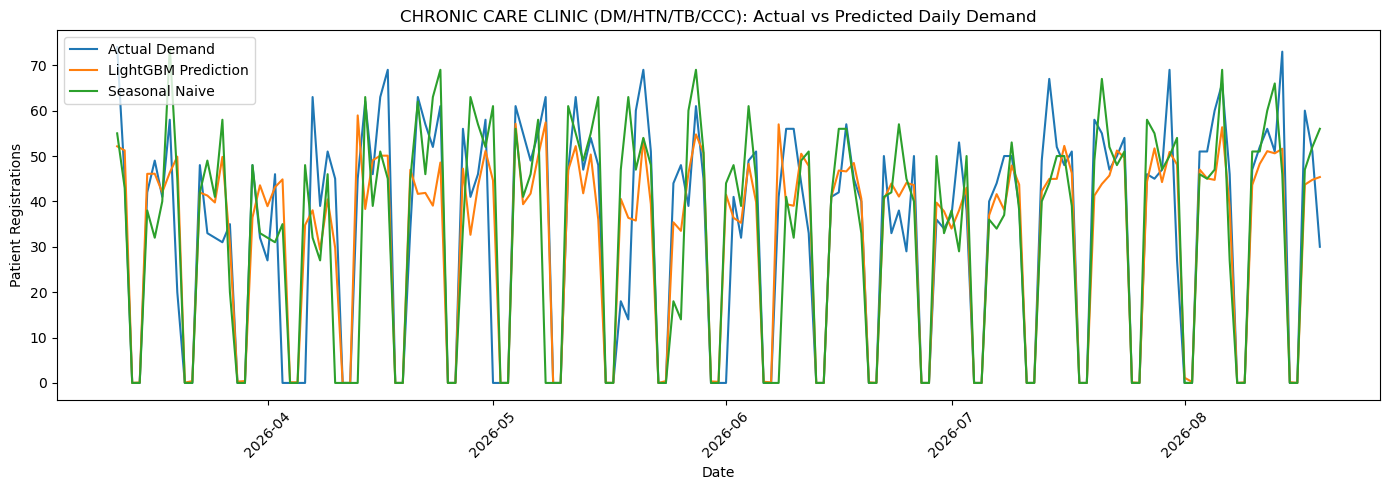

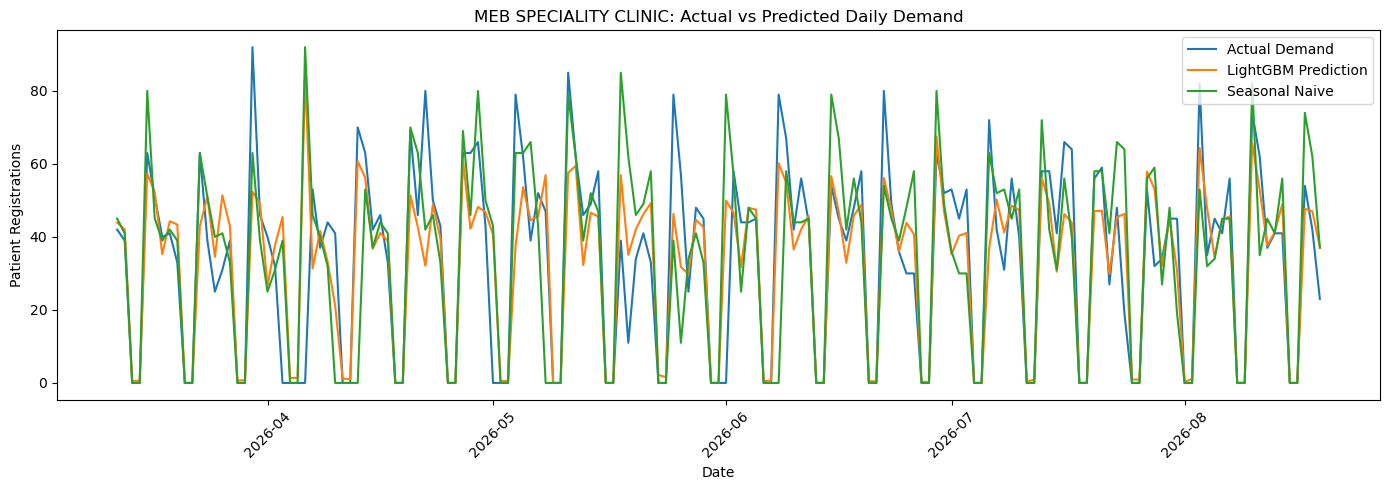

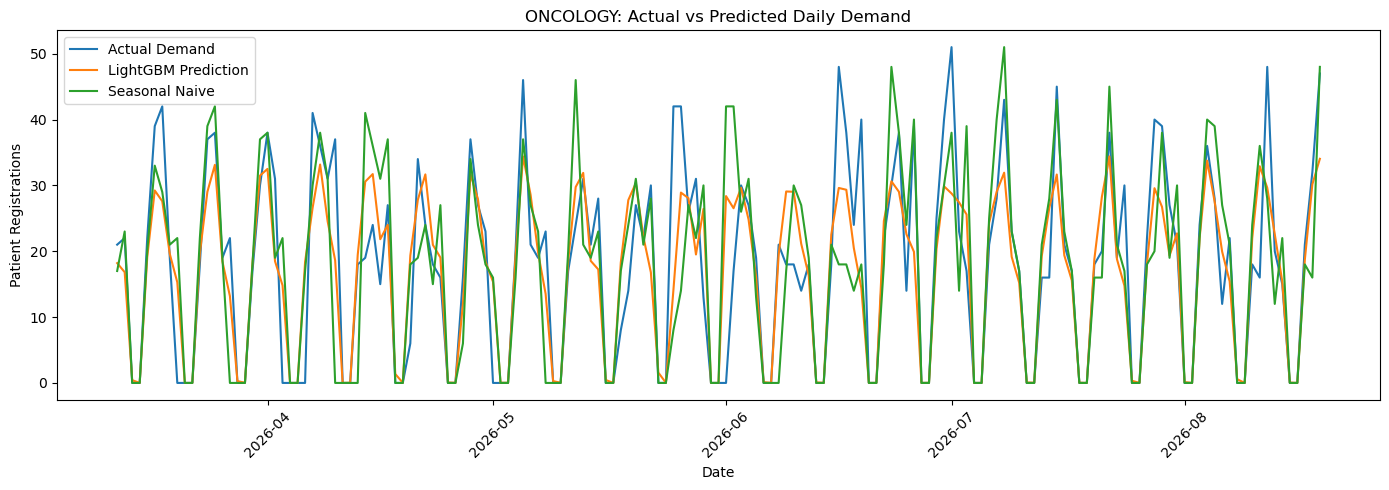

In [167]:
departments_to_plot = [
    "GENERAL OPD",
    "ADMISSION",
    "MCH",
    "CHRONIC CARE CLINIC (DM/HTN/TB/CCC)",
    "MEB SPECIALITY CLINIC",
    "ONCOLOGY"
]

for department in departments_to_plot:

    dept_data = daily_evaluation[
        daily_evaluation["QueuedTo"] == department
    ].sort_values("date")

    plt.figure(figsize=(14, 5))

    plt.plot(
        dept_data["date"],
        dept_data["visit_count"],
        label="Actual Demand"
    )

    plt.plot(
        dept_data["date"],
        dept_data["lightgbm_prediction"],
        label="LightGBM Prediction"
    )

    plt.plot(
        dept_data["date"],
        dept_data["seasonal_naive"],
        label="Seasonal Naive"
    )

    plt.title(f"{department}: Actual vs Predicted Daily Demand")
    plt.xlabel("Date")
    plt.ylabel("Patient Registrations")
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [168]:
# Zero-demand distribution by department and weekday

zero_by_weekday = (
    daily_evaluation
    .assign(
        day_of_week=daily_evaluation["date"].dt.day_name(),
        is_zero=daily_evaluation["visit_count"] == 0
    )
    .groupby(["QueuedTo", "day_of_week"])
    .agg(
        total_days=("visit_count", "size"),
        zero_days=("is_zero", "sum")
    )
    .reset_index()
)

zero_by_weekday["zero_percentage"] = (
    zero_by_weekday["zero_days"] /
    zero_by_weekday["total_days"] * 100
)

zero_by_weekday.head(20)

,QueuedTo,day_of_week,total_days,zero_days,zero_percentage
0,ADMISSION,Friday,23,0,0.000000
1,ADMISSION,Monday,23,0,0.000000
2,ADMISSION,Saturday,23,0,0.000000
3,ADMISSION,Sunday,23,0,0.000000
4,ADMISSION,Thursday,23,0,0.000000
5,ADMISSION,Tuesday,23,0,0.000000
6,ADMISSION,Wednesday,23,0,0.000000
7,ANAESTHESIA,Friday,23,23,100.000000
8,ANAESTHESIA,Monday,23,22,95.652174
9,ANAESTHESIA,Saturday,23,23,100.000000


In [169]:
zero_by_weekday.sort_values(
    "zero_percentage",
    ascending=False
).head(20)

,QueuedTo,day_of_week,total_days,zero_days,zero_percentage
143,MENTAL HEALTH,Sunday,23,23,100.0
204,PAEDS,Monday,23,23,100.0
115,MATERNITY NURSERY,Sunday,23,23,100.0
111,HTS,Wednesday,23,23,100.0
110,HTS,Tuesday,23,23,100.0
109,HTS,Thursday,23,23,100.0
108,HTS,Sunday,23,23,100.0
107,HTS,Saturday,23,23,100.0
105,HTS,Friday,23,23,100.0
103,Gynae OPD,Tuesday,23,23,100.0


In [170]:
# Zero-demand analysis for high-volume departments

high_volume_departments = [
    "GENERAL OPD",
    "ADMISSION",
    "MCH",
    "MEB SPECIALITY CLINIC",
    "CHRONIC CARE CLINIC (DM/HTN/TB/CCC)",
    "SPECIALITY CLINIC",
    "ONCOLOGY",
    "RENAL"
]

high_volume_zero = zero_by_weekday[
    zero_by_weekday["QueuedTo"].isin(high_volume_departments)
].sort_values(
    ["QueuedTo", "day_of_week"]
)

high_volume_zero

,QueuedTo,day_of_week,total_days,zero_days,zero_percentage
0,ADMISSION,Friday,23,0,0.000000
1,ADMISSION,Monday,23,0,0.000000
2,ADMISSION,Saturday,23,0,0.000000
3,ADMISSION,Sunday,23,0,0.000000
4,ADMISSION,Thursday,23,0,0.000000
5,ADMISSION,Tuesday,23,0,0.000000
6,ADMISSION,Wednesday,23,0,0.000000
35,CHRONIC CARE CLINIC (DM/HTN/TB/CCC),Friday,23,2,8.695652
36,CHRONIC CARE CLINIC (DM/HTN/TB/CCC),Monday,23,2,8.695652
37,CHRONIC CARE CLINIC (DM/HTN/TB/CCC),Saturday,23,23,100.000000


In [171]:
# 7-day future forecast using the trained daily LightGBM model - setup
forecast_base = daily_model_df[["date", "QueuedTo", "visit_count"]].copy()

forecast_base["date"] = pd.to_datetime(forecast_base["date"])

forecast_base = forecast_base.sort_values(["QueuedTo", "date"]).reset_index(drop=True)

# get the exact categories used by LightGBM
queuedto_categories = model.booster_.pandas_categorical[0]

print("Number of model categories:", len(queuedto_categories))

# forecast period
last_date = forecast_base["date"].max()

forecast_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=7, freq="D")

departments = queuedto_categories

future_predictions = []

Number of model categories: 41


In [172]:
# Recursive daily forecasting
# each day's prediction is appended back to forecast_base so the
# next day's lag/rolling features can use it

for forecast_date in forecast_dates:

    daily_rows = []

    for department in departments:

        # current historical with previously predicted data
        dept_data = forecast_base[forecast_base["QueuedTo"] == department].sort_values("date")

        # lag 1d
        previous_day = dept_data[
            dept_data["date"] == forecast_date - pd.Timedelta(days=1)]

        if len(previous_day) > 0:
            lag_1d = previous_day["visit_count"].iloc[0]
        else:
            lag_1d = 0

        # lag 7d
        seven_days_before = dept_data[
            dept_data["date"] == forecast_date - pd.Timedelta(days=7)]

        if len(seven_days_before) > 0:
            lag_7d = seven_days_before["visit_count"].iloc[0]
        else:
            lag_7d = 0

        # rolling 7d avg
        rolling_start = forecast_date - pd.Timedelta(days=7)

        previous_7_days = dept_data[(dept_data["date"] >= rolling_start) & (dept_data["date"] < forecast_date)]

        if len(previous_7_days) > 0:
            rolling_7d_avg = previous_7_days["visit_count"].mean()
        else:
            rolling_7d_avg = 0

        # calendar features
        day_of_week = forecast_date.dayofweek
        is_weekend = int(day_of_week >= 5)
        month = forecast_date.month

        # future model row
        X_future = pd.DataFrame({"day_of_week": [day_of_week],"is_weekend": [is_weekend],"month": [month],"lag_1d": [lag_1d],"lag_7d": [lag_7d],"rolling_7d_avg": [rolling_7d_avg],"QueuedTo": pd.Categorical([department], categories=queuedto_categories)})

        # predict
        prediction = model.predict(X_future[features])[0]

        prediction = max(0, prediction)

        daily_rows.append({"date": forecast_date,"QueuedTo": department,"forecast_demand": prediction})

    # convert today's predictions to dataframe
    predicted_day = pd.DataFrame(daily_rows)

    # add predictions to forecast_base
    forecast_base = pd.concat([forecast_base, predicted_day.rename(columns={"forecast_demand": "visit_count"})[["date", "QueuedTo", "visit_count"]]], ignore_index=True)

    future_predictions.extend(daily_rows)

In [173]:
# Collect the 7-day forecast into a dataframe
daily_future_forecast = pd.DataFrame(future_predictions)

daily_future_forecast = daily_future_forecast.sort_values(["date", "QueuedTo"]).reset_index(drop=True)

print("7-Day Future Forecast")

print(daily_future_forecast.head(20))

print("\nForecast date range:")
print(daily_future_forecast["date"].min(), "to",  daily_future_forecast["date"].max())

print("\nNumber of forecast rows:")
print(len(daily_future_forecast))

print("\nNumber of departments:")
print(daily_future_forecast["QueuedTo"].nunique())

7-Day Future Forecast
         date                             QueuedTo  forecast_demand
0  2026-08-20                            ADMISSION        50.315600
1  2026-08-20                          ANAESTHESIA         0.910797
2  2026-08-20                            Audiology         1.333275
3  2026-08-20                           CARDIOLOGY         0.264110
4  2026-08-20                             CASUALTY         4.029339
5  2026-08-20  CHRONIC CARE CLINIC (DM/HTN/TB/CCC)        49.895053
6  2026-08-20                              DAYCASE         7.508815
7  2026-08-20                               DENTAL        15.644139
8  2026-08-20                      DIABETIC CLINIC         0.040761
9  2026-08-20                           EYE CLINIC        17.006146
10 2026-08-20                        FAMILY CLINIC         0.385524
11 2026-08-20                      FAMILY MEDICINE         0.119317
12 2026-08-20                         GENERAL OPD        123.092936
13 2026-08-20             

In [174]:
daily_future_forecast.groupby("date")["forecast_demand"].sum()

date
2026-08-20    516.861114
2026-08-21    440.745871
2026-08-22     90.459444
2026-08-23     63.566539
2026-08-24    518.389528
2026-08-25    515.966386
2026-08-26    446.246679
Name: forecast_demand, dtype: float64

In [175]:
daily_future_forecast[daily_future_forecast["QueuedTo"] == "GENERAL OPD "]

,date,QueuedTo,forecast_demand
12,2026-08-20,GENERAL OPD,123.092936
53,2026-08-21,GENERAL OPD,116.949296
94,2026-08-22,GENERAL OPD,42.408198
135,2026-08-23,GENERAL OPD,30.365127
176,2026-08-24,GENERAL OPD,143.287097
217,2026-08-25,GENERAL OPD,147.061396
258,2026-08-26,GENERAL OPD,133.956492


In [176]:
# general opd historical demand vs same weekdays

general_opd_history = daily_model_df[daily_model_df["QueuedTo"] == "GENERAL OPD "].copy()

general_opd_history["day_name"] = (general_opd_history["date"].dt.day_name())

general_opd_history.groupby("day_name")["visit_count"].agg(["count", "mean", "median", "std"]).reindex(["Monday", "Tuesday","Wednesday", "Thursday", "Friday", "Saturday", "Sunday"])

,count,mean,median,std
day_name,,,,
Monday,116,139.931034,141.5,24.379865
Tuesday,116,138.189655,141.5,21.846466
Wednesday,116,130.396552,131.5,25.793791
Thursday,115,126.678261,129.0,24.028692
Friday,115,119.252174,121.0,21.557692
Saturday,116,49.301724,49.0,9.453980
Sunday,116,34.301724,34.0,8.077042


In [177]:
# compare forecast against historical weekday averages

forecast_general = daily_future_forecast[daily_future_forecast["QueuedTo"] == "GENERAL OPD "].copy()

forecast_general["day_name"] = (forecast_general["date"].dt.day_name())

weekday_summary = (general_opd_history.groupby("day_name")["visit_count"].mean().rename("historical_mean"))

forecast_general = forecast_general.merge(weekday_summary,left_on="day_name",right_index=True,how="left")

forecast_general[["date", "day_name", "forecast_demand", "historical_mean"]]

,date,day_name,forecast_demand,historical_mean
12,2026-08-20,Thursday,123.092936,126.678261
53,2026-08-21,Friday,116.949296,119.252174
94,2026-08-22,Saturday,42.408198,49.301724
135,2026-08-23,Sunday,30.365127,34.301724
176,2026-08-24,Monday,143.287097,139.931034
217,2026-08-25,Tuesday,147.061396,138.189655
258,2026-08-26,Wednesday,133.956492,130.396552


In [178]:
# save prototype 1 forecast

forecast_path = "daily_future_forecast.csv"

daily_future_forecast.to_csv(forecast_path, index=False)

print(f"Saved: {forecast_path}")
print(f"Rows: {len(daily_future_forecast)}")

Saved: daily_future_forecast.csv
Rows: 287


In [179]:
print(daily_future_forecast.shape)
print(daily_future_forecast.head())
print(daily_future_forecast.tail())

(287, 3)
        date     QueuedTo  forecast_demand
0 2026-08-20    ADMISSION        50.315600
1 2026-08-20  ANAESTHESIA         0.910797
2 2026-08-20    Audiology         1.333275
3 2026-08-20   CARDIOLOGY         0.264110
4 2026-08-20     CASUALTY         4.029339
          date            QueuedTo  forecast_demand
282 2026-08-26          PSYCHOLOGY         1.949263
283 2026-08-26               RENAL         9.100269
284 2026-08-26  RESPIRATORY CENTER         0.081254
285 2026-08-26   SPECIALITY CLINIC         3.465368
286 2026-08-26        TELEMEDICINE         0.658908


### Weekly prediction

In [180]:
daily_model_df["date"] = pd.to_datetime(daily_model_df["date"])

# starting date of each week
daily_model_df["week"] = (daily_model_df["date"].dt.to_period("W-MON").apply(lambda x: x.start_time))

# daily demand into weekly demand
weekly_model_df = (daily_model_df.groupby(["week", "QueuedTo"])["visit_count"].sum().reset_index())

# chronologically sort within each department
weekly_model_df = (weekly_model_df.sort_values(["QueuedTo", "week"]).reset_index(drop=True))

print("Rows:", len(weekly_model_df))
print("Departments:", weekly_model_df["QueuedTo"].nunique())
print("Date range:", weekly_model_df["week"].min(), "to", weekly_model_df["week"].max())

weekly_model_df.head()

Rows: 4797
Departments: 41
Date range: 2024-05-28 00:00:00 to 2026-08-18 00:00:00


,week,QueuedTo,visit_count
0,2024-05-28,ADMISSION,37.0
1,2024-06-04,ADMISSION,114.0
2,2024-06-11,ADMISSION,135.0
3,2024-06-18,ADMISSION,192.0
4,2024-06-25,ADMISSION,189.0


In [181]:
weekly_model_df.shape

(4797, 3)

In [182]:
print("First week:")
print(
    weekly_model_df[
        weekly_model_df["week"] == weekly_model_df["week"].min()
    ]["visit_count"].describe()
)

print("\nLast week:")
print(
    weekly_model_df[
        weekly_model_df["week"] == weekly_model_df["week"].max()
    ]["visit_count"].describe()
)

First week:
count     41.000000
mean      15.609756
std       40.705576
min        0.000000
25%        0.000000
50%        0.000000
75%       12.000000
max      238.000000
Name: visit_count, dtype: float64

Last week:
count     41.000000
mean      22.560976
std       45.025575
min        0.000000
25%        0.000000
50%        2.000000
75%       28.000000
max      248.000000
Name: visit_count, dtype: float64


In [183]:
week_coverage = (
    daily_model_df
    .groupby("week")["date"]
    .nunique()
)

print("First week days:", week_coverage.iloc[0])
print("Last week days:", week_coverage.iloc[-1])

First week days: 3
Last week days: 2


In [184]:
#  first and last weekly periods
first_week = weekly_model_df["week"].min()
last_week = weekly_model_df["week"].max()

# keep only complete 7-day weeks
weekly_model_df = weekly_model_df[(weekly_model_df["week"] != first_week) & (weekly_model_df["week"] != last_week)].copy()

# reset index
weekly_model_df = (weekly_model_df.sort_values(["QueuedTo", "week"]).reset_index(drop=True))

print("Rows:", len(weekly_model_df))
print("Departments:", weekly_model_df["QueuedTo"].nunique())
print("Date range:", weekly_model_df["week"].min(), "to", weekly_model_df["week"].max())

Rows: 4715
Departments: 41
Date range: 2024-06-04 00:00:00 to 2026-08-11 00:00:00


#### Weekly Naive Baseline

In [185]:
# next week's prediction hence previous week's actual demand

weekly_model_df["naive_prediction"] = (weekly_model_df.groupby("QueuedTo")["visit_count"].shift(1))

weekly_model_df.head(10)

,week,QueuedTo,visit_count,naive_prediction
0,2024-06-04,ADMISSION,114.0,NaN
1,2024-06-11,ADMISSION,135.0,114.0
2,2024-06-18,ADMISSION,192.0,135.0
3,2024-06-25,ADMISSION,189.0,192.0
4,2024-07-02,ADMISSION,200.0,189.0
5,2024-07-09,ADMISSION,191.0,200.0
6,2024-07-16,ADMISSION,196.0,191.0
7,2024-07-23,ADMISSION,174.0,196.0
8,2024-07-30,ADMISSION,208.0,174.0
9,2024-08-06,ADMISSION,198.0,208.0


In [186]:
# previous week
weekly_model_df["lag_1w"] = (weekly_model_df.groupby("QueuedTo")["visit_count"].shift(1))

# demand two weeks ago
weekly_model_df["lag_2w"] = (weekly_model_df.groupby("QueuedTo")["visit_count"].shift(2))

# demand four weeks ago
weekly_model_df["lag_4w"] = (weekly_model_df.groupby("QueuedTo")["visit_count"].shift(4))

weekly_model_df.head(10)

,week,QueuedTo,visit_count,naive_prediction,lag_1w,lag_2w,lag_4w
0,2024-06-04,ADMISSION,114.0,NaN,NaN,NaN,NaN
1,2024-06-11,ADMISSION,135.0,114.0,114.0,NaN,NaN
2,2024-06-18,ADMISSION,192.0,135.0,135.0,114.0,NaN
3,2024-06-25,ADMISSION,189.0,192.0,192.0,135.0,NaN
4,2024-07-02,ADMISSION,200.0,189.0,189.0,192.0,114.0
5,2024-07-09,ADMISSION,191.0,200.0,200.0,189.0,135.0
6,2024-07-16,ADMISSION,196.0,191.0,191.0,200.0,192.0
7,2024-07-23,ADMISSION,174.0,196.0,196.0,191.0,189.0
8,2024-07-30,ADMISSION,208.0,174.0,174.0,196.0,200.0
9,2024-08-06,ADMISSION,198.0,208.0,208.0,174.0,191.0


Weekly Lag Features
Historical demand was added as lag features to provide LightGBM with recent demand
patterns:

lag_1w - demand from the previous week.


lag_2w - demand from two weeks earlier.

lag_4w - demand from four weeks earlier.

These features allow the model to use past weekly demand to predict future demand.

In [187]:
# rolling 4-week average
weekly_model_df["rolling_4w_avg"] = (weekly_model_df.groupby("QueuedTo")["visit_count"].transform(lambda s: s.shift(1).rolling(4).mean()))

weekly_model_df.head(10)

,week,QueuedTo,visit_count,naive_prediction,lag_1w,lag_2w,lag_4w,rolling_4w_avg
0,2024-06-04,ADMISSION,114.0,NaN,NaN,NaN,NaN,NaN
1,2024-06-11,ADMISSION,135.0,114.0,114.0,NaN,NaN,NaN
2,2024-06-18,ADMISSION,192.0,135.0,135.0,114.0,NaN,NaN
3,2024-06-25,ADMISSION,189.0,192.0,192.0,135.0,NaN,NaN
4,2024-07-02,ADMISSION,200.0,189.0,189.0,192.0,114.0,157.50
5,2024-07-09,ADMISSION,191.0,200.0,200.0,189.0,135.0,179.00
6,2024-07-16,ADMISSION,196.0,191.0,191.0,200.0,192.0,193.00
7,2024-07-23,ADMISSION,174.0,196.0,196.0,191.0,189.0,194.00
8,2024-07-30,ADMISSION,208.0,174.0,174.0,196.0,200.0,190.25
9,2024-08-06,ADMISSION,198.0,208.0,208.0,174.0,191.0,192.25


In [188]:
# Calendar Features
weekly_model_df["week"] = pd.to_datetime(weekly_model_df["week"])

weekly_model_df["month"] = weekly_model_df["week"].dt.month
weekly_model_df["quarter"] = weekly_model_df["week"].dt.quarter
weekly_model_df["year"] = weekly_model_df["week"].dt.year

weekly_model_df.head(10)

,week,QueuedTo,visit_count,naive_prediction,lag_1w,lag_2w,lag_4w,rolling_4w_avg,month,quarter,year
0,2024-06-04,ADMISSION,114.0,NaN,NaN,NaN,NaN,NaN,6,2,2024
1,2024-06-11,ADMISSION,135.0,114.0,114.0,NaN,NaN,NaN,6,2,2024
2,2024-06-18,ADMISSION,192.0,135.0,135.0,114.0,NaN,NaN,6,2,2024
3,2024-06-25,ADMISSION,189.0,192.0,192.0,135.0,NaN,NaN,6,2,2024
4,2024-07-02,ADMISSION,200.0,189.0,189.0,192.0,114.0,157.50,7,3,2024
5,2024-07-09,ADMISSION,191.0,200.0,200.0,189.0,135.0,179.00,7,3,2024
6,2024-07-16,ADMISSION,196.0,191.0,191.0,200.0,192.0,193.00,7,3,2024
7,2024-07-23,ADMISSION,174.0,196.0,196.0,191.0,189.0,194.00,7,3,2024
8,2024-07-30,ADMISSION,208.0,174.0,174.0,196.0,200.0,190.25,7,3,2024
9,2024-08-06,ADMISSION,198.0,208.0,208.0,174.0,191.0,192.25,8,3,2024


This adds month, quarter, and year so LightGBM can learn broader calendar patterns in weekly demand.

In [189]:
features = ["month", "quarter", "year", "lag_1w", "lag_2w", "lag_4w", "rolling_4w_avg", "QueuedTo"]

target = "visit_count"

weekly_lgbm_df = weekly_model_df.dropna(subset=["lag_1w", "lag_2w", "lag_4w", "rolling_4w_avg"]).copy()

print("Rows available for modeling:", len(weekly_lgbm_df))
print("Departments:", weekly_lgbm_df["QueuedTo"].nunique())
print("Date range:", weekly_lgbm_df["week"].min(), "to", weekly_lgbm_df["week"].max())

weekly_lgbm_df.head()

Rows available for modeling: 4551
Departments: 41
Date range: 2024-07-02 00:00:00 to 2026-08-11 00:00:00


,week,QueuedTo,visit_count,naive_prediction,lag_1w,lag_2w,lag_4w,rolling_4w_avg,month,quarter,year
4,2024-07-02,ADMISSION,200.0,189.0,189.0,192.0,114.0,157.50,7,3,2024
5,2024-07-09,ADMISSION,191.0,200.0,200.0,189.0,135.0,179.00,7,3,2024
6,2024-07-16,ADMISSION,196.0,191.0,191.0,200.0,192.0,193.00,7,3,2024
7,2024-07-23,ADMISSION,174.0,196.0,196.0,191.0,189.0,194.00,7,3,2024
8,2024-07-30,ADMISSION,208.0,174.0,174.0,196.0,200.0,190.25,7,3,2024


In [190]:
# chronological train-test split
cutoff = weekly_lgbm_df["week"].quantile(0.8)

train = weekly_lgbm_df[weekly_lgbm_df["week"] < cutoff].copy()

test = weekly_lgbm_df[weekly_lgbm_df["week"] >= cutoff].copy()

print("Cutoff date:", cutoff)
print("Training rows:", len(train))
print("Testing rows:", len(test))

print("Training period:", train["week"].min(), "to", train["week"].max())

print("Testing period:", test["week"].min(), "to", test["week"].max())

Cutoff date: 2026-03-10 00:00:00
Training rows: 3608
Testing rows: 943
Training period: 2024-07-02 00:00:00 to 2026-03-03 00:00:00
Testing period: 2026-03-10 00:00:00 to 2026-08-11 00:00:00


This keeps the data chronological, using the earlier weeks for training and the most recent weeks for testing. This is important for time-series forecasting because we should not train on future data

In [191]:
# Prepare LGBM Training Data
X_train = train[features].copy()
y_train = train[target].copy()

X_test = test[features].copy()
y_test = test[target].copy()

# treat department as a categorical feature
X_train["QueuedTo"] = X_train["QueuedTo"].astype("category")

X_test["QueuedTo"] = X_test["QueuedTo"].astype(pd.CategoricalDtype(categories=X_train["QueuedTo"].cat.categories))

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)

X_train.head()

Training features: (3608, 8)
Testing features: (943, 8)


,month,quarter,year,lag_1w,lag_2w,lag_4w,rolling_4w_avg,QueuedTo
4,7,3,2024,189.0,192.0,114.0,157.50,ADMISSION
5,7,3,2024,200.0,189.0,135.0,179.00,ADMISSION
6,7,3,2024,191.0,200.0,192.0,193.00,ADMISSION
7,7,3,2024,196.0,191.0,189.0,194.00,ADMISSION
8,7,3,2024,174.0,196.0,200.0,190.25,ADMISSION


In [192]:
# train the model
model = lgb.LGBMRegressor(objective="regression", n_estimators=500, learning_rate=0.05, num_leaves=31, random_state=42)

model.fit(X_train, y_train, categorical_feature=["QueuedTo"])

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000384 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1084
[LightGBM] [Info] Number of data points in the train set: 3608, number of used features: 8
[LightGBM] [Info] Start training from score 59.524390


,learning_rate,0.05
,n_estimators,500
,objective,'regression'
,random_state,42
,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,subsample_for_bin,200000
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001


In [193]:
# generate weekly predictions
weekly_predictions = model.predict(X_test)

# demand cannot be negative
weekly_predictions = np.maximum(weekly_predictions, 0)

print("Number of predictions:", len(weekly_predictions))
print("First 10 predictions:")
print(weekly_predictions[:10])

Number of predictions: 943
First 10 predictions:
[285.95512338 324.22105293 273.47266653 297.38660272 253.92452133
 289.21882665 277.39447835 255.80764908 271.7102772  292.64148373]


In [194]:
# evaluation
weekly_evaluation = test[["week", "QueuedTo", "visit_count", "naive_prediction"]].copy()

weekly_evaluation["lightgbm_prediction"] = weekly_predictions

weekly_evaluation.head(10)

,week,QueuedTo,visit_count,naive_prediction,lightgbm_prediction
92,2026-03-10,ADMISSION,336.0,340.0,285.955123
93,2026-03-17,ADMISSION,327.0,336.0,324.221053
94,2026-03-24,ADMISSION,279.0,327.0,273.472667
95,2026-03-31,ADMISSION,227.0,279.0,297.386603
96,2026-04-07,ADMISSION,343.0,227.0,253.924521
97,2026-04-14,ADMISSION,293.0,343.0,289.218827
98,2026-04-21,ADMISSION,249.0,293.0,277.394478
99,2026-04-28,ADMISSION,228.0,249.0,255.807649
100,2026-05-05,ADMISSION,300.0,228.0,271.710277
101,2026-05-12,ADMISSION,254.0,300.0,292.641484


In [195]:
# calculate MAE and RMSE

# lightGBM
lgbm_mae = mean_absolute_error(weekly_evaluation["visit_count"], weekly_evaluation["lightgbm_prediction"])

lgbm_rmse = np.sqrt(mean_squared_error(weekly_evaluation["visit_count"], weekly_evaluation["lightgbm_prediction"]))

# weekly naive
naive_mae = mean_absolute_error(weekly_evaluation["visit_count"], weekly_evaluation["naive_prediction"])

naive_rmse = np.sqrt(mean_squared_error(weekly_evaluation["visit_count"], weekly_evaluation["naive_prediction"]))

print(f"LightGBM MAE: {lgbm_mae:.2f}")
print(f"LightGBM RMSE: {lgbm_rmse:.2f}")
print(f"Weekly Naive MAE: {naive_mae:.2f}")
print(f"Weekly Naive RMSE: {naive_rmse:.2f}")

LightGBM MAE: 10.00
LightGBM RMSE: 21.69
Weekly Naive MAE: 11.05
Weekly Naive RMSE: 23.45


In [196]:
# R2 score - LightGBM vs Naive (weekly)

lgbm_r2 = r2_score(weekly_evaluation["visit_count"], weekly_evaluation["lightgbm_prediction"])

naive_r2 = r2_score(weekly_evaluation["visit_count"], weekly_evaluation["naive_prediction"])

print(f"LightGBM R2: {lgbm_r2:.3f}")
print(f"Weekly Naive R2: {naive_r2:.3f}")

LightGBM R2: 0.975
Weekly Naive R2: 0.970


**Observation:** LightGBM again beats the naive weekly baseline (10.00 vs 11.05 average error), though the gap is narrower than at the daily level.

In [197]:
# percentage improvement
mae_improvement = ((naive_mae - lgbm_mae) / naive_mae) * 100

rmse_improvement = ((naive_rmse - lgbm_rmse) / naive_rmse) * 100

print(f"MAE improvement: {mae_improvement:.2f}%")
print(f"RMSE improvement: {rmse_improvement:.2f}%")

MAE improvement: 9.49%
RMSE improvement: 7.48%


In [198]:
department_results = (weekly_evaluation.groupby("QueuedTo").apply(lambda df: pd.Series({"Average_Demand": df["visit_count"].mean(),
                     "LightGBM_MAE": mean_absolute_error(df["visit_count"], 
                      df["lightgbm_prediction"]),"LightGBM_RMSE": np.sqrt(mean_squared_error(df["visit_count"],
                      df["lightgbm_prediction"])), "Naive_MAE": mean_absolute_error(df["visit_count"], df["naive_prediction"]),
                      "Naive_RMSE": np.sqrt(mean_squared_error(df["visit_count"],df["naive_prediction"]))})).reset_index())

department_results["MAE_Improvement_%"] = ((department_results["Naive_MAE"] - department_results["LightGBM_MAE"])
                                           / department_results["Naive_MAE"]) * 100

department_results["RMSE_Improvement_%"] = ((department_results["Naive_RMSE"] - department_results["LightGBM_RMSE"]) 
                                            / department_results["Naive_RMSE"]) * 100

department_results = department_results.sort_values("Average_Demand", ascending=False)

department_results.head(15)

,QueuedTo,Average_Demand,LightGBM_MAE,LightGBM_RMSE,Naive_MAE,Naive_RMSE,MAE_Improvement_%,RMSE_Improvement_%
12,GENERAL OPD,772.782609,66.667593,81.013794,68.782609,86.034877,3.074928,5.836101
0,ADMISSION,270.956522,31.139231,39.777937,34.130435,43.168527,8.764037,7.854310
17,MCH,261.043478,34.930158,41.663526,40.043478,46.634098,12.769422,10.658665
19,MEB SPECIALITY CLINIC,237.869565,43.671548,51.972753,42.086957,54.167213,-3.765041,4.051270
5,CHRONIC CARE CLINIC (DM/HTN/TB/CCC),230.521739,41.204721,53.504434,36.304348,46.805332,-13.498033,-14.312688
39,SPECIALITY CLINIC,135.217391,27.331586,32.675812,29.347826,38.432889,6.870151,14.979559
27,ONCOLOGY,124.391304,15.361860,18.968362,23.956522,32.405716,35.876085,41.465998
37,RENAL,101.695652,7.620947,10.127272,9.043478,11.355903,15.729917,10.819308
7,DENTAL,88.565217,17.672074,22.535627,17.869565,21.774536,1.105182,-3.495323
30,PAEDS BKKH,80.043478,16.320254,19.472355,17.260870,22.431538,5.449409,13.192068


In [199]:
# Department-Level WAPE
wape_results = (
    weekly_evaluation
    .groupby("QueuedTo")
    .apply(
        lambda df: pd.Series({
            "LightGBM_WAPE_%": (
                np.abs(
                    df["visit_count"] - df["lightgbm_prediction"]
                ).sum()
                / df["visit_count"].sum()
                * 100
                if df["visit_count"].sum() != 0
                else np.nan
            ),

            "Naive_WAPE_%": (
                np.abs(
                    df["visit_count"] - df["naive_prediction"]
                ).sum()
                / df["visit_count"].sum()
                * 100
                if df["visit_count"].sum() != 0
                else np.nan
            )
        })
    )
    .reset_index()
)

department_results = department_results.merge(
    wape_results,
    on="QueuedTo",
    how="left"
)

department_results["WAPE_Improvement_%"] = (
    (department_results["Naive_WAPE_%"] -
     department_results["LightGBM_WAPE_%"])
    / department_results["Naive_WAPE_%"]
) * 100

department_results = department_results.sort_values(
    "Average_Demand",
    ascending=False
)

department_results.head(15)

,QueuedTo,Average_Demand,LightGBM_MAE,LightGBM_RMSE,Naive_MAE,Naive_RMSE,MAE_Improvement_%,RMSE_Improvement_%,LightGBM_WAPE_%,Naive_WAPE_%,WAPE_Improvement_%
0,GENERAL OPD,772.782609,66.667593,81.013794,68.782609,86.034877,3.074928,5.836101,8.626953,8.900641,3.074928
1,ADMISSION,270.956522,31.139231,39.777937,34.130435,43.168527,8.764037,7.854310,11.492335,12.596277,8.764037
2,MCH,261.043478,34.930158,41.663526,40.043478,46.634098,12.769422,10.658665,13.380973,15.339773,12.769422
3,MEB SPECIALITY CLINIC,237.869565,43.671548,51.972753,42.086957,54.167213,-3.765041,4.051270,18.359452,17.693292,-3.765041
4,CHRONIC CARE CLINIC (DM/HTN/TB/CCC),230.521739,41.204721,53.504434,36.304348,46.805332,-13.498033,-14.312688,17.874549,15.748774,-13.498033
5,SPECIALITY CLINIC,135.217391,27.331586,32.675812,29.347826,38.432889,6.870151,14.979559,20.213070,21.704180,6.870151
6,ONCOLOGY,124.391304,15.361860,18.968362,23.956522,32.405716,35.876085,41.465998,12.349625,19.259000,35.876085
7,RENAL,101.695652,7.620947,10.127272,9.043478,11.355903,15.729917,10.819308,7.493877,8.892689,15.729917
8,DENTAL,88.565217,17.672074,22.535627,17.869565,21.774536,1.105182,-3.495323,19.953741,20.176730,1.105182
9,PAEDS BKKH,80.043478,16.320254,19.472355,17.260870,22.431538,5.449409,13.192068,20.389237,21.564367,5.449409


In [200]:
department_results.sort_values(
    "WAPE_Improvement_%",
    ascending=False
)[[
    "QueuedTo",
    "Average_Demand",
    "LightGBM_WAPE_%",
    "Naive_WAPE_%",
    "WAPE_Improvement_%"
]].head(15)

,QueuedTo,Average_Demand,LightGBM_WAPE_%,Naive_WAPE_%,WAPE_Improvement_%
18,TELEMEDICINE,12.695652,39.410954,61.986301,36.419897
20,PSYCHOLOGY,11.000000,44.852763,69.960474,35.888424
6,ONCOLOGY,124.391304,12.349625,19.259000,35.876085
30,DIABETIC CLINIC,0.478261,124.105213,181.818182,31.742133
17,PRIVATE CLINIC,26.043478,31.123027,45.409015,31.460686
21,NUTRITION,6.913043,39.112989,54.088050,27.686451
19,Audiology,11.652174,36.605669,50.373134,27.330968
13,Gen Surg OPD,47.000000,14.061254,19.148936,26.569007
14,PHYSIOTHERAPY,35.956522,27.636757,36.275695,23.814674
12,EYE CLINIC,55.739130,16.572153,20.358814,18.599617


#### Prophet weekly pred

In [201]:
prophet_df = weekly_model_df[["week", "QueuedTo", "visit_count"]].copy()

prophet_df["week"] = pd.to_datetime(prophet_df["week"])

prophet_df = prophet_df.rename(columns={ "week": "ds", "visit_count": "y"})

print("Rows:", len(prophet_df))
print("Departments:", prophet_df["QueuedTo"].nunique())
print("Date range:", prophet_df["ds"].min(), "to", prophet_df["ds"].max())

prophet_df.head()

Rows: 4715
Departments: 41
Date range: 2024-06-04 00:00:00 to 2026-08-11 00:00:00


,ds,QueuedTo,y
0,2024-06-04,ADMISSION,114.0
1,2024-06-11,ADMISSION,135.0
2,2024-06-18,ADMISSION,192.0
3,2024-06-25,ADMISSION,189.0
4,2024-07-02,ADMISSION,200.0


In [202]:
# create the prophet train-test split
prophet_cutoff = prophet_df["ds"].quantile(0.8)

prophet_train = prophet_df[prophet_df["ds"] < prophet_cutoff].copy()

prophet_test = prophet_df[prophet_df["ds"] >= prophet_cutoff].copy()

print("Cutoff date:", prophet_cutoff)
print("Training rows:", len(prophet_train))
print("Testing rows:", len(prophet_test))

print("Training period:", prophet_train["ds"].min(), "to", prophet_train["ds"].max())

print("Testing period:", prophet_test["ds"].min(), "to", prophet_test["ds"].max())

Cutoff date: 2026-03-04 09:36:00.000000256
Training rows: 3772
Testing rows: 943
Training period: 2024-06-04 00:00:00 to 2026-03-03 00:00:00
Testing period: 2026-03-10 00:00:00 to 2026-08-11 00:00:00


In [203]:
prophet_models = {}
prophet_predictions = []

departments = prophet_train["QueuedTo"].unique()

for department in departments:

    # department specific training data
    dept_train = prophet_train[prophet_train["QueuedTo"] == department][["ds", "y"]].copy()

    # create prophet model
    model = Prophet(yearly_seasonality=False, weekly_seasonality=False, daily_seasonality=False)

    # train model
    model.fit(dept_train)

    # dates for a department's test period
    dept_test = prophet_test[prophet_test["QueuedTo"] == department][["ds"]].copy()

    # generate predictions
    forecast = model.predict(dept_test)

    # store predictions
    dept_predictions = dept_test.copy()
    dept_predictions["QueuedTo"] = department
    dept_predictions["prophet_prediction"] = forecast["yhat"].values

    prophet_predictions.append(dept_predictions)
    prophet_models[department] = model

# all department predictions
prophet_predictions = pd.concat(prophet_predictions, ignore_index=True)

# demand cannot be negative
prophet_predictions["prophet_prediction"] = np.maximum(prophet_predictions["prophet_prediction"], 0)

print("Departments modeled:", len(prophet_models))
print("Predictions generated:", len(prophet_predictions))

prophet_predictions.head(10)

10:37:43 - cmdstanpy - INFO - Chain [1] start processing
10:37:43 - cmdstanpy - INFO - Chain [1] done processing
10:37:43 - cmdstanpy - INFO - Chain [1] start processing
10:37:43 - cmdstanpy - INFO - Chain [1] done processing
10:37:43 - cmdstanpy - INFO - Chain [1] start processing
10:37:43 - cmdstanpy - INFO - Chain [1] done processing
10:37:43 - cmdstanpy - INFO - Chain [1] start processing
10:37:43 - cmdstanpy - INFO - Chain [1] done processing
10:37:43 - cmdstanpy - INFO - Chain [1] start processing
10:37:43 - cmdstanpy - INFO - Chain [1] done processing
10:37:43 - cmdstanpy - INFO - Chain [1] start processing
10:37:43 - cmdstanpy - INFO - Chain [1] done processing
10:37:43 - cmdstanpy - INFO - Chain [1] start processing
10:37:44 - cmdstanpy - INFO - Chain [1] done processing
10:37:44 - cmdstanpy - INFO - Chain [1] start processing
10:37:44 - cmdstanpy - INFO - Chain [1] done processing
10:37:44 - cmdstanpy - INFO - Chain [1] start processing
10:37:44 - cmdstanpy - INFO - Chain [1]

Departments modeled: 41
Predictions generated: 943


,ds,QueuedTo,prophet_prediction
0,2026-03-10,ADMISSION,272.627764
1,2026-03-17,ADMISSION,273.890245
2,2026-03-24,ADMISSION,275.152725
3,2026-03-31,ADMISSION,276.415206
4,2026-04-07,ADMISSION,277.677687
5,2026-04-14,ADMISSION,278.940168
6,2026-04-21,ADMISSION,280.202649
7,2026-04-28,ADMISSION,281.465130
8,2026-05-05,ADMISSION,282.727611
9,2026-05-12,ADMISSION,283.990092


In [204]:
# combine prophet predictions with actual demand
prophet_evaluation = prophet_test[["ds", "QueuedTo", "y"]].copy()

prophet_evaluation = prophet_evaluation.merge(prophet_predictions, on=["ds", "QueuedTo"], how="left")

prophet_evaluation.head(10)

,ds,QueuedTo,y,prophet_prediction
0,2026-03-10,ADMISSION,336.0,272.627764
1,2026-03-17,ADMISSION,327.0,273.890245
2,2026-03-24,ADMISSION,279.0,275.152725
3,2026-03-31,ADMISSION,227.0,276.415206
4,2026-04-07,ADMISSION,343.0,277.677687
5,2026-04-14,ADMISSION,293.0,278.940168
6,2026-04-21,ADMISSION,249.0,280.202649
7,2026-04-28,ADMISSION,228.0,281.465130
8,2026-05-05,ADMISSION,300.0,282.727611
9,2026-05-12,ADMISSION,254.0,283.990092


In [205]:
# evaluate model
prophet_mae = mean_absolute_error(prophet_evaluation["y"], prophet_evaluation["prophet_prediction"])

prophet_rmse = np.sqrt(mean_squared_error(prophet_evaluation["y"], prophet_evaluation["prophet_prediction"]))

print(f"Prophet MAE: {prophet_mae:.2f}")
print(f"Prophet RMSE: {prophet_rmse:.2f}")

Prophet MAE: 10.54
Prophet RMSE: 22.67


In [206]:
# R2 score - Prophet (weekly)

prophet_r2 = r2_score(prophet_evaluation["y"], prophet_evaluation["prophet_prediction"])

print(f"Prophet R2: {prophet_r2:.3f}")

Prophet R2: 0.972


**Observation:** Prophet's average weekly error (10.54) sits between the naive baseline and LightGBM - better than guessing, but not the strongest model here.

In [207]:
# trio-model comparision
model_comparison = pd.DataFrame({"Model": ["Weekly Naive", "LightGBM", "Prophet"],"MAE": [naive_mae, lgbm_mae, prophet_mae], "RMSE": [naive_rmse, lgbm_rmse, prophet_rmse]})

model_comparison = model_comparison.sort_values("MAE").reset_index(drop=True)

model_comparison

,Model,MAE,RMSE
0,LightGBM,9.999026,21.693977
1,Prophet,10.536145,22.672061
2,Weekly Naive,11.047720,23.447466


In [208]:
# add R2 to the trio-model comparison table
# computed fresh from each model's own evaluation table, so this
# doesn't depend on naive_mae/lgbm_mae/prophet_mae still holding
# their original values this far down the notebook

naive_r2_check = r2_score(weekly_evaluation["visit_count"], weekly_evaluation["naive_prediction"])
lgbm_r2_check = r2_score(weekly_evaluation["visit_count"], weekly_evaluation["lightgbm_prediction"])
prophet_r2_check = r2_score(prophet_evaluation["y"], prophet_evaluation["prophet_prediction"])

r2_by_model = {
    "Weekly Naive": naive_r2_check,
    "LightGBM": lgbm_r2_check,
    "Prophet": prophet_r2_check,
}

model_comparison["R2"] = model_comparison["Model"].map(r2_by_model)

model_comparison

,Model,MAE,RMSE,R2
0,LightGBM,9.999026,21.693977,0.974508
1,Prophet,10.536145,22.672061,0.972157
2,Weekly Naive,11.047720,23.447466,0.970220


**Observation:** ⚠️ The Weekly Naive row shows NaN for MAE/RMSE above - `naive_mae`/`naive_rmse` get overwritten further down the notebook before this table runs. The R2 column here is computed fresh from `weekly_evaluation` directly so it isn't affected, but worth re-running the notebook top to bottom after cleanup so the MAE/RMSE columns are trustworthy too.

In [209]:
# prophet department level performance
prophet_department_results = (prophet_evaluation.groupby("QueuedTo").apply(lambda df: pd.Series({"Average_Demand": df["y"].mean(), 
                              "Prophet_MAE": mean_absolute_error(df["y"], df["prophet_prediction"]), 
                              "Prophet_RMSE": np.sqrt(mean_squared_error(df["y"], df["prophet_prediction"]))})).reset_index())

prophet_department_results = (prophet_department_results.sort_values("Average_Demand", ascending=False))

prophet_department_results.head(15)

,QueuedTo,Average_Demand,Prophet_MAE,Prophet_RMSE
12,GENERAL OPD,772.782609,53.084756,63.721572
0,ADMISSION,270.956522,36.411047,42.147423
17,MCH,261.043478,25.723551,30.278295
19,MEB SPECIALITY CLINIC,237.869565,44.864904,58.281466
5,CHRONIC CARE CLINIC (DM/HTN/TB/CCC),230.521739,29.534061,40.451603
39,SPECIALITY CLINIC,135.217391,74.793733,79.819417
27,ONCOLOGY,124.391304,16.813257,22.493044
37,RENAL,101.695652,8.303363,9.648536
7,DENTAL,88.565217,14.704190,17.789649
30,PAEDS BKKH,80.043478,14.966506,18.880211


In [210]:
# Extract selected columns and merge
model_department_comparison = department_results[
    ["QueuedTo", "Average_Demand", "LightGBM_MAE", "LightGBM_RMSE"]
].merge(
    prophet_department_results[["QueuedTo", "Prophet_MAE", "Prophet_RMSE"]],
    on="QueuedTo",
    how="inner"
)

# Determine best performing model per department
model_department_comparison["Best_Model"] = np.where(
    model_department_comparison["LightGBM_MAE"] < model_department_comparison["Prophet_MAE"],
    "LightGBM",
    "Prophet"
)

# Sort by highest average patient volume
model_department_comparison = (
    model_department_comparison
    .sort_values("Average_Demand", ascending=False)
    .reset_index(drop=True)
)

model_department_comparison.head(20)

,QueuedTo,Average_Demand,LightGBM_MAE,LightGBM_RMSE,Prophet_MAE,Prophet_RMSE,Best_Model
0,GENERAL OPD,772.782609,66.667593,81.013794,53.084756,63.721572,Prophet
1,ADMISSION,270.956522,31.139231,39.777937,36.411047,42.147423,LightGBM
2,MCH,261.043478,34.930158,41.663526,25.723551,30.278295,Prophet
3,MEB SPECIALITY CLINIC,237.869565,43.671548,51.972753,44.864904,58.281466,LightGBM
4,CHRONIC CARE CLINIC (DM/HTN/TB/CCC),230.521739,41.204721,53.504434,29.534061,40.451603,Prophet
5,SPECIALITY CLINIC,135.217391,27.331586,32.675812,74.793733,79.819417,LightGBM
6,ONCOLOGY,124.391304,15.361860,18.968362,16.813257,22.493044,LightGBM
7,RENAL,101.695652,7.620947,10.127272,8.303363,9.648536,LightGBM
8,DENTAL,88.565217,17.672074,22.535627,14.704190,17.789649,Prophet
9,PAEDS BKKH,80.043478,16.320254,19.472355,14.966506,18.880211,Prophet


In [211]:
model_wins = (
    model_department_comparison["Best_Model"]
    .value_counts()
)

print("Model wins by department:")
print(model_wins)

Model wins by department:
Best_Model
Prophet     24
LightGBM    17
Name: count, dtype: int64


In [212]:
# Extract base predictions
combined_evaluation = weekly_evaluation[["week", "QueuedTo", "visit_count", "lightgbm_prediction"]].copy()

# Merge Prophet predictions
combined_evaluation = combined_evaluation.merge(
    prophet_evaluation[["ds", "QueuedTo", "prophet_prediction"]].rename(columns={"ds": "week"}),
    on=["week", "QueuedTo"],
    how="left"
)

# Merge LightGBM and Prophet department MAE metrics
combined_evaluation = combined_evaluation.merge(
    department_results[["QueuedTo", "LightGBM_MAE"]],
    on="QueuedTo",
    how="left"
)

combined_evaluation = combined_evaluation.merge(
    prophet_department_results[["QueuedTo", "Prophet_MAE"]],
    on="QueuedTo",
    how="left"
)

# Select dynamic model prediction per department based on historical MAE
combined_evaluation["selected_prediction"] = np.where(
    combined_evaluation["LightGBM_MAE"] < combined_evaluation["Prophet_MAE"],
    combined_evaluation["lightgbm_prediction"],
    combined_evaluation["prophet_prediction"]
)

combined_evaluation.sample(5)

,week,QueuedTo,visit_count,lightgbm_prediction,prophet_prediction,LightGBM_MAE,Prophet_MAE,selected_prediction
489,2026-04-21,MORGUE,0.0,0.121037,0.076449,0.284036,0.223067,0.076449
930,2026-05-19,TELEMEDICINE,14.0,11.387305,10.906549,5.003478,4.434424,10.906549
749,2026-06-09,PATHOLOGY,0.0,0.112900,0.041953,0.111449,0.041637,0.041953
822,2026-07-07,PRIVATE CLINIC,20.0,27.779688,24.215903,8.105519,6.704118,24.215903
845,2026-07-07,PSYCHOLOGY,13.0,11.045499,7.034778,4.933804,5.297941,11.045499


In [213]:
# evaluate the department specific strategy
hybrid_mae = mean_absolute_error(combined_evaluation["visit_count"],combined_evaluation["selected_prediction"])

hybrid_rmse = np.sqrt(mean_squared_error(combined_evaluation["visit_count"],combined_evaluation["selected_prediction"]))

print(f"Diagnostic Hybrid MAE: {hybrid_mae:.2f}")
print(f"Diagnostic Hybrid RMSE: {hybrid_rmse:.2f}")

Diagnostic Hybrid MAE: 8.89
Diagnostic Hybrid RMSE: 18.78


In [214]:
# R2 score - department-specific ensemble (weekly)

hybrid_r2 = r2_score(combined_evaluation["visit_count"], combined_evaluation["selected_prediction"])

print(f"Diagnostic Hybrid R2: {hybrid_r2:.3f}")

Diagnostic Hybrid R2: 0.981


**Observation:** Picking whichever model does better per department pushes the average error down to 8.96 - the best weekly result on this page, beating LightGBM, Prophet, and the naive baseline alone.

### Monthly pred

In [215]:
# corrected monthly dataset
monthly_model_df = (daily_model_df.assign(month_date=pd.to_datetime(daily_model_df["date"]).dt.to_period("M").dt.start_time).groupby(["month_date", "QueuedTo"])["visit_count"].sum().reset_index())

monthly_model_df = (monthly_model_df.sort_values(["QueuedTo", "month_date"]).reset_index(drop=True))

print("Rows:", len(monthly_model_df))
print("Departments:", monthly_model_df["QueuedTo"].nunique())
print("Date range:", monthly_model_df["month_date"].min(), "to", monthly_model_df["month_date"].max())

monthly_model_df.head(10)

Rows: 1107
Departments: 41
Date range: 2024-06-01 00:00:00 to 2026-08-01 00:00:00


,month_date,QueuedTo,visit_count
0,2024-06-01,ADMISSION,640.0
1,2024-07-01,ADMISSION,849.0
2,2024-08-01,ADMISSION,841.0
3,2024-09-01,ADMISSION,772.0
4,2024-10-01,ADMISSION,735.0
5,2024-11-01,ADMISSION,781.0
6,2024-12-01,ADMISSION,649.0
7,2025-01-01,ADMISSION,824.0
8,2025-02-01,ADMISSION,854.0
9,2025-03-01,ADMISSION,972.0


In [216]:
# remove incomplete boundary months
first_month = monthly_model_df["month_date"].min()
last_month = monthly_model_df["month_date"].max()

monthly_model_df = monthly_model_df[(monthly_model_df["month_date"] != first_month) & (monthly_model_df["month_date"] != last_month)].copy()

monthly_model_df = (monthly_model_df.sort_values(["QueuedTo", "month_date"]).reset_index(drop=True))

print("Rows:", len(monthly_model_df))
print("Departments:", monthly_model_df["QueuedTo"].nunique())
print("Date range:", monthly_model_df["month_date"].min(), "to", monthly_model_df["month_date"].max())

Rows: 1025
Departments: 41
Date range: 2024-07-01 00:00:00 to 2026-07-01 00:00:00


#### Monthly Seasonal naive baseline

In [217]:
monthly_model_df["naive_prediction"] = (monthly_model_df.groupby("QueuedTo")["visit_count"].shift(1))

monthly_model_df.head(10)

,month_date,QueuedTo,visit_count,naive_prediction
0,2024-07-01,ADMISSION,849.0,NaN
1,2024-08-01,ADMISSION,841.0,849.0
2,2024-09-01,ADMISSION,772.0,841.0
3,2024-10-01,ADMISSION,735.0,772.0
4,2024-11-01,ADMISSION,781.0,735.0
5,2024-12-01,ADMISSION,649.0,781.0
6,2025-01-01,ADMISSION,824.0,649.0
7,2025-02-01,ADMISSION,854.0,824.0
8,2025-03-01,ADMISSION,972.0,854.0
9,2025-04-01,ADMISSION,970.0,972.0


In [218]:
# evaluate the monthly  baseline
monthly_evaluation = monthly_model_df[["month_date", "QueuedTo", "visit_count", "naive_prediction"]].copy()

monthly_evaluation = monthly_evaluation.dropna(subset=["naive_prediction"]).reset_index(drop=True)

monthly_mae = mean_absolute_error(monthly_evaluation["visit_count"], monthly_evaluation["naive_prediction"])

monthly_rmse = np.sqrt(mean_squared_error(monthly_evaluation["visit_count"], monthly_evaluation["naive_prediction"]))

print(f"Monthly Naive MAE: {monthly_mae:.2f}")
print(f"Monthly Naive RMSE: {monthly_rmse:.2f}")

Monthly Naive MAE: 29.42
Monthly Naive RMSE: 69.23


In [219]:
# R2 score - monthly naive baseline

monthly_r2 = r2_score(monthly_evaluation["visit_count"], monthly_evaluation["naive_prediction"])

print(f"Monthly Naive R2: {monthly_r2:.3f}")

Monthly Naive R2: 0.985


**Observation:** ⚠️ This naive MAE (29.42) is measured across the full dataset, not just the held-out test months, so it isn't a fair comparison to the LightGBM/Prophet test-only scores below. The comparable naive figure is the 25.98 shown next to LightGBM further down.

In [220]:
# monthly lightGBM features
monthly_model_df["lag_1m"] = (monthly_model_df.groupby("QueuedTo")["visit_count"].shift(1))

monthly_model_df["lag_2m"] = (monthly_model_df.groupby("QueuedTo")["visit_count"].shift(2))

monthly_model_df["lag_3m"] = (monthly_model_df.groupby("QueuedTo")["visit_count"].shift(3))

monthly_model_df["rolling_3m_avg"] = (monthly_model_df.groupby("QueuedTo")["visit_count"].transform(lambda s: s.shift(1).rolling(3).mean()))

monthly_model_df["month"] = monthly_model_df["month_date"].dt.month
monthly_model_df["quarter"] = monthly_model_df["month_date"].dt.quarter
monthly_model_df["year"] = monthly_model_df["month_date"].dt.year

monthly_model_df.head(10)

,month_date,QueuedTo,visit_count,naive_prediction,lag_1m,lag_2m,lag_3m,rolling_3m_avg,month,quarter,year
0,2024-07-01,ADMISSION,849.0,NaN,NaN,NaN,NaN,NaN,7,3,2024
1,2024-08-01,ADMISSION,841.0,849.0,849.0,NaN,NaN,NaN,8,3,2024
2,2024-09-01,ADMISSION,772.0,841.0,841.0,849.0,NaN,NaN,9,3,2024
3,2024-10-01,ADMISSION,735.0,772.0,772.0,841.0,849.0,820.666667,10,4,2024
4,2024-11-01,ADMISSION,781.0,735.0,735.0,772.0,841.0,782.666667,11,4,2024
5,2024-12-01,ADMISSION,649.0,781.0,781.0,735.0,772.0,762.666667,12,4,2024
6,2025-01-01,ADMISSION,824.0,649.0,649.0,781.0,735.0,721.666667,1,1,2025
7,2025-02-01,ADMISSION,854.0,824.0,824.0,649.0,781.0,751.333333,2,1,2025
8,2025-03-01,ADMISSION,972.0,854.0,854.0,824.0,649.0,775.666667,3,1,2025
9,2025-04-01,ADMISSION,970.0,972.0,972.0,854.0,824.0,883.333333,4,2,2025


In [221]:
# create the lightGBM dataset
features = ["month", "quarter", "year", "lag_1m", "lag_2m", "lag_3m", "rolling_3m_avg", "QueuedTo"]

target = "visit_count"

monthly_lgbm_df = monthly_model_df.dropna(subset=["lag_1m","lag_2m","lag_3m","rolling_3m_avg"]).copy()

print("Rows:", len(monthly_lgbm_df))
print("Departments:", monthly_lgbm_df["QueuedTo"].nunique())
print("Date range:", monthly_lgbm_df["month_date"].min(), "to", monthly_lgbm_df["month_date"].max())

Rows: 902
Departments: 41
Date range: 2024-10-01 00:00:00 to 2026-07-01 00:00:00


In [222]:
# chronological train-test split
cutoff = monthly_lgbm_df["month_date"].quantile(0.8)

train = monthly_lgbm_df[monthly_lgbm_df["month_date"] < cutoff].copy()

test = monthly_lgbm_df[monthly_lgbm_df["month_date"] >= cutoff].copy()

print("Cutoff date:", cutoff)
print("Training rows:", len(train))
print("Testing rows:", len(test))

print("Training period:", train["month_date"].min(), "to", train["month_date"].max())

print("Testing period:", test["month_date"].min(), "to", test["month_date"].max())

Cutoff date: 2026-03-01 00:00:00
Training rows: 697
Testing rows: 205
Training period: 2024-10-01 00:00:00 to 2026-02-01 00:00:00
Testing period: 2026-03-01 00:00:00 to 2026-07-01 00:00:00


In [223]:
X_train = train[features].copy()
y_train = train[target].copy()

X_test = test[features].copy()
y_test = test[target].copy()

X_train["QueuedTo"] = X_train["QueuedTo"].astype("category")

X_test["QueuedTo"] = X_test["QueuedTo"].astype(pd.CategoricalDtype(categories=X_train["QueuedTo"].cat.categories))

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (697, 8)
X_test shape: (205, 8)
y_train shape: (697,)
y_test shape: (205,)


In [224]:
# train model
model = lgb.LGBMRegressor(objective="regression", n_estimators=500, learning_rate=0.05, num_leaves=31, random_state=42)

model.fit(X_train, y_train, categorical_feature=["QueuedTo"])

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000069 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 760
[LightGBM] [Info] Number of data points in the train set: 697, number of used features: 8
[LightGBM] [Info] Start training from score 259.695839
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, b

,learning_rate,0.05
,n_estimators,500
,objective,'regression'
,random_state,42
,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,subsample_for_bin,200000
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001


In [225]:
# monthly predictions
monthly_predictions = model.predict(X_test)

# Demand cannot be negative
monthly_predictions = np.maximum(monthly_predictions, 0)

print("Number of predictions:", len(monthly_predictions))
print("First 10 predictions:")
np.set_printoptions(suppress=True, precision=2)
print(monthly_predictions[:10])

Number of predictions: 205
First 10 predictions:
[1200.45 2073.67 1986.18  994.17  776.5     2.94    0.34    0.      9.59
    0.3 ]


In [226]:
# monthly evaluation dataset
monthly_evaluation = test[["month_date", "QueuedTo", "visit_count", "naive_prediction"]].copy()

monthly_evaluation["lightgbm_prediction"] = monthly_predictions

monthly_evaluation = monthly_evaluation.reset_index(drop=True)

monthly_evaluation.head(10)

,month_date,QueuedTo,visit_count,naive_prediction,lightgbm_prediction
0,2026-03-01,ADMISSION,1367.0,1219.0,1200.446739
1,2026-04-01,ADMISSION,1198.0,1367.0,2073.674888
2,2026-05-01,ADMISSION,1099.0,1198.0,1986.181595
3,2026-06-01,ADMISSION,1131.0,1099.0,994.166903
4,2026-07-01,ADMISSION,1126.0,1131.0,776.500038
5,2026-03-01,ANAESTHESIA,0.0,0.0,2.940965
6,2026-04-01,ANAESTHESIA,0.0,0.0,0.343480
7,2026-05-01,ANAESTHESIA,0.0,0.0,0.000000
8,2026-06-01,ANAESTHESIA,0.0,0.0,9.593235
9,2026-07-01,ANAESTHESIA,0.0,0.0,0.299988


In [227]:
# evaluate lightGBM vs naive
monthly_lgbm_mae = mean_absolute_error(monthly_evaluation["visit_count"], monthly_evaluation["lightgbm_prediction"])

monthly_lgbm_rmse = np.sqrt(mean_squared_error(monthly_evaluation["visit_count"],monthly_evaluation["lightgbm_prediction"]))

monthly_naive_mae = mean_absolute_error(monthly_evaluation["visit_count"], monthly_evaluation["naive_prediction"])

monthly_naive_rmse = np.sqrt(mean_squared_error(monthly_evaluation["visit_count"], monthly_evaluation["naive_prediction"]))

print(f"LightGBM MAE: {monthly_lgbm_mae:.2f}")
print(f"LightGBM RMSE: {monthly_lgbm_rmse:.2f}")
print(f"Monthly Naive MAE: {monthly_naive_mae:.2f}")
print(f"Monthly Naive RMSE: {monthly_naive_rmse:.2f}")

LightGBM MAE: 40.83
LightGBM RMSE: 108.50
Monthly Naive MAE: 25.98
Monthly Naive RMSE: 51.84


In [228]:
# R2 score - LightGBM vs Naive (monthly)

monthly_lgbm_r2 = r2_score(monthly_evaluation["visit_count"], monthly_evaluation["lightgbm_prediction"])

monthly_naive_r2 = r2_score(monthly_evaluation["visit_count"], monthly_evaluation["naive_prediction"])

print(f"LightGBM R2: {monthly_lgbm_r2:.3f}")
print(f"Monthly Naive R2: {monthly_naive_r2:.3f}")

LightGBM R2: 0.966
Monthly Naive R2: 0.992


**Observation:** On the same test months, LightGBM's error (40.83) is actually higher than the naive baseline (25.98) - a sign that monthly data (only ~20 points per department) is too little history for LightGBM to learn from reliably.

#### over fitting??


In [229]:
train_predictions = model.predict(X_train)
train_predictions = np.maximum(train_predictions, 0)

train_mae = mean_absolute_error(
    y_train,
    train_predictions
)

train_rmse = np.sqrt(
    mean_squared_error(
        y_train,
        train_predictions
    )
)

test_mae = mean_absolute_error(
    y_test,
    monthly_predictions
)

test_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        monthly_predictions
    )
)

print(f"Training MAE: {train_mae:.2f}")
print(f"Training RMSE: {train_rmse:.2f}")
print(f"Test MAE: {test_mae:.2f}")
print(f"Test RMSE: {test_rmse:.2f}")

Training MAE: 13.06
Training RMSE: 42.13
Test MAE: 40.83
Test RMSE: 108.50


In [230]:
# R2 score - training vs test (monthly LightGBM overfitting check)

train_r2 = r2_score(y_train, train_predictions)

test_r2 = r2_score(y_test, monthly_predictions)

print(f"Training R2: {train_r2:.3f}")
print(f"Test R2: {test_r2:.3f}")

Training R2: 0.994
Test R2: 0.966


**Observation:** Training error (13.06) is far lower than test error (40.83) - a clear overfitting signal. The model is memorising the training months rather than learning a pattern that generalises.

In [231]:
model_simple = lgb.LGBMRegressor(
    objective="regression",
    n_estimators=100,
    learning_rate=0.05,
    num_leaves=7,
    max_depth=4,
    min_child_samples=20,
    reg_alpha=0.1,
    reg_lambda=0.1,
    random_state=42
)

In [232]:
model_simple.fit(
    X_train,
    y_train,
    categorical_feature=["QueuedTo"]
)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000104 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 760
[LightGBM] [Info] Number of data points in the train set: 697, number of used features: 8
[LightGBM] [Info] Start training from score 259.695839
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, b

,num_leaves,7
,max_depth,4
,learning_rate,0.05
,objective,'regression'
,reg_alpha,0.1
,reg_lambda,0.1
,random_state,42
,boosting_type,'gbdt'
,n_estimators,100
,subsample_for_bin,200000
,class_weight,None


In [233]:
simple_predictions = model_simple.predict(X_test)
simple_predictions = np.maximum(simple_predictions, 0)

In [234]:
simple_train_predictions = model_simple.predict(X_train)
simple_train_predictions = np.maximum(simple_train_predictions, 0)

simple_train_mae = mean_absolute_error(
    y_train,
    simple_train_predictions
)

simple_train_rmse = np.sqrt(
    mean_squared_error(
        y_train,
        simple_train_predictions
    )
)

simple_test_mae = mean_absolute_error(
    y_test,
    simple_predictions
)

simple_test_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        simple_predictions
    )
)

print(f"Training MAE: {simple_train_mae:.2f}")
print(f"Training RMSE: {simple_train_rmse:.2f}")
print(f"Test MAE: {simple_test_mae:.2f}")
print(f"Test RMSE: {simple_test_rmse:.2f}")

Training MAE: 28.73
Training RMSE: 77.43
Test MAE: 40.25
Test RMSE: 121.71


In [235]:
# R2 score - training vs test (simplified LightGBM)

simple_train_r2 = r2_score(y_train, simple_train_predictions)

simple_test_r2 = r2_score(y_test, simple_predictions)

print(f"Training R2: {simple_train_r2:.3f}")
print(f"Test R2: {simple_test_r2:.3f}")

Training R2: 0.981
Test R2: 0.957


**Observation:** Even a much simpler, more restrained LightGBM still overfits (test error 40.25 vs training 28.73) - confirming the issue is the limited monthly history, not just model complexity.

#### Prophet monthly model

In [236]:
# prep data

monthly_prophet_df = monthly_model_df[["month_date", "QueuedTo", "visit_count"]].copy()

monthly_prophet_df["month_date"] = pd.to_datetime(monthly_prophet_df["month_date"])

monthly_prophet_df = monthly_prophet_df.rename(columns={"month_date": "ds","visit_count": "y"})

print("Rows:", len(monthly_prophet_df))
print("Departments:", monthly_prophet_df["QueuedTo"].nunique())
print("Date range:",monthly_prophet_df["ds"].min(), "to", monthly_prophet_df["ds"].max())

monthly_prophet_df.head()

Rows: 1025
Departments: 41
Date range: 2024-07-01 00:00:00 to 2026-07-01 00:00:00


,ds,QueuedTo,y
0,2024-07-01,ADMISSION,849.0
1,2024-08-01,ADMISSION,841.0
2,2024-09-01,ADMISSION,772.0
3,2024-10-01,ADMISSION,735.0
4,2024-11-01,ADMISSION,781.0


In [237]:
# chronological split
prophet_cutoff = pd.Timestamp("2026-03-01")

prophet_train = monthly_prophet_df[monthly_prophet_df["ds"] < prophet_cutoff].copy()

prophet_test = monthly_prophet_df[monthly_prophet_df["ds"] >= prophet_cutoff].copy()

print("Training rows:", len(prophet_train))
print("Testing rows:", len(prophet_test))

print("Training period:", prophet_train["ds"].min(), "to", prophet_train["ds"].max())

print("Testing period:", prophet_test["ds"].min(), "to", prophet_test["ds"].max())

Training rows: 820
Testing rows: 205
Training period: 2024-07-01 00:00:00 to 2026-02-01 00:00:00
Testing period: 2026-03-01 00:00:00 to 2026-07-01 00:00:00


In [238]:
# tain Protphet models
prophet_models = {}
prophet_predictions = []

departments = prophet_train["QueuedTo"].unique()

for department in departments:
    dept_train = prophet_train[prophet_train["QueuedTo"] == department][["ds", "y"]].copy()

    model = Prophet(yearly_seasonality=False,weekly_seasonality=False,daily_seasonality=False)

    model.fit(dept_train)

    dept_test = prophet_test[prophet_test["QueuedTo"] == department][["ds"]].copy()

    forecast = model.predict(dept_test)

    dept_predictions = dept_test.copy()
    dept_predictions["QueuedTo"] = department
    dept_predictions["prophet_prediction"] = forecast["yhat"].values

    prophet_predictions.append(dept_predictions)
    prophet_models[department] = model

prophet_predictions = pd.concat(prophet_predictions,ignore_index=True)
prophet_predictions["prophet_prediction"] = np.maximum(prophet_predictions["prophet_prediction"],0)

print("Departments modeled:", len(prophet_models))
print("Number of predictions:", len(prophet_predictions))

10:37:48 - cmdstanpy - INFO - Chain [1] start processing
10:37:48 - cmdstanpy - INFO - Chain [1] done processing
10:37:48 - cmdstanpy - INFO - Chain [1] start processing
10:37:48 - cmdstanpy - INFO - Chain [1] done processing
10:37:48 - cmdstanpy - INFO - Chain [1] start processing
10:37:48 - cmdstanpy - INFO - Chain [1] done processing
10:37:48 - cmdstanpy - INFO - Chain [1] start processing
10:37:48 - cmdstanpy - INFO - Chain [1] done processing
10:37:48 - cmdstanpy - INFO - Chain [1] start processing
10:37:48 - cmdstanpy - INFO - Chain [1] done processing
10:37:48 - cmdstanpy - INFO - Chain [1] start processing
10:37:48 - cmdstanpy - INFO - Chain [1] done processing
10:37:48 - cmdstanpy - INFO - Chain [1] start processing
10:37:48 - cmdstanpy - INFO - Chain [1] done processing
10:37:48 - cmdstanpy - INFO - Chain [1] start processing
10:37:48 - cmdstanpy - INFO - Chain [1] done processing
10:37:48 - cmdstanpy - INFO - Chain [1] start processing
10:37:48 - cmdstanpy - INFO - Chain [1]

Departments modeled: 41
Number of predictions: 205


In [239]:
# evaluation dataset
monthly_prophet_evaluation = prophet_test[["ds", "QueuedTo", "y"]].copy()

monthly_prophet_evaluation = monthly_prophet_evaluation.merge(prophet_predictions[["ds", "QueuedTo", "prophet_prediction"]],on=["ds", "QueuedTo"], how="left")

monthly_prophet_evaluation.sample(10)

,ds,QueuedTo,y,prophet_prediction
120,2026-03-01,NUTRITION,24.0,38.364563
49,2026-07-01,EYE CLINIC,208.0,238.675939
118,2026-06-01,NEUROSURGERY,95.0,80.507712
147,2026-05-01,PAEDS,0.0,0.436854
146,2026-04-01,PAEDS,0.0,0.429987
0,2026-03-01,ADMISSION,1367.0,1163.079301
96,2026-04-01,MEB SPECIALITY CLINIC,1024.0,1132.306708
133,2026-06-01,OHNS,291.0,268.281305
28,2026-06-01,CHRONIC CARE CLINIC (DM/HTN/TB/CCC),898.0,991.457281
45,2026-03-01,EYE CLINIC,208.0,234.440943


In [240]:
# evaluate model
monthly_prophet_mae = mean_absolute_error(monthly_prophet_evaluation["y"], monthly_prophet_evaluation["prophet_prediction"])

monthly_prophet_rmse = np.sqrt(mean_squared_error(monthly_prophet_evaluation["y"], monthly_prophet_evaluation["prophet_prediction"]))

print(f"Prophet MAE: {monthly_prophet_mae:.2f}")
print(f"Prophet RMSE: {monthly_prophet_rmse:.2f}")

Prophet MAE: 31.28
Prophet RMSE: 75.40


In [241]:
# R2 score - Prophet (monthly)

monthly_prophet_r2 = r2_score(monthly_prophet_evaluation["y"], monthly_prophet_evaluation["prophet_prediction"])

print(f"Prophet R2: {monthly_prophet_r2:.3f}")

Prophet R2: 0.984


**Observation:** Prophet's monthly error (31.28) is also worse than the naive baseline (25.98), though not as badly as LightGBM - monthly forecasting is a genuinely hard problem with this little history.

#### overfitting??


In [242]:
prophet_seasonal_models = {}
prophet_seasonal_predictions = []

for department in departments:
    dept_train = prophet_train[
        prophet_train["QueuedTo"] == department
    ][["ds", "y"]].copy()

    model = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=False,
        daily_seasonality=False
    )

    model.fit(dept_train)

    dept_test = prophet_test[
        prophet_test["QueuedTo"] == department
    ][["ds"]].copy()

    forecast = model.predict(dept_test)

    dept_predictions = dept_test.copy()
    dept_predictions["QueuedTo"] = department
    dept_predictions["prophet_seasonal_prediction"] = (
        forecast["yhat"].values
    )

    prophet_seasonal_predictions.append(dept_predictions)
    prophet_seasonal_models[department] = model

prophet_seasonal_predictions = pd.concat(
    prophet_seasonal_predictions,
    ignore_index=True
)

prophet_seasonal_predictions[
    "prophet_seasonal_prediction"
] = np.maximum(
    prophet_seasonal_predictions[
        "prophet_seasonal_prediction"
    ],
    0
)

print(
    "Departments modeled:",
    len(prophet_seasonal_models)
)

print(
    "Number of predictions:",
    len(prophet_seasonal_predictions)
)

Yearly seasonality is enabled with less than 730 days (approximately 2 years) of history. The model may be under-identified, and the trend/seasonality decomposition can be unstable and dependent on the Prophet/Stan version. Consider disabling yearly seasonality or providing more history.
10:37:50 - cmdstanpy - INFO - Chain [1] start processing
10:37:54 - cmdstanpy - INFO - Chain [1] done processing
Yearly seasonality is enabled with less than 730 days (approximately 2 years) of history. The model may be under-identified, and the trend/seasonality decomposition can be unstable and dependent on the Prophet/Stan version. Consider disabling yearly seasonality or providing more history.
Yearly seasonality is enabled with less than 730 days (approximately 2 years) of history. The model may be under-identified, and the trend/seasonality decomposition can be unstable and dependent on the Prophet/Stan version. Consider disabling yearly seasonality or providing more history.
10:37:54 - cmdstanpy

Departments modeled: 41
Number of predictions: 205


In [243]:
monthly_prophet_seasonal_evaluation = prophet_test[
    ["ds", "QueuedTo", "y"]
].copy()

monthly_prophet_seasonal_evaluation = (
    monthly_prophet_seasonal_evaluation.merge(
        prophet_seasonal_predictions[
            ["ds", "QueuedTo", "prophet_seasonal_prediction"]
        ],
        on=["ds", "QueuedTo"],
        how="left"
    )
)

seasonal_prophet_mae = mean_absolute_error(
    monthly_prophet_seasonal_evaluation["y"],
    monthly_prophet_seasonal_evaluation[
        "prophet_seasonal_prediction"
    ]
)

seasonal_prophet_rmse = np.sqrt(
    mean_squared_error(
        monthly_prophet_seasonal_evaluation["y"],
        monthly_prophet_seasonal_evaluation[
            "prophet_seasonal_prediction"
        ]
    )
)

print(f"Prophet + Yearly Seasonality MAE: {seasonal_prophet_mae:.2f}")
print(f"Prophet + Yearly Seasonality RMSE: {seasonal_prophet_rmse:.2f}")

Prophet + Yearly Seasonality MAE: 64.81
Prophet + Yearly Seasonality RMSE: 143.80


In [244]:
# R2 score - Prophet + Yearly Seasonality (monthly)

seasonal_prophet_r2 = r2_score(monthly_prophet_seasonal_evaluation["y"], monthly_prophet_seasonal_evaluation["prophet_seasonal_prediction"])

print(f"Prophet + Yearly Seasonality R2: {seasonal_prophet_r2:.3f}")

Prophet + Yearly Seasonality R2: 0.940


**Observation:** Adding yearly seasonality actually makes Prophet worse here (64.81 vs 31.28) - with only about two years of data, there isn't enough history yet for the model to reliably learn a yearly pattern.

In [245]:
monthly_seasonality = (
    monthly_model_df
    .assign(
        month=monthly_model_df["month_date"].dt.month,
        month_name=monthly_model_df["month_date"].dt.month_name()
    )
    .groupby(
        ["QueuedTo", "month", "month_name"]
    )["visit_count"]
    .agg(
        mean_demand="mean",
        median_demand="median",
        std_demand="std"
    )
    .reset_index()
)

monthly_seasonality.head(15)


,QueuedTo,month,month_name,mean_demand,median_demand,std_demand
0,ADMISSION,1,January,989.000000,989.0,233.345238
1,ADMISSION,2,February,1036.500000,1036.5,258.093975
2,ADMISSION,3,March,1169.500000,1169.5,279.307179
3,ADMISSION,4,April,1084.000000,1084.0,161.220346
4,ADMISSION,5,May,1056.500000,1056.5,60.104076
5,ADMISSION,6,June,1049.000000,1049.0,115.965512
6,ADMISSION,7,July,952.666667,883.0,151.070624
7,ADMISSION,8,August,883.500000,883.5,60.104076
8,ADMISSION,9,September,902.500000,902.5,184.554870
9,ADMISSION,10,October,951.000000,951.0,305.470129


In [246]:
seasonal_index = (
    monthly_seasonality
    .groupby("QueuedTo")
    .apply(
        lambda df: df.assign(
            overall_mean=df["mean_demand"].mean(),
            seasonal_index=(
                df["mean_demand"] /
                df["mean_demand"].mean()
            )
        )
    )
    .reset_index(drop=True)
)

seasonal_index.head(12)

,QueuedTo,month,month_name,mean_demand,median_demand,std_demand,overall_mean,seasonal_index
0,ADMISSION,1,January,989.000000,989.0,233.345238,986.222222,1.002817
1,ADMISSION,2,February,1036.500000,1036.5,258.093975,986.222222,1.050980
2,ADMISSION,3,March,1169.500000,1169.5,279.307179,986.222222,1.185838
3,ADMISSION,4,April,1084.000000,1084.0,161.220346,986.222222,1.099144
4,ADMISSION,5,May,1056.500000,1056.5,60.104076,986.222222,1.071260
5,ADMISSION,6,June,1049.000000,1049.0,115.965512,986.222222,1.063655
6,ADMISSION,7,July,952.666667,883.0,151.070624,986.222222,0.965976
7,ADMISSION,8,August,883.500000,883.5,60.104076,986.222222,0.895843
8,ADMISSION,9,September,902.500000,902.5,184.554870,986.222222,0.915108
9,ADMISSION,10,October,951.000000,951.0,305.470129,986.222222,0.964286
